# Промышленность. Предсказание температуры расплава стали

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Заказчик хочет использовать разработанную модель предсказания температуры для имитации технологического процесса.

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li><li><span><a href="#Обзор-процесса-и-температурного-баланса" data-toc-modified-id="Обзор-процесса-и-температурного-баланса-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обзор процесса и температурного баланса</a></span><ul class="toc-item"><li><span><a href="#Влияние-процессов-на-температуру" data-toc-modified-id="Влияние-процессов-на-температуру-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Влияние процессов на температуру</a></span></li><li><span><a href="#Формула-теплового-баланса" data-toc-modified-id="Формула-теплового-баланса-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Формула теплового баланса</a></span></li><li><span><a href="#Расчет-изменения-температуры-металла" data-toc-modified-id="Расчет-изменения-температуры-металла-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Расчет изменения температуры металла</a></span></li><li><span><a href="#Теплота-от-дугового-подогрева-(LF)" data-toc-modified-id="Теплота-от-дугового-подогрева-(LF)-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Теплота от дугового подогрева (LF)</a></span></li><li><span><a href="#Теплота-в-результате-легирования" data-toc-modified-id="Теплота-в-результате-легирования-2.5"><span class="toc-item-num">2.5&nbsp;&nbsp;</span>Теплота в результате легирования</a></span></li><li><span><a href="#Теплота-от-химических-реакций" data-toc-modified-id="Теплота-от-химических-реакций-2.6"><span class="toc-item-num">2.6&nbsp;&nbsp;</span>Теплота от химических реакций</a></span></li><li><span><a href="#Теплопотери-через-футеровку" data-toc-modified-id="Теплопотери-через-футеровку-2.7"><span class="toc-item-num">2.7&nbsp;&nbsp;</span>Теплопотери через футеровку</a></span></li><li><span><a href="#Пример-изменения-температуры-по-этапам" data-toc-modified-id="Пример-изменения-температуры-по-этапам-2.8"><span class="toc-item-num">2.8&nbsp;&nbsp;</span>Пример изменения температуры по этапам</a></span></li></ul></li><li><span><a href="#Импорт-данных-и-разведочный-анализ" data-toc-modified-id="Импорт-данных-и-разведочный-анализ-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Импорт данных и разведочный анализ</a></span><ul class="toc-item"><li><span><a href="#data_arc" data-toc-modified-id="data_arc-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span><code>data_arc</code></a></span></li><li><span><a href="#data_bulk" data-toc-modified-id="data_bulk-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span><code>data_bulk</code></a></span></li><li><span><a href="#data_bulk_time" data-toc-modified-id="data_bulk_time-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span><code>data_bulk_time</code></a></span></li><li><span><a href="#data_gas" data-toc-modified-id="data_gas-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span><code>data_gas</code></a></span></li><li><span><a href="#data_temp" data-toc-modified-id="data_temp-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span><code>data_temp</code></a></span></li><li><span><a href="#data_wire" data-toc-modified-id="data_wire-3.6"><span class="toc-item-num">3.6&nbsp;&nbsp;</span><code>data_wire</code></a></span></li><li><span><a href="#data_wire_time" data-toc-modified-id="data_wire_time-3.7"><span class="toc-item-num">3.7&nbsp;&nbsp;</span><code>data_wire_time</code></a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-3.8"><span class="toc-item-num">3.8&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ" data-toc-modified-id="Исследовательский-анализ-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Исследовательский анализ</a></span><ul class="toc-item"><li><span><a href="#Подготовка-данных-к-агрегированию-и-анализ" data-toc-modified-id="Подготовка-данных-к-агрегированию-и-анализ-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Подготовка данных к агрегированию и анализ</a></span><ul class="toc-item"><li><span><a href="#Данные-об-измерениях-температуры-df_temp" data-toc-modified-id="Данные-об-измерениях-температуры-df_temp-4.1.1"><span class="toc-item-num">4.1.1&nbsp;&nbsp;</span>Данные об измерениях температуры <code>df_temp</code></a></span></li><li><span><a href="#Данные-о-работе-электродов-df_arc" data-toc-modified-id="Данные-о-работе-электродов-df_arc-4.1.2"><span class="toc-item-num">4.1.2&nbsp;&nbsp;</span>Данные о работе электродов <code>df_arc</code></a></span></li><li><span><a href="#Данные-об-объеме-газа-df_gas" data-toc-modified-id="Данные-об-объеме-газа-df_gas-4.1.3"><span class="toc-item-num">4.1.3&nbsp;&nbsp;</span>Данные об объеме газа <code>df_gas</code></a></span></li><li><span><a href="#Данные-о-сыпучих-добавках-df_bulk-и-df_bulk_time" data-toc-modified-id="Данные-о-сыпучих-добавках-df_bulk-и-df_bulk_time-4.1.4"><span class="toc-item-num">4.1.4&nbsp;&nbsp;</span>Данные о сыпучих добавках <code>df_bulk</code> и <code>df_bulk_time</code></a></span></li><li><span><a href="#Данные-о-проволочных-добавках-df_wire-и-df_wire_time" data-toc-modified-id="Данные-о-проволочных-добавках-df_wire-и-df_wire_time-4.1.5"><span class="toc-item-num">4.1.5&nbsp;&nbsp;</span>Данные о проволочных добавках <code>df_wire</code> и <code>df_wire_time</code></a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.1.6"><span class="toc-item-num">4.1.6&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Агрегация-данных-и-анализ-признаков" data-toc-modified-id="Агрегация-данных-и-анализ-признаков-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Агрегация данных и анализ признаков</a></span><ul class="toc-item"><li><span><a href="#Конечная-температура-end_temp" data-toc-modified-id="Конечная-температура-end_temp-4.2.1"><span class="toc-item-num">4.2.1&nbsp;&nbsp;</span>Конечная температура <code>end_temp</code></a></span></li><li><span><a href="#Полное-время-обработки-стали-time_total" data-toc-modified-id="Полное-время-обработки-стали-time_total-4.2.2"><span class="toc-item-num">4.2.2&nbsp;&nbsp;</span>Полное время обработки стали <code>time_total</code></a></span></li><li><span><a href="#Полное-время-работы-электродов-time_total_arc" data-toc-modified-id="Полное-время-работы-электродов-time_total_arc-4.2.3"><span class="toc-item-num">4.2.3&nbsp;&nbsp;</span>Полное время работы электродов <code>time_total_arc</code></a></span></li><li><span><a href="#Среднее-время-работы-электродов-time_avg_arc" data-toc-modified-id="Среднее-время-работы-электродов-time_avg_arc-4.2.4"><span class="toc-item-num">4.2.4&nbsp;&nbsp;</span>Среднее время работы электродов <code>time_avg_arc</code></a></span></li><li><span><a href="#Средняя-активная-мощность-act_power_avg" data-toc-modified-id="Средняя-активная-мощность-act_power_avg-4.2.5"><span class="toc-item-num">4.2.5&nbsp;&nbsp;</span>Средняя активная мощность <code>act_power_avg</code></a></span></li><li><span><a href="#Пиковая-активная-мощность-act_power_peak" data-toc-modified-id="Пиковая-активная-мощность-act_power_peak-4.2.6"><span class="toc-item-num">4.2.6&nbsp;&nbsp;</span>Пиковая активная мощность <code>act_power_peak</code></a></span></li><li><span><a href="#Полная-активная-энергия-Q_act_total" data-toc-modified-id="Полная-активная-энергия-Q_act_total-4.2.7"><span class="toc-item-num">4.2.7&nbsp;&nbsp;</span>Полная активная энергия <code>Q_act_total</code></a></span></li><li><span><a href="#Полная-эффективная-энергия-Q_eff_total" data-toc-modified-id="Полная-эффективная-энергия-Q_eff_total-4.2.8"><span class="toc-item-num">4.2.8&nbsp;&nbsp;</span>Полная эффективная энергия <code>Q_eff_total</code></a></span></li><li><span><a href="#Последняя-эффективная-энергия-Q_eff_last" data-toc-modified-id="Последняя-эффективная-энергия-Q_eff_last-4.2.9"><span class="toc-item-num">4.2.9&nbsp;&nbsp;</span>Последняя эффективная энергия <code>Q_eff_last</code></a></span></li><li><span><a href="#Средний-коэффициент-мощности-cos_phi_avg" data-toc-modified-id="Средний-коэффициент-мощности-cos_phi_avg-4.2.10"><span class="toc-item-num">4.2.10&nbsp;&nbsp;</span>Средний коэффициент мощности <code>cos_phi_avg</code></a></span></li><li><span><a href="#Количество-запусков-электродов-n_arc_periods" data-toc-modified-id="Количество-запусков-электродов-n_arc_periods-4.2.11"><span class="toc-item-num">4.2.11&nbsp;&nbsp;</span>Количество запусков электродов <code>n_arc_periods</code></a></span></li><li><span><a href="#Объем-газа-gas" data-toc-modified-id="Объем-газа-gas-4.2.12"><span class="toc-item-num">4.2.12&nbsp;&nbsp;</span>Объем газа <code>gas</code></a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.2.13"><span class="toc-item-num">4.2.13&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Корреляционный-анализ" data-toc-modified-id="Корреляционный-анализ-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Корреляционный анализ</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Модель-предсказания-температуры-стали" data-toc-modified-id="Модель-предсказания-температуры-стали-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Модель предсказания температуры стали</a></span><ul class="toc-item"><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Подготовка данных</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Константная-модель" data-toc-modified-id="Константная-модель-5.2.1"><span class="toc-item-num">5.2.1&nbsp;&nbsp;</span>Константная модель</a></span></li><li><span><a href="#ElasticNet" data-toc-modified-id="ElasticNet-5.2.2"><span class="toc-item-num">5.2.2&nbsp;&nbsp;</span>ElasticNet</a></span></li><li><span><a href="#LGBM" data-toc-modified-id="LGBM-5.2.3"><span class="toc-item-num">5.2.3&nbsp;&nbsp;</span>LGBM</a></span></li><li><span><a href="#CatBoost" data-toc-modified-id="CatBoost-5.2.4"><span class="toc-item-num">5.2.4&nbsp;&nbsp;</span>CatBoost</a></span></li><li><span><a href="#RandomForest" data-toc-modified-id="RandomForest-5.2.5"><span class="toc-item-num">5.2.5&nbsp;&nbsp;</span>RandomForest</a></span></li><li><span><a href="#TableNet" data-toc-modified-id="TableNet-5.2.6"><span class="toc-item-num">5.2.6&nbsp;&nbsp;</span>TableNet</a></span></li><li><span><a href="#Мета-модель-(Stacking)" data-toc-modified-id="Мета-модель-(Stacking)-5.2.7"><span class="toc-item-num">5.2.7&nbsp;&nbsp;</span>Мета-модель (Stacking)</a></span></li></ul></li><li><span><a href="#Анализ-моделей" data-toc-modified-id="Анализ-моделей-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Анализ моделей</a></span></li><li><span><a href="#Важность-признаков-лучшей-модели" data-toc-modified-id="Важность-признаков-лучшей-модели-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>Важность признаков лучшей модели</a></span></li><li><span><a href="#Тестирование-лучшей-модели" data-toc-modified-id="Тестирование-лучшей-модели-5.5"><span class="toc-item-num">5.5&nbsp;&nbsp;</span>Тестирование лучшей модели</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-5.6"><span class="toc-item-num">5.6&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Общий вывод</a></span></li></ul></div>

## Описание проекта

**Заказчик**

Металлургический комбинат

**Входные данные**

База данных с набором таблиц, в которых содержатся дынне об электродах, объёме и времени подачи сыпучих материалов, продувке сплава газом, измерениях температуры, объёме и времени подачи проволочных материалов

**Задача**

Необходимо разработать модель машинного обучения для предсказания статуса деятельности стартапа (работает / закрыт).
Провести полноценный разведочный анализ и сформировать рекомендации для потенциальных инвесторов / будущих создателей стартапов.

**Цель**

Построить модель, которая будет предсказывать температуру стали, которую заказчик будет использовать для имитации технологического процесса, что позволит ему в задаче уменьшения потребления электроэнергии на этапе обработки стали

**План работы**

1. Загрузка данных
2. EDA 
    - Первичный анализ данных
    - Предобработка данных (форматы, PEP8)
3. Исследовательский анализ
    - Обработка (пропуски, выбросы, дубликаты)
    - Создание дополнительных вспомогательных признаков
    - Легкий исследовательский анализ
4. Агрегация данных
5. Исследовательский анализ 
    - Обработка агрегированных данных (выбросы, пропуски) 
    - Создание дополнительных признаков
    - Исследовательский анализ
    - Корреляционный анализ
6. Подготовка данных
    - Создание тренировочной и тестовой выборок
    - Создание отдельных выборок для разных типов моделей
7. Обучение моделей машинного обучения
8. Анализ обученных моделей
    - Метрики MAE, R2
    - Остатки и их распределения
    - Время обучения и инференса
    - Сравнение с реальным распредлением целевого признака тренировочной выборки
    - Легкий анализ важности признаков
8. Выбор лучшей модели
    - Анализ важности признаков
    - Исследование распределений входных признаков
    - Связь входных признаков и целевой переменной
9. Общие выводы и рекомендации

**Описание входных данных**


- `data_arc.csv` — данные об электродах
- `data_bulk.csv` — данные о подаче сыпучих материалов (объём)
- `data_bulk_time.csv` — данные о подаче сыпучих материалов (время)
- `data_gas.csv` — данные о продувке сплава газом
- `data_temp.csv` — результаты измерения температуры. **Температура - целевой признак**
- `data_wire.csv` — данные о проволочных материалах (объём)
- `data_wire_time.csv` — данные о проволочных материалах (время)

*Во всех файлах столбец `key` содержит номер партии. В файлах может быть несколько строк с одинаковым значением `key`: они соответствуют разным итерациям обработки.

## Обзор процесса и температурного баланса
[[Содержание](#Содержание)]

### Влияние процессов на температуру

| № | Процесс                   | Описание                                                        | Влияние на температуру                                           |
|---|----------------------------|------------------------------------------------------------------|------------------------------------------------------------------|
| 1 | **Десульфурация**         | Удаление серы (CaO, Al, Mg, шлак)                               | Температура обычно снижается (до 10°C и больше)              |
| 2 | **Легирование**           | Ввод Cr, Ni, Mn, V и др. элементов                              | Может повышаться или снижаться, зависит от элемента, а также от его начальной температуры           |
| 3 | **Продувка газом** | Гомогенизация, удаление газов (Ar) / Окисление углерода и др. примесей (O₂)  | Небольшое охлаждение (1…3°C) (Ar) / Нагревание за счёт экзотермической реакции (O₂) |
| 4 | **Подогрев в ковше** | Подогрев с помощью дуговых электродов                           | Температура увеличивается, можно точно контролировать         |
| 5 | **Потери через футеровку** | Теплопередача через стенки ковша, излучение                   | Температура падает (обычно 2–4°C в минуту)                    |

### Формула теплового баланса

Общий тепловой баланс ковша можно выразить следующим образом:

$$
Q_{\\{total}} = Q_{\\{электроды}} + Q_{\\{реакции}} + Q_{\\{легирование}} - Q_{\\{потери}}
$$

Где:

- $Q_{total}$ — общее количество теплоты, пошедшее на изменение температуры  
- $Q_{электроды}$ — теплота от дугового подогрева  
- $Q_{реакции}$ — теплота от экзотермических реакций (напр. окисление углерода)  
- $Q_{легирование}$ — экзотермическое/эндотермическое влияние от добавок  
- $Q_{потери}$ — потери на футеровку, испарение и т.д.

### Расчет изменения температуры металла

$$
\Delta T = \frac{Q}{m \cdot c}
$$

Где:  
- $\Delta T$ — изменение температуры (°C)  
- $Q$ — количество подведённой/отнятой теплоты (кДж)  
- $m$ — масса металла (кг)  
- $c$ — удельная теплоёмкость (кДж/кг·°C), для стали ≈ 0.75

### Теплота от дугового подогрева (LF)

$$
Q_{электроды} = P \cdot t \cdot \eta
$$

Где:
- $P$ — мощность дуги (кВт)  
- $t$ — время работы (с)  
- $\eta$ — КПД (0.75–0.85)

### Теплота в результате легирования

Во время легирования добавки могут быть намного холоднее (например, комнатной температуры), чем сталь, следовательно будут потери тепла. И чем массивнее добавка, тем сильнее будут потери.

$$
Q_{\text{потери}} = m_{\text{добавки}} \cdot c_{\text{добавки}} \cdot (T_{\text{сталь}} - T_{\text{добавки}})
$$

### Теплота от химических реакций

При внедрении легирующих добавок или в результате других процессов могут так же происходить химические реакции. Например, экзотермическая реакция при легировании стали ферросилицием:

$$
2FeSi + O_2 \rightarrow 2Fe + 2SiO_2 + \Delta Q
$$

### Теплопотери через футеровку

Приблизительно: **2–4°C в минуту** снижения температуры при обычных условиях

### Пример изменения температуры по этапам

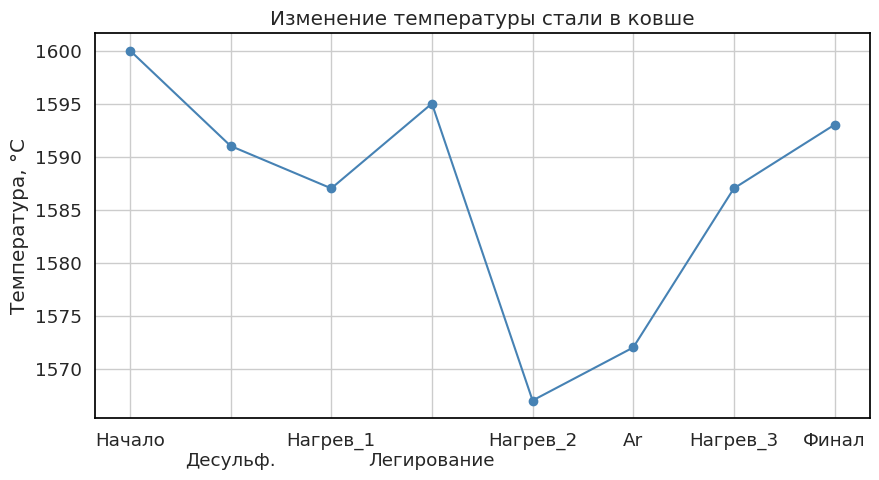

In [4]:
# !pip install catboost==1.2.8 -q
# !pip install hyperopt==0.2.7 -q
# !pip install lightgbm==4.5.0 -q
# # !pip install matplotlib==3.10.0 -q
# # !pip install numpy==2.0.2 -q
# !pip install pandas==2.2.2 -q
# !pip install phik==0.12.4 -q
# !pip install pingouin==0.5.5 -q
# !pip install scikit-learn==1.6.1 -q
# # !pip install scipy==1.15.2 -q
# !pip install seaborn==0.13.2 -q
# !pip install shap==0.47.2 -q
# !pip install sqlalchemy==2.0.40 -q
# !pip install statsmodels==0.14.4 -q
# # !pip install torch==2.6.0+cu124 -q
# !pip install pytorch-tabnet==4.1.0 -q

# # КОД МЕНТОРА. Другие версии с загрузчика платформы
# !pip install numpy==1.26.4 -q
# !pip install matplotlib==3.9.4 -q
# !pip install scipy==1.13.1 -q
# !pip install torch==2.6.0 -q

In [5]:
# данные
import os
import time
import re
import random
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sqlalchemy import MetaData
from functools import reduce, partial
import warnings

# графики
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

# статистика
from scipy import stats

# ML
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
import torch

# сторонние библиотеки
import pingouin as pg
import phik
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from pytorch_tabnet.tab_model import TabNetRegressor
from pytorch_tabnet.pretraining import TabNetPretrainer
# import shap

# константы
RANDOM_STATE = 210425
TEST_SIZE = 0.25
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# настройка окружения
pd.options.display.max_columns = None
pd.options.display.float_format = '{: .3f}'.format
sns.set(font_scale=1.2)
sns.set_style('whitegrid', {'axes.edgecolor': 'black'})
warnings.filterwarnings('ignore')

<a name="Main_Part_0"></a>
## Импорт данных и разведочный анализ
[[Содержание](#Содержание)]

Скачаем датасет

In [6]:
!wget https://code.s3.yandex.net/data-scientist/ds-plus-final.db

--2025-05-01 12:20:09--  https://code.s3.yandex.net/data-scientist/ds-plus-final.db
Resolving code.s3.yandex.net (code.s3.yandex.net)... 93.158.134.158, 2a02:6b8::2:158
Connecting to code.s3.yandex.net (code.s3.yandex.net)|93.158.134.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3588096 (3.4M) [application/octet-stream]
Saving to: ‘ds-plus-final.db.16’

ds-plus-final.db.16 100%[===================>]   3.42M  --.-KB/s    in 0.1s    

2025-05-01 12:20:10 (27.6 MB/s) - ‘ds-plus-final.db.16’ saved [3588096/3588096]



Посмотрим, какие таблицы нам доступны в базе, потому что структуры или схемы у нас нет, как нет ее и у самой базы

In [7]:
path_to_db = 'ds-plus-final.db'
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

metadata = MetaData()
metadata.reflect(bind=engine)
print('Список таблиц:\n')
for table in metadata.tables.values():
    print(table.name)

Список таблиц:

contract
data_arc
data_bulk
data_bulk_time
data_gas
data_temp
data_wire
data_wire_time
internet
personal
phone


Интересно, видимо таблицы из соседнего проекта, схемы `steel` тоже нет, просто сами таблицы без связей. Внутреннюю структуру нет смысла смотреть через схему, поэтому продолжим уже в `pandas`, так как по крайней мере в списке есть все таблицы, которые указывал заказчик

In [8]:
def analyze(data):
    print('Общая информация о признаках\n')
    data.info()

    print('\nПервые пять строк датасета')
    display(data.head())

    print('\nСтатистика по признакам')
    display(data.describe())

    stats = {'values':
      ['Unique, count', 'Unique, %', 'Missing, count', 'Missing, %']
    }
    for col in data:
        stats[col] = [
            data[col].nunique(),
            round(100 * data[col].nunique() / data.shape[0], 2),
            data[col].isnull().sum(),
            round(100 * data[col].isnull().sum() / data.shape[0], 2),
        ]
    stats = pd.DataFrame(stats).set_index('values').T
    print('\nСтатистика по уникальным значениям и пропускам')
    display(stats.sort_values('Missing, %', ascending=False))

    print(f'\nПолных явных дубликатов - {data.duplicated().sum()}')

### `data_arc`
[[К началу раздела](#Main_Part_0)]

In [9]:
df_arc = pd.read_sql(
    'data_arc',
    con=engine,
    parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой']
)

In [10]:
analyze(df_arc)

Общая информация о признаках

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   key                   14876 non-null  int64         
 1   Начало нагрева дугой  14876 non-null  datetime64[ns]
 2   Конец нагрева дугой   14876 non-null  datetime64[ns]
 3   Активная мощность     14876 non-null  float64       
 4   Реактивная мощность   14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 581.2 KB

Первые пять строк датасета


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305,0.211
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.766,0.477
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580,0.430
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518,0.380
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867,0.644



Статистика по признакам


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
count,14876.000,14876,14876,14876.000,14876.000
mean,1615.220,2019-07-05 12:25:51.921081088,2019-07-05 12:28:43.592027392,0.663,0.439
min,1.000,2019-05-03 11:02:14,2019-05-03 11:06:02,0.223,-715.480
25%,806.000,2019-06-03 23:18:23.249999872,2019-06-03 23:21:35,0.467,0.337
50%,1617.000,2019-07-03 01:31:26.500000,2019-07-03 01:35:13,0.600,0.442
75%,2429.000,2019-08-07 22:52:20.750000128,2019-08-07 22:56:47,0.830,0.608
max,3241.000,2019-09-06 17:24:54,2019-09-06 17:26:15,1.464,1.270
std,934.572,NaN,NaN,0.259,5.873



Статистика по уникальным значениям и пропускам


values,"Unique, count","Unique, %","Missing, count","Missing, %"
key,3214.000,21.610,0.000,0.000
Начало нагрева дугой,14876.000,100.000,0.000,0.000
Конец нагрева дугой,14876.000,100.000,0.000,0.000
Активная мощность,13846.000,93.080,0.000,0.000
Реактивная мощность,14707.000,98.860,0.000,0.000



Полных явных дубликатов - 0


Поправим названия колонок

In [11]:
df_arc.columns = ['key', 'begin_heat', 'end_heat', 'active_power', 'reactive_power']

- 14876 записей периодов нагрева стали в ковше
- Пропусков и полных явных дубликатов нет
- 3214 уникальных партий, минимальный номер - 1, максимальный - 3241
- Данные собраны за временной промежуток с 2019-05-03 по 2019-09-06
- Точно есть выброс в реактивной мощности `reactive_power` - минимальное значение -715.5, позже разберемся
- Активная мощность больше реактивной по статистике и по первым строкам, как и должно быть
- Поправили названия признаков
- Форматы поставили при импорте

### `data_bulk`
[[К началу раздела](#Main_Part_0)]

In [12]:
query = '''
SELECT *
FROM data_bulk
'''

df_bulk = pd.read_sql_query(query, con=engine, dtype=float)

In [13]:
analyze(df_bulk)

Общая информация о признаках

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   float64
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(16)
memory usage: 391.2 KB

Первые пять строк датасета


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1.000,NaN,NaN,NaN,43.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.000,NaN,150.000,154.000
1,2.000,NaN,NaN,NaN,73.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.000,NaN,149.000,154.000
2,3.000,NaN,NaN,NaN,34.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.000,NaN,152.000,153.000
3,4.000,NaN,NaN,NaN,81.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.000,NaN,153.000,154.000
4,5.000,NaN,NaN,NaN,78.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.000,NaN,151.000,152.000



Статистика по признакам


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000,252.000,22.000,1298.000,1014.000,77.000,576.000,25.000,1.000,19.000,176.000,177.000,2450.000,18.000,2806.000,2248.000
mean,1624.384,39.242,253.045,113.879,104.394,107.026,118.925,305.600,49.000,76.316,83.284,76.819,260.471,181.111,170.285,160.513
std,933.338,18.278,21.181,75.483,48.184,81.791,72.058,191.023,NaN,21.721,26.060,59.655,120.649,46.088,65.869,51.765
min,1.000,10.000,228.000,6.000,12.000,11.000,17.000,47.000,49.000,63.000,24.000,8.000,53.000,151.000,16.000,1.000
25%,816.000,27.000,242.000,58.000,72.000,70.000,69.750,155.000,49.000,66.000,64.000,25.000,204.000,153.250,119.000,105.000
50%,1622.000,31.000,251.500,97.500,102.000,86.000,100.000,298.000,49.000,68.000,86.500,64.000,208.000,155.500,151.000,160.000
75%,2431.000,46.000,257.750,152.000,133.000,132.000,157.000,406.000,49.000,70.500,102.000,106.000,316.000,203.500,205.750,205.000
max,3241.000,185.000,325.000,454.000,281.000,603.000,503.000,772.000,49.000,147.000,159.000,313.000,1849.000,305.000,636.000,405.000



Статистика по уникальным значениям и пропускам


values,"Unique, count","Unique, %","Missing, count","Missing, %"
Bulk 8,1.000,0.030,3128.000,99.970
Bulk 13,14.000,0.450,3111.000,99.420
Bulk 9,10.000,0.320,3110.000,99.390
Bulk 2,15.000,0.480,3107.000,99.300
Bulk 7,25.000,0.800,3104.000,99.200
Bulk 5,55.000,1.760,3052.000,97.540
Bulk 10,77.000,2.460,2953.000,94.380
Bulk 11,101.000,3.230,2952.000,94.340
Bulk 1,47.000,1.500,2877.000,91.950
Bulk 6,205.000,6.550,2553.000,81.590



Полных явных дубликатов - 0


Запомним отдельно названия колонок для импорта следующей таблицы, далее поправим их названия и вернем формат `int` для `key`

In [14]:
bulk_cols_ = list(df_bulk.drop('key', axis=1).columns)
df_bulk.columns = df_bulk.columns.str.replace(" ", "_").str.lower()
df_bulk['key'] = df_bulk['key'].astype(int)

- 3129 записей и столько же уникальных партий, меньше, чем в `df_arc`
- Минимальный номер партии - 1, максимальный - 3241, аналогично `df_arc`
- Довольно много пропусков, есть даже признак `bulk_8` с 1 уникальным значением, возникли из-за того, что в разные партии, в зависимости от начального состояния, добавляют разные добавки, необязательно все 15, так что это не случайные пропуски, а просто отсутствие факта добавки конкретной примеси
- Полных явных дубликатов нет
- На некоторых признаках есть намеки на возможные выбросы, но лучше посмотрим позже на распределении
- Поправили названия признаков
- Форматы поставили при импорте

### `data_bulk_time`
[[К началу раздела](#Main_Part_0)]

In [15]:
df_bulk_time = pd.read_sql('data_bulk_time', con=engine, parse_dates=bulk_cols_)

In [16]:
analyze(df_bulk_time)

Общая информация о признаках

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   key      3129 non-null   int64         
 1   Bulk 1   252 non-null    datetime64[ns]
 2   Bulk 2   22 non-null     datetime64[ns]
 3   Bulk 3   1298 non-null   datetime64[ns]
 4   Bulk 4   1014 non-null   datetime64[ns]
 5   Bulk 5   77 non-null     datetime64[ns]
 6   Bulk 6   576 non-null    datetime64[ns]
 7   Bulk 7   25 non-null     datetime64[ns]
 8   Bulk 8   1 non-null      datetime64[ns]
 9   Bulk 9   19 non-null     datetime64[ns]
 10  Bulk 10  176 non-null    datetime64[ns]
 11  Bulk 11  177 non-null    datetime64[ns]
 12  Bulk 12  2450 non-null   datetime64[ns]
 13  Bulk 13  18 non-null     datetime64[ns]
 14  Bulk 14  2806 non-null   datetime64[ns]
 15  Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](15), int64(1)
memory usage: 39

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaT,NaT,NaT,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:53:30,NaT,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaT,NaT,NaT,2019-05-03 12:32:39,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:27:13,NaT,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,NaT,NaT,NaT,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:58:00,NaT,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,2019-05-03 13:34:12,2019-05-03 13:30:47



Статистика по признакам


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000,252,22,1298,1014,77,576,25,1,19,176,177,2450,18,2806,2248
mean,1624.384,2019-06-29 23:24:44.769841152,2019-07-12 07:57:13.045454592,2019-07-08 13:50:14.630970624,2019-07-03 11:17:28.834319616,2019-07-13 17:18:29.090908928,2019-07-06 13:50:06.345486080,2019-07-27 18:09:05.079999744,2019-07-08 17:14:53,2019-06-23 08:08:47.578947328,2019-07-06 23:55:10.954545408,2019-07-15 07:01:00.615819264,2019-07-05 22:55:11.468571392,2019-07-01 18:32:46.944444416,2019-07-06 07:17:48.372772608,2019-07-06 13:24:51.912366336
min,1.000,2019-05-03 17:42:46,2019-05-07 15:39:35,2019-05-03 20:40:25,2019-05-03 11:28:48,2019-05-07 15:19:17,2019-05-03 19:09:15,2019-05-07 18:11:01,2019-07-08 17:14:53,2019-05-14 11:57:58,2019-05-06 07:54:02,2019-05-05 23:43:24,2019-05-03 11:24:31,2019-05-05 02:10:21,2019-05-03 11:14:50,2019-05-03 11:10:43
25%,816.000,2019-05-29 14:48:48.500000,2019-05-28 02:29:31.500000,2019-06-08 03:50:23.500000,2019-05-30 21:36:11.249999872,2019-06-19 23:32:44,2019-06-06 22:46:10.500000,2019-07-20 23:48:47,2019-07-08 17:14:53,2019-05-14 14:31:08,2019-06-02 05:12:00.500000,2019-06-14 20:24:48,2019-06-03 12:48:47.249999872,2019-05-29 10:43:31.249999872,2019-06-04 04:50:42,2019-06-04 11:28:18
50%,1622.000,2019-06-25 11:09:13,2019-07-27 17:18:38.500000,2019-07-04 09:31:42,2019-06-28 03:44:42.500000,2019-07-25 17:59:41,2019-07-09 03:34:57.500000,2019-07-27 18:07:02,2019-07-08 17:14:53,2019-05-14 16:55:09,2019-07-06 07:05:20,2019-07-24 11:17:22,2019-07-03 01:32:00,2019-07-01 12:59:36.500000,2019-07-03 21:54:13.500000,2019-07-03 16:43:28.500000
75%,2431.000,2019-07-31 05:58:18.249999872,2019-08-13 02:20:08,2019-08-11 01:00:36.750000128,2019-08-04 04:15:46.500000,2019-08-13 04:23:23,2019-08-07 18:55:01.249999872,2019-08-13 04:19:43,2019-07-08 17:14:53,2019-08-16 05:43:31,2019-08-04 02:23:35.750000128,2019-08-11 05:21:01,2019-08-08 14:55:05.249999872,2019-08-04 23:32:00.249999872,2019-08-09 04:22:40.500000,2019-08-09 09:18:31.750000128
max,3241.000,2019-09-05 09:11:32,2019-08-13 11:47:39,2019-09-06 12:26:52,2019-09-05 03:35:21,2019-09-02 18:16:52,2019-09-06 16:24:28,2019-09-05 19:07:49,2019-07-08 17:14:53,2019-08-16 09:11:56,2019-09-04 10:03:22,2019-09-06 05:03:14,2019-09-06 15:01:44,2019-09-01 01:53:02,2019-09-06 17:26:33,2019-09-06 17:23:15
std,933.338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Статистика по уникальным значениям и пропускам


values,"Unique, count","Unique, %","Missing, count","Missing, %"
Bulk 8,1.000,0.030,3128.000,99.970
Bulk 13,18.000,0.580,3111.000,99.420
Bulk 9,19.000,0.610,3110.000,99.390
Bulk 2,22.000,0.700,3107.000,99.300
Bulk 7,25.000,0.800,3104.000,99.200
Bulk 5,77.000,2.460,3052.000,97.540
Bulk 10,176.000,5.620,2953.000,94.380
Bulk 11,177.000,5.660,2952.000,94.340
Bulk 1,252.000,8.050,2877.000,91.950
Bulk 6,576.000,18.410,2553.000,81.590



Полных явных дубликатов - 0


Поправим названия колонок в соответствии с `df_bulk`

In [17]:
df_bulk_time.columns = df_bulk.columns

Проверим, что пропуски у нас аналогично распределены с `df_bulk`

In [18]:
df_bulk_time.isna().equals(df_bulk.isna())

True

In [19]:
df_bulk_time.columns = ['key'] + list(df_bulk.columns[1:]+'_time')

- 3129 записей и столько же уникальных партий, как и в таблице `df_bulk`, как минимум в этом они согласованы
- Минимальный номер партии - 1, максимальный - 3241, аналогично `df_arc`
- Аналогичное распределение пропусков по признакам с `df_bulk`, значит точно согласованы между собой
- Полных явных дубликатов нет
- По датам явных выбросов нет
- Поправили названия признаков в соотетствии с `df_bulk`
- Форматы поставили при импорте

### `data_gas`
[[К началу раздела](#Main_Part_0)]

In [20]:
df_gas = pd.read_sql('data_gas', con=engine)

In [21]:
analyze(df_gas)

Общая информация о признаках

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB

Первые пять строк датасета


,key,Газ 1
0,1,29.750
1,2,12.556
2,3,28.555
3,4,18.841
4,5,5.414



Статистика по признакам


,key,Газ 1
count,3239.000,3239.000
mean,1621.861,11.002
std,935.386,6.220
min,1.000,0.008
25%,812.500,7.043
50%,1622.000,9.836
75%,2431.500,13.770
max,3241.000,77.995



Статистика по уникальным значениям и пропускам


values,"Unique, count","Unique, %","Missing, count","Missing, %"
key,3239.000,100.000,0.000,0.000
Газ 1,3239.000,100.000,0.000,0.000



Полных явных дубликатов - 0


Поправим названия колонок

In [22]:
df_gas.columns = ['key', 'gas']

- 3239 записей и столько же уникальных партий, больше, чем в `df_arc` и `df_bulk`
- Минимальный номер партии - 1, максимальный - 3241, аналогично `df_arc`
- Пропусков и полных явных дубликатов нет
- Явных выбросов нет, посмотрим на распределении позже
- Поправили названия колонок

### `data_temp`
[[К началу раздела](#Main_Part_0)]

In [23]:
query = '''
SELECT *
FROM data_temp
'''

df_temp = pd.read_sql_query(
    query, con=engine, parse_dates=['Время замера'], dtype={'Температура': float}
)

In [24]:
analyze(df_temp)

Общая информация о признаках

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           18092 non-null  int64         
 1   Время замера  18092 non-null  datetime64[ns]
 2   Температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 424.2 KB

Первые пять строк датасета


,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.000
1,1,2019-05-03 11:07:18,1604.000
2,1,2019-05-03 11:11:34,1618.000
3,1,2019-05-03 11:18:04,1601.000
4,1,2019-05-03 11:25:59,1606.000



Статистика по признакам


,key,Время замера,Температура
count,18092.000,18092,14665.000
mean,1616.461,2019-07-05 13:36:58.791620608,1590.723
min,1.000,2019-05-03 11:02:04,1191.000
25%,807.750,2019-06-04 00:35:01.249999872,1580.000
50%,1618.000,2019-07-03 02:11:48,1590.000
75%,2429.000,2019-08-07 23:10:05.249999872,1599.000
max,3241.000,2019-09-06 17:30:05,1705.000
std,934.641,NaN,20.394



Статистика по уникальным значениям и пропускам


values,"Unique, count","Unique, %","Missing, count","Missing, %"
Температура,172.000,0.950,3427.000,18.940
key,3216.000,17.780,0.000,0.000
Время замера,18092.000,100.000,0.000,0.000



Полных явных дубликатов - 0


Поправим названия колонок

In [25]:
df_temp.columns = ['key', 'measure_time', 'temp']

- 18092 записей
- Уникальных партий - 3216, так же отлично от всех предыдущих таблиц
- Минимальный номер партии - 1, максимальный - 3241, аналогично `df_arc`
- Есть около 19 % пропусков температуры, при этом время замера есть, но так как это и целевой признак, заполнить не сможем, посмотрим далее
- Полных явных дубликатов нет
- Точно есть аномальные значения температуры, ниже 1500 градусов, о которых предупреждал заказчик
- Поправили названия признаков
- Форматы поставили при импорте

### `data_wire`
[[К началу раздела](#Main_Part_0)]

In [26]:
query = '''
SELECT *
FROM data_wire
'''

df_wire = pd.read_sql_query(query, con=engine, dtype=float)

In [27]:
analyze(df_wire)

Общая информация о признаках

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   float64
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(10)
memory usage: 240.8 KB

Первые пять строк датасета


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1.000,60.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.000,96.052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.000,91.160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.000,89.064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.000,89.238,9.115,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Статистика по признакам


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000,3055.000,1079.000,63.000,14.000,1.000,73.000,11.000,19.000,29.000
mean,1623.426,100.896,50.577,189.483,57.443,15.132,48.017,10.039,53.625,34.156
std,932.997,42.013,39.320,99.513,28.825,NaN,33.920,8.611,16.882,19.932
min,1.000,1.919,0.030,0.144,24.149,15.132,0.034,0.234,45.077,4.623
25%,823.000,72.116,20.194,95.135,40.807,15.132,25.054,6.763,46.095,22.058
50%,1619.000,100.158,40.143,235.195,45.234,15.132,42.076,9.017,46.280,30.066
75%,2434.000,126.060,70.228,276.252,76.125,15.132,64.213,11.886,48.090,43.862
max,3241.000,330.314,282.780,385.009,113.231,15.132,180.455,32.848,102.762,90.054



Статистика по уникальным значениям и пропускам


values,"Unique, count","Unique, %","Missing, count","Missing, %"
Wire 5,1.000,0.030,3080.000,99.970
Wire 7,10.000,0.320,3070.000,99.640
Wire 4,14.000,0.450,3067.000,99.550
Wire 8,13.000,0.420,3062.000,99.380
Wire 9,25.000,0.810,3052.000,99.060
Wire 3,56.000,1.820,3018.000,97.960
Wire 6,69.000,2.240,3008.000,97.630
Wire 2,713.000,23.140,2002.000,64.980
Wire 1,2251.000,73.060,26.000,0.840
key,3081.000,100.000,0.000,0.000



Полных явных дубликатов - 0


Запомним отдельно названия колонок для импорта следующей таблицы, далее поправим их названия и вернем формат `int` для `key`

In [28]:
wire_cols_ = list(df_wire.drop('key', axis=1).columns)
df_wire.columns = df_wire.columns.str.replace(' ', '_').str.lower()
df_wire['key'] = df_wire['key'].astype(int)

- 3081 запись и столько же уникальных партий, снова отличается от всех предыдущих таблиц
- Минимальный номер партии - 1, максимальный - 3241, аналогично `df_arc`
- Довольно много пропусков, логика их наличия такая же, как и в `df_bulk`
- Полных явных дубликатов нет
- Наличие выбросов опять же посмотрим позже на распределении
- Поправили названия признаков
- Форматы поставили при импорте

### `data_wire_time`
[[К началу раздела](#Main_Part_0)]

In [29]:
df_wire_time = pd.read_sql(
    'data_wire_time',
    con=engine,
    parse_dates=wire_cols_
)

In [30]:
analyze(df_wire_time)

Общая информация о признаках

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   Wire 1  3055 non-null   datetime64[ns]
 2   Wire 2  1079 non-null   datetime64[ns]
 3   Wire 3  63 non-null     datetime64[ns]
 4   Wire 4  14 non-null     datetime64[ns]
 5   Wire 5  1 non-null      datetime64[ns]
 6   Wire 6  73 non-null     datetime64[ns]
 7   Wire 7  11 non-null     datetime64[ns]
 8   Wire 8  19 non-null     datetime64[ns]
 9   Wire 9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9), int64(1)
memory usage: 240.8 KB

Первые пять строк датасета


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,3,2019-05-03 12:11:46,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
3,4,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaT,NaT,NaT,NaT,NaT,NaT,NaT



Статистика по признакам


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000,3055,1079,63,14,1,73,11,19,29
mean,1623.426,2019-07-05 23:22:34.279541760,2019-07-07 01:07:08.735866624,2019-07-10 15:09:58.650793472,2019-07-11 13:44:37,2019-08-13 06:14:30,2019-07-07 11:51:15.095890432,2019-08-07 01:16:08.090909184,2019-06-23 07:47:49.052631552,2019-07-01 11:56:04.793103616
min,1.000,2019-05-03 11:06:19,2019-05-03 13:15:34,2019-05-04 04:34:27,2019-05-07 15:19:17,2019-08-13 06:14:30,2019-05-07 14:46:05,2019-07-27 05:49:05,2019-05-14 11:29:24,2019-05-04 17:21:27
25%,823.000,2019-06-04 19:30:11.500000,2019-06-05 14:50:26.500000,2019-06-11 14:17:38.500000,2019-07-20 17:58:53.750000128,2019-08-13 06:14:30,2019-05-08 21:47:30,2019-07-27 16:27:27,2019-05-14 14:20:07.500000,2019-06-09 19:36:17
50%,1619.000,2019-07-03 06:36:23,2019-07-04 23:13:39,2019-07-21 10:04:47,2019-07-27 05:45:26.500000,2019-08-13 06:14:30,2019-07-28 05:00:32,2019-08-12 21:48:11,2019-05-14 16:55:09,2019-06-11 10:10:21
75%,2434.000,2019-08-08 08:56:06.500000,2019-08-08 23:15:17,2019-08-12 22:54:46,2019-07-27 16:20:04.750000128,2019-08-13 06:14:30,2019-08-13 13:33:02,2019-08-13 02:02:55.500000,2019-08-16 05:06:53.500000,2019-08-09 06:49:04
max,3241.000,2019-09-06 17:10:06,2019-09-06 07:35:40,2019-09-02 07:14:44,2019-08-13 03:16:45,2019-08-13 06:14:30,2019-08-18 19:10:56,2019-08-13 10:25:22,2019-08-16 08:56:23,2019-09-03 12:55:23
std,932.997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Статистика по уникальным значениям и пропускам


values,"Unique, count","Unique, %","Missing, count","Missing, %"
Wire 5,1.000,0.030,3080.000,99.970
Wire 7,11.000,0.360,3070.000,99.640
Wire 4,14.000,0.450,3067.000,99.550
Wire 8,19.000,0.620,3062.000,99.380
Wire 9,29.000,0.940,3052.000,99.060
Wire 3,63.000,2.040,3018.000,97.960
Wire 6,73.000,2.370,3008.000,97.630
Wire 2,1079.000,35.020,2002.000,64.980
Wire 1,3055.000,99.160,26.000,0.840
key,3081.000,100.000,0.000,0.000



Полных явных дубликатов - 0


Поправим названия колонок в соответствии с `df_wire`

In [31]:
df_wire_time.columns = df_wire.columns

Проверим, что пропуски у нас аналогично распределены с `df_wire`

In [32]:
df_wire_time.isna().equals(df_wire.isna())

True

In [33]:
df_wire_time.columns = ['key'] + list(df_wire.columns[1:]+'_time')

- 3081 запись и столько же уникальных партий, как и в таблице `df_wire`
- Минимальный номер партии - 1, максимальный - 3241, аналогично `df_arc`
- Аналогичное распределение пропусков по признакам с `df_wire`, значит точно согласованы между собой
- Полных явных дубликатов нет
- По датам явных выбросов нет
- Поправили названия признаков в соотетствии с `df_wire`
- Форматы поставили при импорте

### Вывод
[[К началу раздела](#Main_Part_0)]

- Проверили наличие таблиц в базе, схема `steel` отсутствовала, импортировали с корректными форматами признаков
- Все данные собраны за временной промежуток с 2019-05-03 по 2019-09-06
- Полных явных дубликатов нет ни в одной таблице
- Во всех таблицах поправили названия признаков
- Во всех таблицах поставили правильные форматы при импорте
- Количество уникальных партий разное во всех таблицах, кроме парных (`df_bulk` и `df_bulk_time`, `df_wire` и `df_wire_time`)


- `df_arc`
    - 14876 записей
    - 3214 уникальных партий
    - Точно есть выброс в реактивной мощности `reactive_power` - минимальное значение -715.5, позже разберемся
    
    
- `df_bulk`
    - 3129 записей и уникальных партий
    - Много пропусков. Вероятно, это не случайные пропуски, а отсутствие факта добавки конкретной примеси
    
    
- `df_bulk_time`
    - 3129 записей и уникальных партий
    - Аналогичное распределение пропусков по признакам с `df_bulk`
    - Согласована в с `df_bulk`
    
    
- `df_gas`
    - 3239 записей и уникальных партий
    
    
- `df_temp`
    - 18092 записей
    - Уникальных партий - 3216
    - Есть около 19 % пропусков температуры, посмотрим на них далее
    - Точно есть аномальные значения температуры, ниже 1500 градусов, о которых предупреждал заказчик
    
    
- `df_wire`
    - 3081 запись и уникальных партий
    - Довольно много пропусков, логика их наличия такая же, как и в `df_bulk`
    
    
- `df_wire_time`
    - 3081 запись и уникальных партий
    - Аналогичное распределение пропусков по признакам с `df_wire`
    - Согласована в с `df_wire`

<a name="Main_Part_1"></a>
## Исследовательский анализ
[[Содержание](#Содержание)]

<a name="Part_1"></a>
### Подготовка данных к агрегированию и анализ
[[К началу раздела](#Main_Part_1)]

In [34]:
# Определим функцию для графического и описательного анализа столбцов
def describe_column(data, alpha=1, ax=None, add_title='', title=None):

    fig = plt.figure(figsize=(18, 6))
    # проверка на непрерывность
    if data.nunique() > 26:
        # Настройки сетки графика
        gs = gridspec.GridSpec(2, 2, height_ratios=[5, 1])
        gs.update(hspace=0)
        ax_hist = plt.subplot(gs[0, 0])
        ax_box = plt.subplot(gs[1, 0])
        ax_qq = plt.subplot(gs[:, 1])

        # Boxplot и гистограмма
        sns.boxplot(x=data, ax=ax_box)
        sns.histplot(
            x=data,
            bins='auto',
            alpha=alpha,
            edgecolor='black',
            ax=ax_hist,
            stat='probability',
        )
        plt.subplots_adjust(hspace=0)

    # дискретный
    else:
        # Настройки сетки графика
        gs = gridspec.GridSpec(1, 2)
        ax_hist = plt.subplot(gs[0])
        ax_qq = plt.subplot(gs[1])

        sns.countplot(
            x=data,
            alpha=alpha,
            edgecolor='black',
            stat='probability',
            ax=ax_hist
        )

    ax_hist.set_ylabel('Частота', size=14)
    if title is None:
        ax_hist.set_title(
            'Распределение признака ' + add_title + f' {data.name}',
            size=16
            )
    else:
        ax_hist.set_title(title, size=16)
    # QQ-plot
    pg.qqplot(data, ax=ax_qq, square=False)
    ax_qq.set_title(
        'Нормальный график Q-Q признака '+ add_title + f' {data.name}',
        size=16
        )
    ax_qq.set_xlabel('Нормальные квантили', size=14)
    ax_qq.set_ylabel('Признаковые квантили', size=14)

    plt.show()

    # Описательная статистика
    display(pd.DataFrame(data.describe()).T)


#### Данные об измерениях температуры `df_temp`
[[К началу главы](#Part_1)]

Для создания модели нам необходимо, чтобы у каждой партии было как минимум 2 измерения температуры, начальное и конечное, где первое будем использовать для предсказания. Поэтому посмотрим как у нас распределены партии обработки по количеству измерений температуры

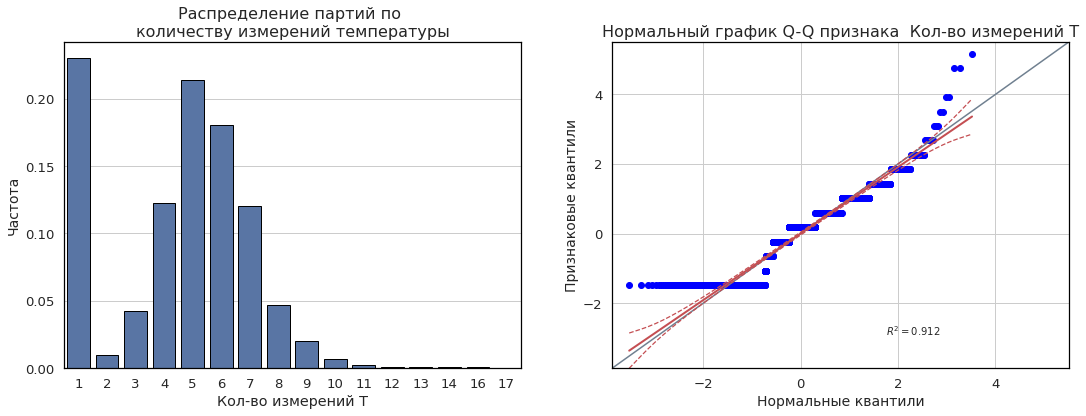

,count,mean,std,min,25%,50%,75%,max
Кол-во измерений Т,3216.000,4.560,2.406,1.000,3.000,5.000,6.000,17.000


In [35]:
describe_column(
    df_temp.groupby('key')['temp'].count().rename('Кол-во измерений Т'),
    title='Распределение партий по \nколичеству измерений температуры',
)

Видим, что около 23 % партий (741) c 1 измерением температуры, много, но сделать с ними ничего не сможем - выбросим

In [36]:
df_temp = df_temp[df_temp.groupby('key')['temp'].transform('count') > 1]

Проверим пропуски

In [37]:
df_temp.isnull().sum()

key             0
measure_time    0
temp            0
dtype: int64

Отлично, оказывается все они были в партиях с единичным измерением температуры. Теперь посмотрим на распределение температур во время измерений. По словам заказчика, значения температуры ниже 1500 градусов — аномальные

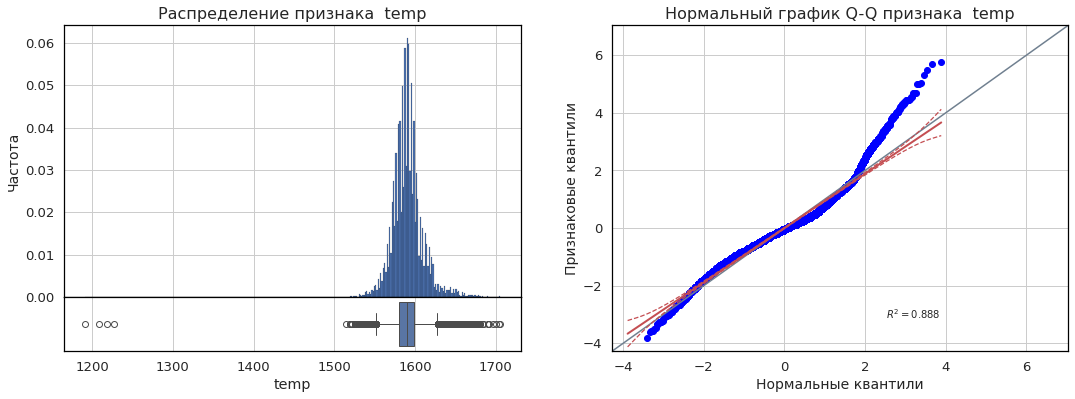

,count,mean,std,min,25%,50%,75%,max
temp,13924.000,1590.802,19.846,1191.000,1580.000,1590.000,1599.000,1705.000


Измерений с температурой ниже 1500 градусов -  4


In [38]:
describe_column(df_temp['temp'])
print(
    'Измерений с температурой ниже 1500 градусов - ',
    (df_temp['temp'] < 1500).sum()
)

Всего 4, взглянем

In [39]:
df_temp[df_temp['key'].isin(df_temp.query('temp<1500')['key'])]

,key,measure_time,temp
4883,867,2019-06-06 08:03:39,1191.000
4884,867,2019-06-06 08:18:52,1575.000
4885,867,2019-06-06 08:22:38,1576.000
4886,867,2019-06-06 08:25:11,1571.000
4887,867,2019-06-06 08:29:49,1600.000
4888,867,2019-06-06 08:36:49,1522.000
4889,867,2019-06-06 08:43:02,1521.000
4890,867,2019-06-06 08:48:23,1599.000
6784,1214,2019-06-18 08:01:03,1208.000
6785,1214,2019-06-18 08:17:56,1608.000


У всех этих партий температура была ниже 1500 градусов на первом замере, то есть до начала обработки по идее. После консультации принято решение считать такие партии бракованными, так как до нашего процесса обработки стали есть и предшествующие, в которых температура должна соответствовать нормам заказчика. Данные о процессах до этого этапа нам недоступны, поэтому выбросим эти партии, так как технологический процесс был нарушен изначально

In [40]:
df_temp = df_temp[~df_temp['key'].isin(df_temp.query('temp<1500')['key'])]

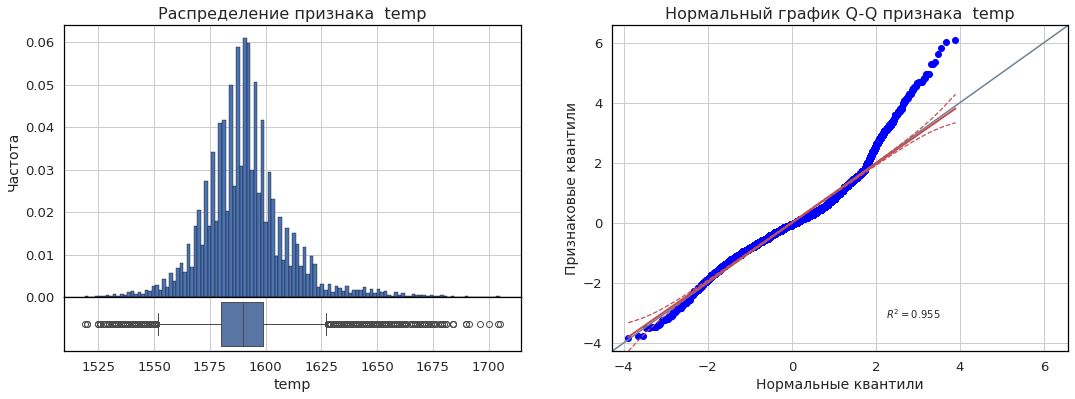

,count,mean,std,min,25%,50%,75%,max
temp,13903.000,1590.925,18.751,1519.000,1580.000,1590.000,1599.000,1705.000


In [41]:
describe_column(df_temp['temp'])

Ограничения на максимальные значения температуры для процесса заказчик не ставил, поэтому можно предположить, что значения около 1700 градусов это избыточный разогрев по тем или иным причинам, которого в том числе заказчик хочет избегать с помощью нашей модели

- Средняя температура 1591 ± 19 градусов
- Минимальная - 1519, максимальная - 1705
- Распределение в целом нормальное, с небольшим сдвигом влево

Добавим признаки
- `time_passed` - время прошедшее с первого измерения температуры (вспомогательный для графика)
- `begin_temp` - стартовая температура партии
- `end_temp` - конечная температура партии - **целевой признак**
- `time_total` - полное время затраченное на партию
- `begin_meas_time` - время первого измерения
- `end_meas_time` - время последнего измерения

In [42]:
df_temp['time_passed'] = (
    df_temp['measure_time'] - df_temp.groupby('key')['measure_time'].transform('first')
).apply(lambda x: x.seconds)

In [43]:
df_temp_agg = df_temp.groupby('key').agg(
    time_total=('measure_time', lambda x: (x.max() - x.min()).seconds),
    begin_temp=('temp', 'first'),
    end_temp=('temp', 'last'),
    begin_meas_time=('measure_time', 'first'),
    end_meas_time=('measure_time', 'last')
).reset_index()

df_temp_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2471 entries, 0 to 2470
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   key              2471 non-null   int64         
 1   time_total       2471 non-null   int64         
 2   begin_temp       2471 non-null   float64       
 3   end_temp         2471 non-null   float64       
 4   begin_meas_time  2471 non-null   datetime64[ns]
 5   end_meas_time    2471 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(2)
memory usage: 116.0 KB


Посмотрим, что получилось

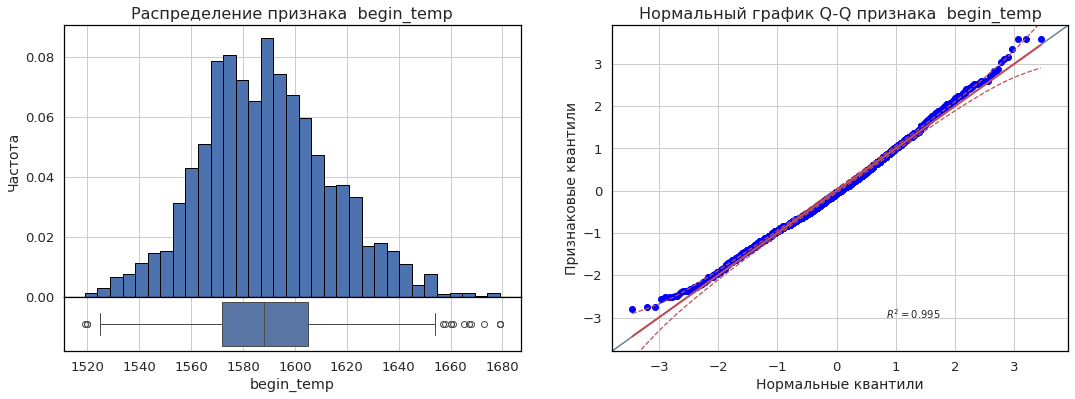

,count,mean,std,min,25%,50%,75%,max
begin_temp,2471.000,1589.013,25.004,1519.000,1572.000,1588.000,1605.000,1679.000


In [44]:
describe_column(df_temp_agg['begin_temp'])

- Распределение начальной температуры почти идеально нормальное со средней температурой **1589 ± 25** градусов

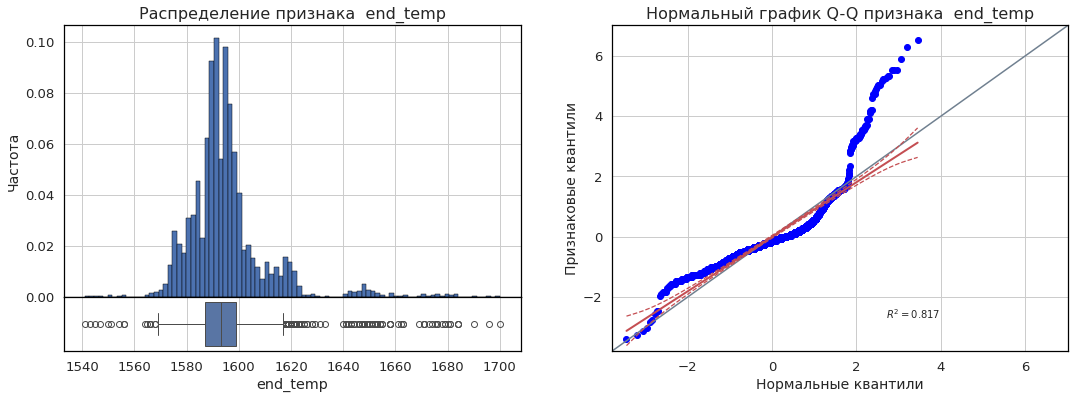

,count,mean,std,min,25%,50%,75%,max
end_temp,2471.000,1595.340,16.035,1541.000,1587.000,1593.000,1599.000,1700.000


In [45]:
describe_column(df_temp_agg['end_temp'])

- Чего не скажешь о распределении конечных температур, хвосты очень длинные
- Средняя **1595 ± 16** градусов, то есть в среднем материал получается чуть горячее, чем был в начале

Посмотрим как меняется температура в процессе плавки

In [46]:
df_ = df_temp[df_temp.groupby('key')['temp'].transform('count') > 11].copy()
df_['time_passed'] = np.around(df_['time_passed'] / 60)

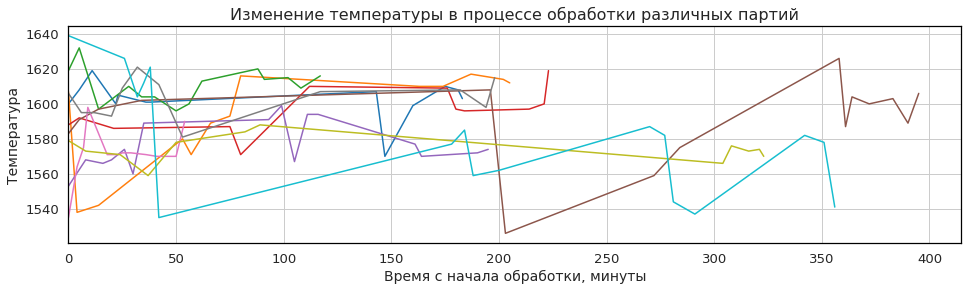

In [47]:
plt.figure(figsize=(16, 4))
plt.title('Изменение температуры в процессе обработки различных партий', fontsize=16)
sns.lineplot(
    data=df_, x='time_passed', y='temp', hue='key', legend=False, palette='tab10'
)
plt.ylabel('Температура', fontsize=14)
plt.xlabel('Время с начала обработки, минуты', fontsize=14)
plt.xlim(0);

- Видны этапы, когда добавлялись примеси и сплав заметно охлаждался
- Так же видны периоды без добавок, когда температура сплава почти не изменялась
- Все процессы проходят в примерных границах около 1580 ± 40 градуса, определенно в рамках технологического процесса

**Вывод**

- Убрали партии с 1 измерением температуры и с этим ушли все пропуски
- Убрали 4 партии, в которых одна из температур (начальная) была ниже 1500 градусов
- Осталась 2471 уникальная партия
- Агрегировали данные по партиям и сделали следующие признаки
    - `begin_temp` - стартовая температура партии
    - `end_temp` - конечная температура партии - **целевой признак**
    - `time_total` - полное время затраченное на партию
    - `begin_meas_time` - время первого измерения
    - `end_meas_time` - время последнего измерения
- Распределение `begin_temp` - нормальное
- Распределение целевого признака `end_temp` - отдаленно похоже на нормальное, но очень длинные хвосты
- Процессы проходят в примерных границах около 1580 ± 40 градуса

#### Данные о работе электродов `df_arc`
[[К началу главы](#Part_1)]

Для начала посмотрим на аномальное значение в `reactive_power`

Только одно аномальное значение, посмотрим на него

In [48]:
anom_idx = df_arc['reactive_power'].idxmin()
df_arc[df_arc['key'] == df_arc.loc[anom_idx, 'key']]

,key,begin_heat,end_heat,active_power,reactive_power
9778,2116,2019-07-28 02:07:12,2019-07-28 02:09:14,0.788,0.694
9779,2116,2019-07-28 02:13:10,2019-07-28 02:15:25,0.580,0.411
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705,-715.480
9781,2116,2019-07-28 02:29:11,2019-07-28 02:30:18,0.564,0.409


Так как мы рассматриваем технологический процесс, у него однозначно есть различные требования и ограничения на все этапы, также не забывая про законы физики, логично предположить, что активная и реактивная мощность в наших данных должны достаточно хорошо коррелировать, проверим это, и если да, то быстро заменим выброс через линейную регрессию

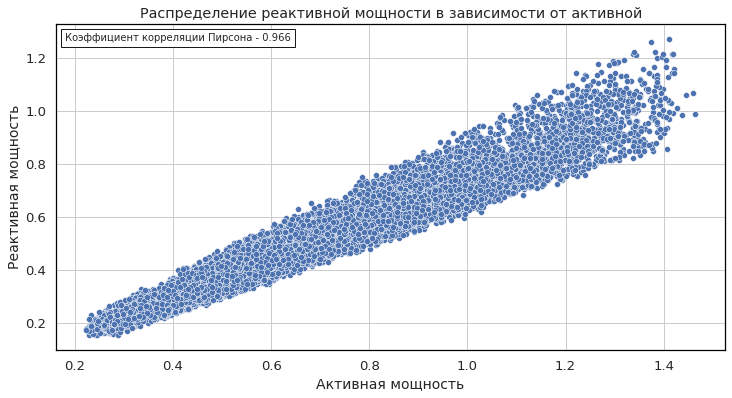

In [49]:
df_ = df_arc.query('reactive_power>0').copy()
fig = plt.figure(figsize=(12, 6))
ax = sns.scatterplot(data=df_, x='active_power', y='reactive_power')
plt.title('Распределение реактивной мощности в зависимости от активной')
plt.xlabel('Активная мощность', fontsize=14)
plt.ylabel('Реактивная мощность', fontsize=14)

r_power = round(df_['reactive_power'].corr(df_['active_power']), 3)
anc_r_power = AnchoredText(f'Коэффициент корреляции Пирсона - {r_power}',
                           loc='upper left')
ax.add_artist(anc_r_power);

Отлично, правда хорошая корреляция, тогда можно либо взять среднюю реактивную мощность в ε-окрестности интересующей нас активной мощности в близкие даты, так как электроды или другие расходники периодически обслуживают или заменяют, либо, быстро сделать линейную регрессию и ей аппроксимировать выброс

In [50]:
x_matrix = np.vstack([df_['active_power'], np.ones(len(df_['active_power']))]).T
m, c = np.linalg.lstsq(x_matrix, df_['reactive_power'], rcond=-1)[0]

In [51]:
df_arc.loc[anom_idx, 'reactive_power'] = m * df_arc.loc[anom_idx, 'active_power'] + c
df_arc.query('key==2116')

,key,begin_heat,end_heat,active_power,reactive_power
9778,2116,2019-07-28 02:07:12,2019-07-28 02:09:14,0.788,0.694
9779,2116,2019-07-28 02:13:10,2019-07-28 02:15:25,0.580,0.411
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705,0.519
9781,2116,2019-07-28 02:29:11,2019-07-28 02:30:18,0.564,0.409


Отлично вышло

In [52]:
del x_matrix

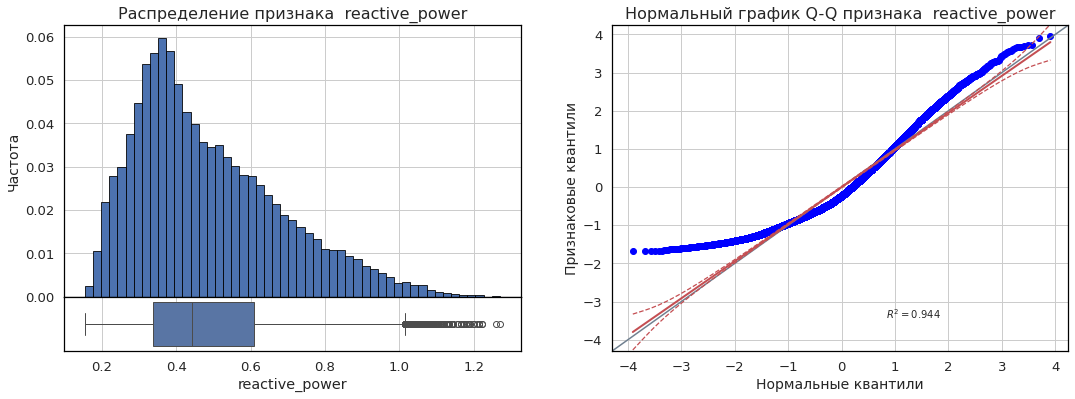

,count,mean,std,min,25%,50%,75%,max
reactive_power,14876.000,0.487,0.198,0.154,0.337,0.442,0.608,1.270


In [53]:
describe_column(df_arc['reactive_power'])

- Распределение в целом нормальное с сильным смещением влево
- Средняя реактивная мощность 0.487 ± 0.198

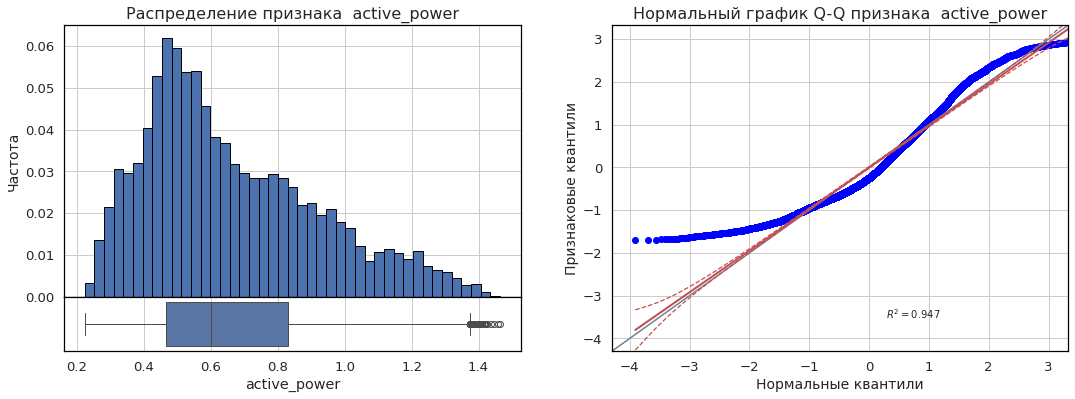

,count,mean,std,min,25%,50%,75%,max
active_power,14876.000,0.663,0.259,0.223,0.467,0.600,0.830,1.464


In [54]:
describe_column(df_arc['active_power'])

- Распределение ожидаемо похоже на распределение реактивной мощности, так как выше мы смотрели их корреляцию и она была близка к 1
- Средняя активная мощность 0.663 ± 0.259

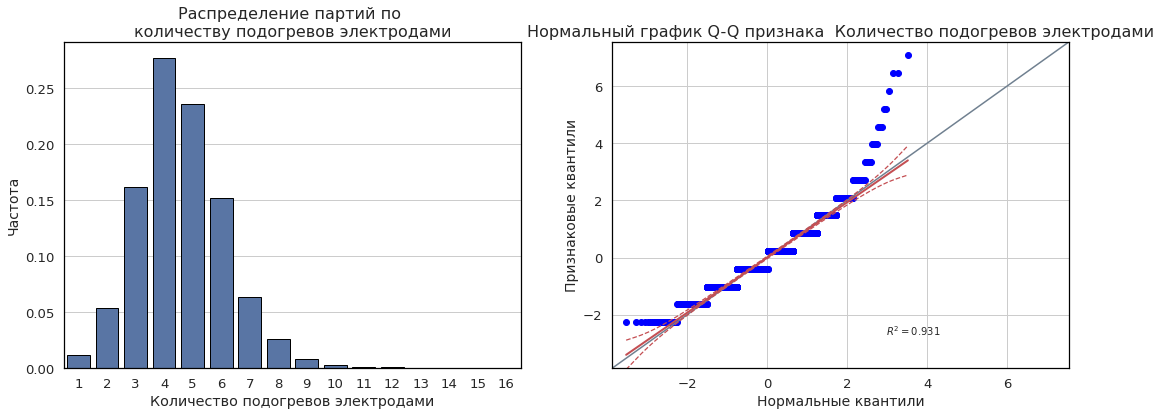

,count,mean,std,min,25%,50%,75%,max
Количество подогревов электродами,3214.000,4.629,1.609,1.000,4.000,4.000,6.000,16.000


In [55]:
describe_column(
    df_arc.groupby('key')['active_power'].count().rename('Количество подогревов электродами'),
    title='Распределение партий по \nколичеству подогревов электродами',
)

- Распределение похоже на распределение партий по измерениям температуры
- Медианное количество подогревов - 4

Добавим вспомогательный признаки для рассчета агрегаций

- `time_heat` - время работы электродов за период
- `Q_act_period` - активная энергия электродов за период
- `cos_phi` - коэффициент мощности, показывает долю активной мощности в полной
- `Q_eff_period` - эффективная энергия, т.е. переданная металлу, за период

In [56]:
df_arc['time_heat'] = (df_arc['end_heat'] - df_arc['begin_heat']).dt.total_seconds()
df_arc['Q_act_period'] = df_arc['active_power'] * df_arc['time_heat']
df_arc['cos_phi'] = (
    df_arc['active_power'] /
    np.sqrt(df_arc['active_power']**2 + df_arc['reactive_power']**2)
)
df_arc['Q_eff_period'] = df_arc['Q_act_period'] * df_arc['cos_phi']

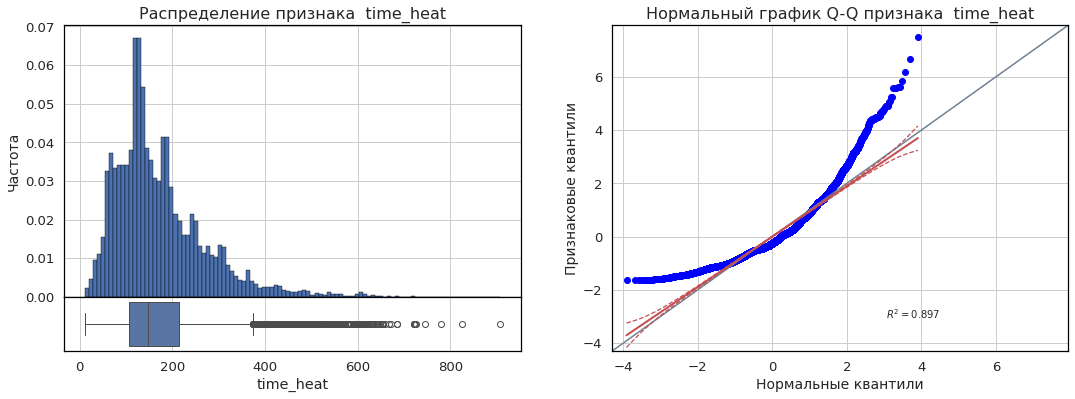

,count,mean,std,min,25%,50%,75%,max
time_heat,14876.000,171.671,98.187,11.000,107.000,147.000,214.000,907.000


In [57]:
describe_column(df_arc['time_heat'])

Теперь агрегируем наши данные и добавим новые признаки
- `time_total_arc` - полное время работы электродов
- `time_avg_arc` - среднее время работы электродов за период
- `act_power_avg` - средяя активная мощность
- `act_power_peak` - пиковая активная мощность
- `Q_act_total` - полная активная энергия электродов
- `Q_eff_total` - полная эффективная энергия
- `Q_eff_last` - эффективная энергия за последний период
- `cos_phi_avg` - средний коэффициент мощности
- `n_periods` - количество периодов работы электродов

In [58]:
df_arc_agg= df_arc.groupby('key').agg(
    time_total_arc=('time_heat', 'sum'),
    time_avg_arc=('time_heat', 'mean'),
    act_power_avg=('active_power', 'mean'),
    act_power_peak=('active_power', 'max'),
    Q_act_total=('Q_act_period', 'sum'),
    Q_eff_total=('Q_eff_period', 'sum'),
    Q_eff_last=('Q_eff_period', 'last'),
    cos_phi_avg=('cos_phi', 'mean'),
    n_arc_periods=('begin_heat', 'count')
).reset_index()

df_arc_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   key             3214 non-null   int64  
 1   time_total_arc  3214 non-null   float64
 2   time_avg_arc    3214 non-null   float64
 3   act_power_avg   3214 non-null   float64
 4   act_power_peak  3214 non-null   float64
 5   Q_act_total     3214 non-null   float64
 6   Q_eff_total     3214 non-null   float64
 7   Q_eff_last      3214 non-null   float64
 8   cos_phi_avg     3214 non-null   float64
 9   n_arc_periods   3214 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 251.2 KB


**Вывод**


- Поправили аномальное значение с помощью регрессии
- Осталось 3214 уникальных партий
- Агрегировали данные по партиям и создали дополнительные признаки
    - `time_total_arc` - полное время работы электродов
    - `time_avg_arc` - среднее время работы электродов за период
    - `act_power_avg` - средяя активная мощность
    - `act_power_peak` - пиковая активная мощность
    - `Q_act_total` - полная активная энергия электродов
    - `Q_eff_total` - полная эффективная энергия
    - `Q_eff_last` - эффективная энергия за последний период
    - `cos_phi_avg` - средний коэффициент мощности
    - `n_periods` - количество периодов работы электродов

#### Данные об объеме газа `df_gas`
[[К началу главы](#Part_1)]

- Здесь проблем никаких не было, поэтому просто посмотрим на данные
- Газ подается в разные моменты, чаще парралельно с нагревом после введения добавок

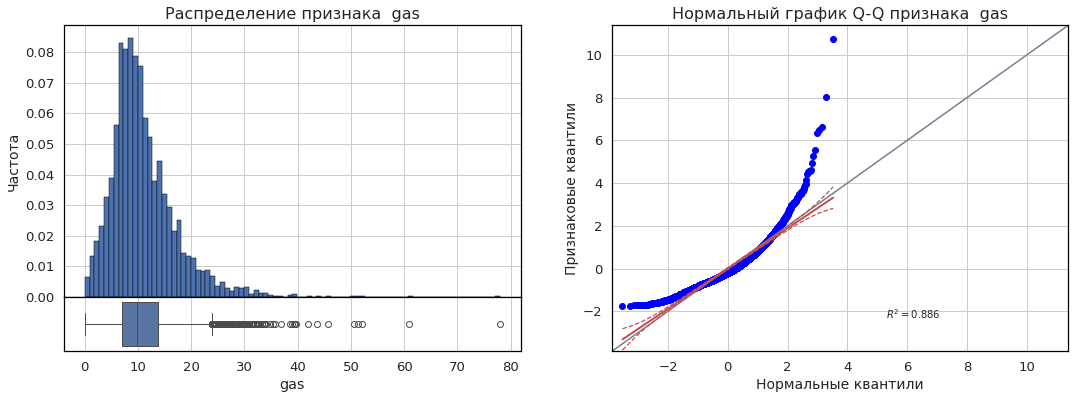

,count,mean,std,min,25%,50%,75%,max
gas,3239.000,11.002,6.220,0.008,7.043,9.836,13.770,77.995


In [59]:
describe_column(df_gas['gas'])

- Распределение сильно смещено и далеко от нормального, есть выбросы, но это нормально для тяжелого процесса
- Средняя 11.0 ± 6.2`

**Вывод**


- Тут все в порядке

#### Данные о сыпучих добавках `df_bulk` и `df_bulk_time`
[[К началу главы](#Part_1)]

Посмотрим еще раз на статистики по признакам (добавкам)

In [60]:
df_bulk.describe()

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
count,3129.000,252.000,22.000,1298.000,1014.000,77.000,576.000,25.000,1.000,19.000,176.000,177.000,2450.000,18.000,2806.000,2248.000
mean,1624.384,39.242,253.045,113.879,104.394,107.026,118.925,305.600,49.000,76.316,83.284,76.819,260.471,181.111,170.285,160.513
std,933.338,18.278,21.181,75.483,48.184,81.791,72.058,191.023,NaN,21.721,26.060,59.655,120.649,46.088,65.869,51.765
min,1.000,10.000,228.000,6.000,12.000,11.000,17.000,47.000,49.000,63.000,24.000,8.000,53.000,151.000,16.000,1.000
25%,816.000,27.000,242.000,58.000,72.000,70.000,69.750,155.000,49.000,66.000,64.000,25.000,204.000,153.250,119.000,105.000
50%,1622.000,31.000,251.500,97.500,102.000,86.000,100.000,298.000,49.000,68.000,86.500,64.000,208.000,155.500,151.000,160.000
75%,2431.000,46.000,257.750,152.000,133.000,132.000,157.000,406.000,49.000,70.500,102.000,106.000,316.000,203.500,205.750,205.000
max,3241.000,185.000,325.000,454.000,281.000,603.000,503.000,772.000,49.000,147.000,159.000,313.000,1849.000,305.000,636.000,405.000


- Заметно выделяется только `bulk_12` с максимальной массой 1849 кг, тогда как его медиана 208, а 75 перцентиль - 316, явно похоже на выброс, но даже в этом случае не будем его выбрасывать, так как бывают суммарные добавки одного материала и до 2 тонн, т.е. в данном случае скорее всего состав изначальной стали был далеко от необходимого, по этой логике оставим и другие выбросы, если они есть
- В `bulk_8` - только одно значение, этот признак выбросим, так как для обучения модели он на текущий момент бесполезен, в будущем можно будет переобучить/дообучить модель, если появится больше данных, кроме того, его масса 49 кг, что не окажет практически никакого влияния на температуру, даже если бы их больше в статистике. Далее добавим его в общую сумму редких добавок

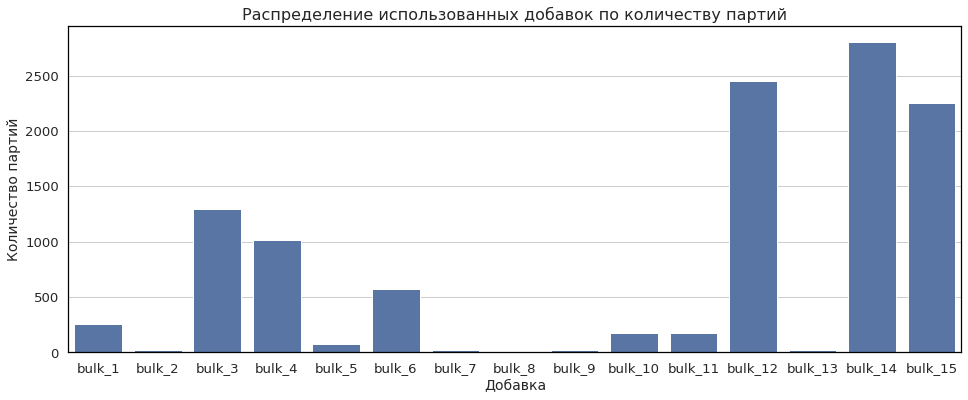

In [61]:
fig = plt.figure(figsize=(16, 6))
sns.barplot(df_bulk.drop('key', axis=1).count())
plt.title('Распределение использованных добавок по количеству партий', fontsize=16)
plt.ylabel('Количество партий', fontsize=14)
plt.xlabel('Добавка', fontsize=14);

- Видим, что чаще всего используются добавки `bulk_14`, `bulk_15` и `bulk_12` - более чем в 2000 партий, скорее всего окажут влияние на предсказание модели
- Очень редко используюстя добавки `bulk_2`, `bulk_9`, `bulk_13`, `bulk_7` - менее 25 партий, объединим их и `bulk_1`, `bulk_5`, `bulk_10`, `bulk_11`, а также `bulk_8` в один признак - `bulk_rare`

In [62]:
bulks_rare = [
    'bulk_1',
    'bulk_2',
    'bulk_5',
    'bulk_7',
    'bulk_8',
    'bulk_9',
    'bulk_10',
    'bulk_11',
    'bulk_13'
]
df_bulk['bulk_rare'] = df_bulk[bulks_rare].sum(axis=1, min_count=1)
df_bulk['bulk_rare'].describe()

count     688.000
mean       93.533
std       129.943
min         8.000
25%        31.000
50%        64.000
75%       101.000
max      1187.000
Name: bulk_rare, dtype: float64

Посмотрим на распределения добавок, ограничим y из-за выброса в `bulk_12` и `bulk_rare` для качества визуализации, мы о нем уже знаем, поэтому сути он не изменит

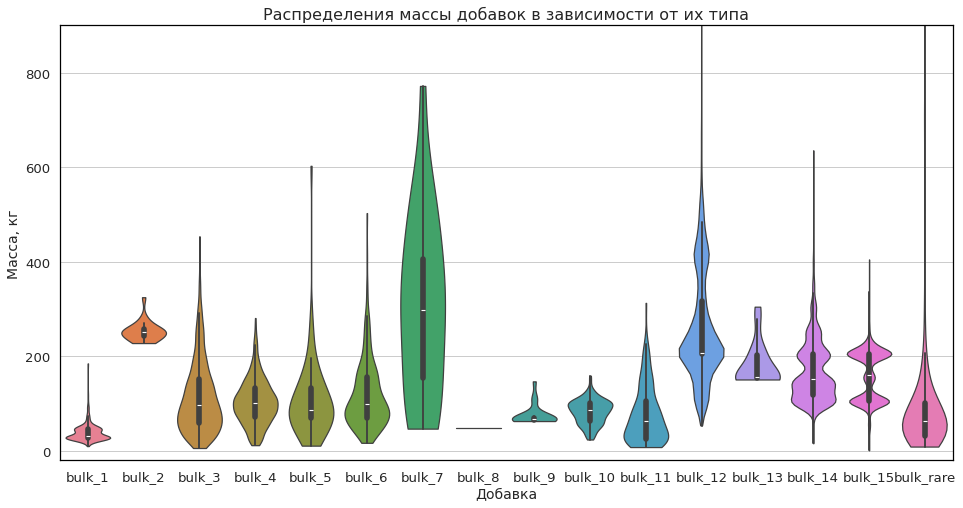

In [63]:
fig = plt.figure(figsize=(16, 8))
sns.violinplot(data=df_bulk.drop('key', axis=1), cut=0)
plt.title('Распределения массы добавок в зависимости от их типа', fontsize=16)
plt.ylabel('Масса, кг', fontsize=14)
plt.xlabel('Добавка', fontsize=14)
plt.ylim(-20, 900);

- Видим, что средняя масса каждой добавки в партии находится в пределах 50-200 кг
- Есть отдельные выбросы в некоторых распределениях добавок, что видно по хвостам, бывают и в реальности такие партии с сложным начальным составом стали, которую нужно сильно доводить
- Так же есть двухмодные распределения вроде `bulk_15`, где наблюдаются два пика, вероятно, по начальному составу стали в этом плане есть некоторая стабильность, либо это обязательная стандартизированная добавка
- Добавки массой более 500 кг редкое явление, поэтому можно рассмотреть идею дополнительного признака с флагом такой добавки
- Средняя масса в `bulk_rare` хорошо отражает средние составляющих, и распределение в целом хорошее, тогда составляющие его признаки выбросим

In [64]:
df_bulk.drop(bulks_rare, axis=1, inplace=True)

In [65]:
df_bulk['heavy_bulk_flag'] = (
    df_bulk.drop('key', axis=1).max(axis=1) > 500
).astype(int)
print('Добавок весом больше 500 кг - ', df_bulk['heavy_bulk_flag'].sum())

Добавок весом больше 500 кг -  123


Пропуски в `df_bulk` заполним нулями, так как материал в таких случаях не добавляли, что равносильно тому, что добавили 0 кг (по материалам в интернете можно предположить, что у нас вес добавки указан в кг)

In [66]:
df_bulk.fillna(0, inplace=True)

Теперь нам надо проверить на адеквтность временные данные по добавкам. Добавим столбцы `begin_time` и `end_time` из `df_temp_agg` для проверки, что время добавки находится в пределах между первым и последним измерением температуры. Тогда точно процесс будет адекватным в плане времен, так как мы уже смотретли на полное время в `df_temp`

In [67]:
# Будем проверять те партии, для которых у нас есть как минмум два измерения температуры
df_ = df_temp_agg[['begin_meas_time', 'end_meas_time', 'key']].drop_duplicates().copy()
df_ = df_bulk_time.merge(df_, on='key', how='right').copy()

In [68]:
def check_times(row):

    min_time = row['begin_meas_time']
    max_time = row['end_meas_time']
    times = row.drop(['key', 'begin_meas_time', 'end_meas_time']).dropna()

    return np.all((times >= min_time) & (times <= max_time))

In [69]:
df_['times_ok'] = df_.apply(check_times, axis=1)
problematic_rows = df_[df_['times_ok'] == False]
print('Проблемных строк - ', len(problematic_rows))

Проблемных строк -  0


Отлично, все добавки происходят в промежутке между началом и концом измерений температуры для каждой партии

**Вывод**

- Выбросы оставили, так как на практике бывают тяжелые добавки, если начальный состав стали сильно далек от необходимого
- Выбросили признак `bulk_8` так как у него только 1 значение
- Пропуски заполнили 0, так как это равносильно отсутствию добавки
- Средняя масса каждой добавки в партии находится в пределах 50-200 кг
- Проверили, что время введения добавок происходит между первым и последним измерением внутри каждой партии
- Добавили дополнительный признак-флаг `heavy_bulk_flag` - наличие добавки весом больше 500 кг (всего 112 таких)
- Добавили признак `bulk_rare` как составной из редко используемых добавок `bulk_2`, `bulk_9`, `bulk_13`, `bulk_7`, `bulk_1`, `bulk_5`, `bulk_10`, `bulk_11`
- Использовать для объединения будем `df_bulk`, `df_bulk_time` далее использовать не будем

#### Данные о проволочных добавках `df_wire` и `df_wire_time`
[[К началу главы](#Part_1)]

Посмотрим еще раз на статистики

In [70]:
df_wire.describe()

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
count,3081.000,3055.000,1079.000,63.000,14.000,1.000,73.000,11.000,19.000,29.000
mean,1623.426,100.896,50.577,189.483,57.443,15.132,48.017,10.039,53.625,34.156
std,932.997,42.013,39.320,99.513,28.825,NaN,33.920,8.611,16.882,19.932
min,1.000,1.919,0.030,0.144,24.149,15.132,0.034,0.234,45.077,4.623
25%,823.000,72.116,20.194,95.135,40.807,15.132,25.054,6.763,46.095,22.058
50%,1619.000,100.158,40.143,235.195,45.234,15.132,42.076,9.017,46.280,30.066
75%,2434.000,126.060,70.228,276.252,76.125,15.132,64.213,11.886,48.090,43.862
max,3241.000,330.314,282.780,385.009,113.231,15.132,180.455,32.848,102.762,90.054


112 таких добавок

- Заметных выбросов здесь нет
- В `wire_5` - только одно значение, здесь логика аналогичная `df_bulk`

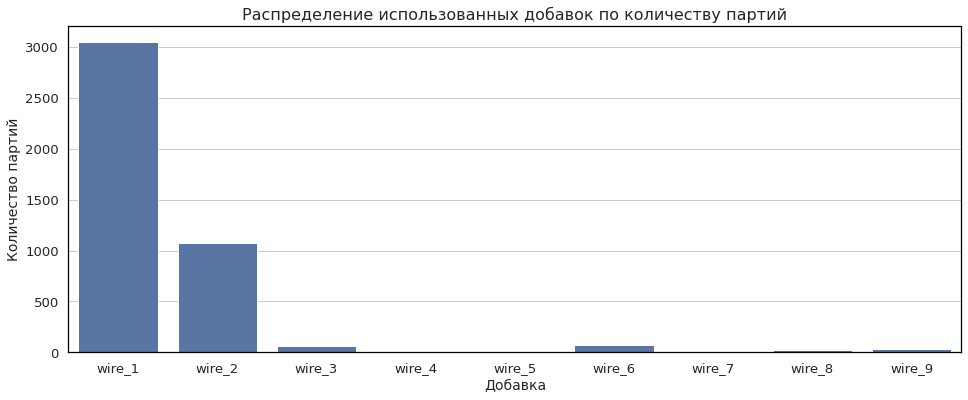

In [71]:
fig = plt.figure(figsize=(16, 6))
sns.barplot(df_wire.drop('key', axis=1).count())
plt.title('Распределение использованных добавок по количеству партий', fontsize=16)
plt.ylabel('Количество партий', fontsize=14)
plt.xlabel('Добавка', fontsize=14);

- Видим, что чаще всего используются добавки `wire_1` и `wire_2` - первая - около 3000 партий, вторая - около 100 партий
- Остальные используются очень редко - меньше 80 партий, так же как и в `df_bulk` объединим их в один признак `wire_rare`

In [72]:
wire_rare = [
    'wire_3',
    'wire_4',
    'wire_5',
    'wire_6',
    'wire_7',
    'wire_8',
    'wire_9'
]
df_wire['wire_rare'] = df_wire[wire_rare].sum(axis=1, min_count=1)
df_wire['wire_rare'].describe()

count    164.000
mean     112.084
std      104.771
min        0.034
25%       30.066
50%       52.138
75%      221.234
max      385.009
Name: wire_rare, dtype: float64

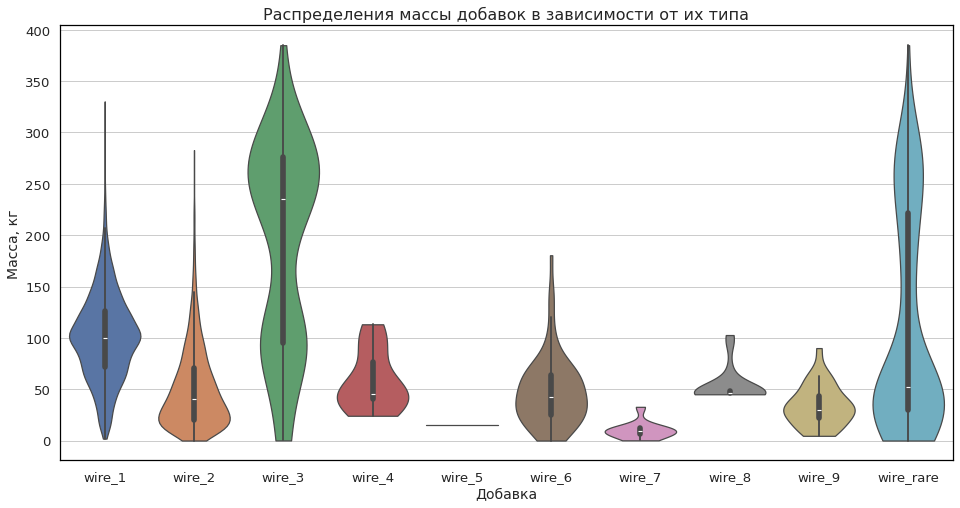

In [73]:
fig = plt.figure(figsize=(16, 8))
sns.violinplot(data=df_wire.drop('key', axis=1), cut=0)
plt.title('Распределения массы добавок в зависимости от их типа', fontsize=16)
plt.ylabel('Масса, кг', fontsize=14)
plt.xlabel('Добавка', fontsize=14);

- Видим, что средняя масса каждой добавки в партии находится в пределах 50-100 кг, кроме `wire_3` - 240 кг
- Есть отдельные выбросы в некоторых распределениях добавок, что видно по хвостам, бывают и в реальности такие партии с сложным начальным составом стали, которую нужно сильно доводить
- По `wire_rare` так же как и в `df_bulk`, хорошо что решили не выбрасывать редкие, так как есть большие массы в некоторых партиях, которые могут сильно понижать температуру

In [74]:
df_wire.drop(wire_rare, axis=1, inplace=True)

Пропуски в `df_wire` заполним нулями, аналогично `df_bulk`

In [75]:
df_wire.fillna(0, inplace=True)

Теперь нам надо проверить на адеквтность временные данные по добавкам. Будем действовать аналогично алгоритму в `df_bulk`

In [76]:
# Будем проверять те партии, для которых у нас есть как минмум два измерения температуры
df_ = df_temp_agg[['begin_meas_time', 'end_meas_time', 'key']].drop_duplicates().copy()
df_ = df_wire_time.merge(df_, on='key', how='right').copy()

In [77]:
df_['times_ok'] = df_.apply(check_times, axis=1)
problematic_rows = df_[df_['times_ok'] == False]
print(f'Проблемных строк: {len(problematic_rows)}')

Проблемных строк: 0


Отлично, все добавки происходят в промежутке между началом и концом измерений температуры для каждой партии

**Вывод**

- Выбросы оставили, так как на практике бывают тяжелые добавки, если начальный состав стали сильно далек от необходимого
- Выбросили признак `wire_5` так как у него только 1 значение
- Пропуски заполнили 0, так как это равносильно отсутствию добавки
- Средняя масса каждой добавки в партии находится в пределах 50-100 кг
- Проверили, что время введения добавок происходит между первым и последним измерением внутри каждой партии
- Добавили признак `wire_rare` как составной из редко используемых добавок `wire_3`, `wire_4`, `wire_5`, `wire_6`, `wire_7`, `wire_8`, `wire_9`
- Использовать для объединения будем `df_wire`, `df_wire_time` далее использовать не будем

<a name="Conclusion_1"></a>
#### Вывод
[[К началу главы](#Part_1)] [[К началу раздела](#Main_Part_1)]

Подготовили данные к агрегированию и проанализировали промежуточные результаты:


- Температура `df_temp_agg`
    - Выбросили партии с одним измерением (741 партия, 23 %) или начальной температурой <1500°C (4 партии) — осталась 2471 партия
    - Агрегировали данные по партиям и сделали следующие признаки
        - `begin_temp` - стартовая температура партии
        - `end_temp` - конечная температура партии - **целевой признак**
        - `time_total` - полное время затраченное на партию
        - `begin_meas_time` - время первого измерения
        - `end_meas_time` - время последнего измерения


- Электроды `df_arc_agg`
    - Всего 3214 уникальных партий
    - Поправили аномальное значение с помощью регрессии
    - Агрегировали данные по партиям и создали дополнительные признаки
        - `time_total_arc` - полное время работы электродов
        - `time_avg_arc` - среднее время работы электродов за период
        - `act_power_avg` - средяя активная мощность
        - `act_power_peak` - пиковая активная мощность
        - `Q_act_total` - полная активная энергия электродов
        - `Q_eff_total` - полная эффективная энергия
        - `Q_eff_last` - эффективная энергия за последний период
        - `cos_phi_avg` - средний коэффициент мощности
        - `n_periods` - количество периодов работы электродов

- Газ `df_gas`
    - Все в порядке


- Добавки сыпучие `df_bulk`
    - Признак `bulk_8` удалён (1 значение), пропуски заменены на 0
    - Выбросы оставили, так как на практике бывают тяжелые добавки, если начальный состав стали сильно далек от необходимого
    - Составлены агрегаты и добавлены флаги:
      - `heavy_bulk_flag` — масса одной добавки > 500 кг (112 партий)
      - `bulk_rare` — агрегат редких добавок, менее 80 партий по каждой добавке (668 партий), составляющие признаки удалены
    - Проверено, что все добавки вносились между измерениями


- Добавки проволочные `df_wire`
    - `wire_5` удалён (1 значение), пропуски заменены на 0
    - По выбросам аналогично
    - Создан признак `wire_rare` — агрегат редких добавок, менее 70 партий по каждой добавке (164 партии), составляющие признаки удалены
    - Проверено, что все добавки вносились между измерениями


<a name="Part_2"></a>
### Агрегация данных и анализ признаков
[[К началу раздела](#Main_Part_1)]

Так как по условию, мы точно значем, что во все партии точно добавлялись сыпучие **и** проволочные материалы, везде была выполнена продувка газом и сплав всегда нагревался, то объединять данные будем через `inner`

In [78]:
dataframes = [df_temp_agg, df_arc_agg, df_gas, df_bulk, df_wire]
df = reduce(
    lambda left, right: pd.merge(left, right, on=['key'], how='inner'),
    dataframes
)
df.drop(['begin_meas_time', 'end_meas_time'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   key              2325 non-null   int64  
 1   time_total       2325 non-null   int64  
 2   begin_temp       2325 non-null   float64
 3   end_temp         2325 non-null   float64
 4   time_total_arc   2325 non-null   float64
 5   time_avg_arc     2325 non-null   float64
 6   act_power_avg    2325 non-null   float64
 7   act_power_peak   2325 non-null   float64
 8   Q_act_total      2325 non-null   float64
 9   Q_eff_total      2325 non-null   float64
 10  Q_eff_last       2325 non-null   float64
 11  cos_phi_avg      2325 non-null   float64
 12  n_arc_periods    2325 non-null   int64  
 13  gas              2325 non-null   float64
 14  bulk_3           2325 non-null   float64
 15  bulk_4           2325 non-null   float64
 16  bulk_6           2325 non-null   float64
 17  bulk_12       

- Отлично, 2325 партий, у которых есть начальное и конечное измерение температуры и с ними производились все операции

#### Конечная температура `end_temp`
[[К началу главы](#Part_2)]

Еще раз для того, чтобы было рядом

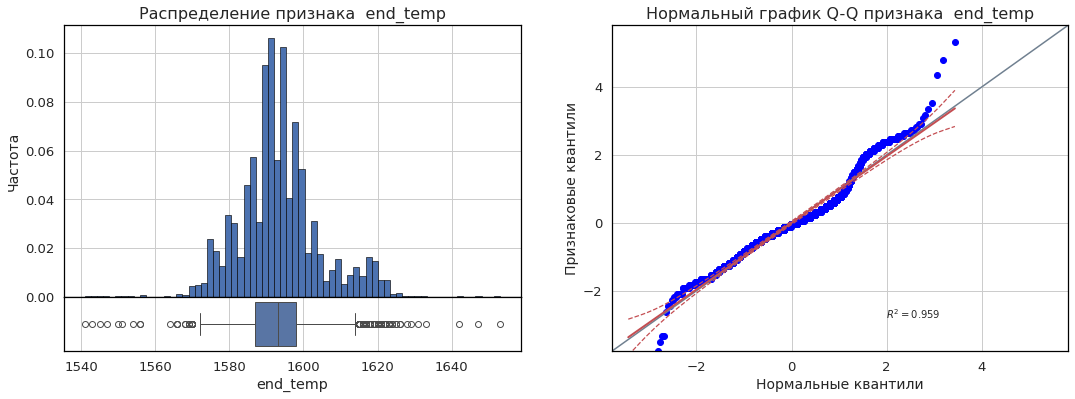

,count,mean,std,min,25%,50%,75%,max
end_temp,2325.000,1593.366,11.210,1541.000,1587.000,1593.000,1598.000,1653.000


In [79]:
describe_column(df['end_temp'])

- Распределение опять же частично похоже на нормальное, но наблюдается мультимодальность (1593, 1615)
- Стоит подумать над введением дополнительных признаков, если их распределение будет не совсем похоже на нормальное, так как распределение целевого признака далеко от нормального

#### Полное время обработки стали `time_total`
[[К началу главы](#Part_2)]

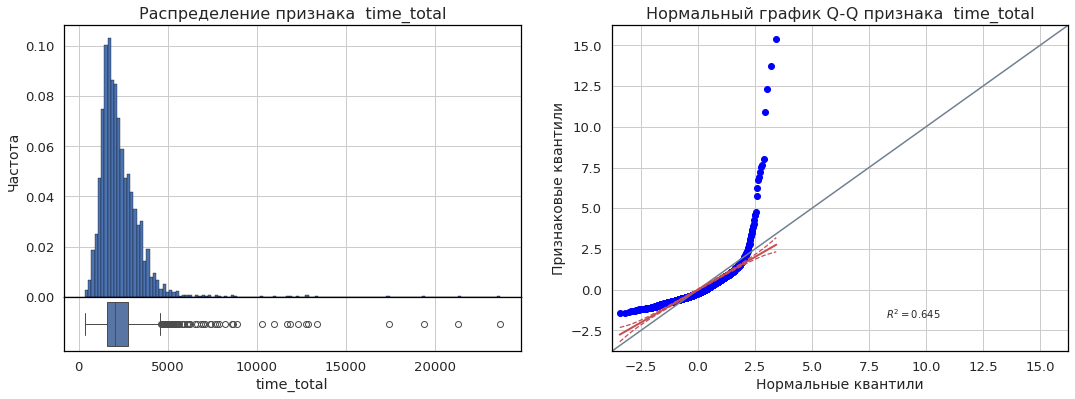

,count,mean,std,min,25%,50%,75%,max
time_total,2325.000,2323.420,1385.569,339.000,1581.000,2046.000,2793.000,23674.000


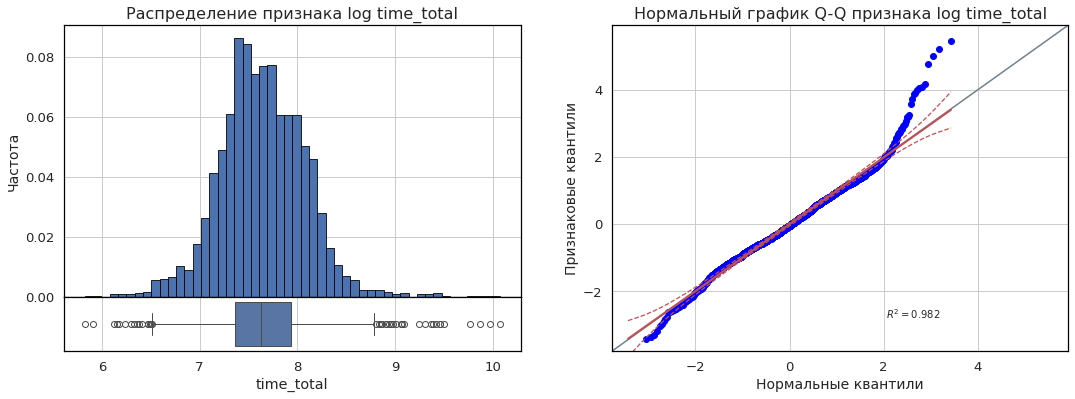

,count,mean,std,min,25%,50%,75%,max
time_total,2325.000,7.643,0.445,5.826,7.366,7.624,7.935,10.072


In [80]:
describe_column(df['time_total'])
describe_column(np.log(df['time_total']), add_title='log')

- Распределение признака ближе к логнормальному, есть сильные выбросы, посмотрим на них
- Медианное время на партию - 2046 с
- Минимальное - 339 с, максимальное - 23674 с, почти 6.5 часов, тут сложно сказать, в теории могут быть и такие долгие процессы в редких случаях, например, когда была очередь на процессе, если температура поддерживалась в допустимых пределах, оставим

In [81]:
df.query('time_total > 15000')

,key,time_total,begin_temp,end_temp,time_total_arc,time_avg_arc,act_power_avg,act_power_peak,Q_act_total,Q_eff_total,Q_eff_last,cos_phi_avg,n_arc_periods,gas,bulk_3,bulk_4,bulk_6,bulk_12,bulk_14,bulk_15,bulk_rare,heavy_bulk_flag,wire_1,wire_2,wire_rare
593,641,17467,1617.000,1580.000,1413.000,235.500,0.580,0.712,790.000,639.578,21.970,0.815,6,20.985,0.000,60.000,0.000,208.000,0.000,156.000,153.000,0,221.177,0.000,0.000
1575,1689,23674,1583.000,1606.000,4189.000,279.267,0.825,1.186,3718.054,3042.366,102.739,0.810,15,33.597,0.000,0.000,247.000,733.000,248.000,224.000,305.000,1,187.153,0.000,0.000
1831,1958,19409,1579.000,1570.000,1834.000,166.727,0.629,0.921,1138.561,912.808,22.064,0.787,11,32.450,31.000,0.000,175.000,310.000,180.000,202.000,0.000,0,123.309,150.106,0.961
1969,2108,21331,1639.000,1541.000,2739.000,171.188,0.669,1.233,1761.888,1443.739,52.169,0.816,16,45.639,0.000,98.000,0.000,0.000,0.000,0.000,906.000,1,11.051,0.000,249.883


- 4 партии дольше 4 часов каждая
- У трех партий количество нагревов больше 10, у одной - 6, вероятно сложная партия, что может быть на практике, поэтому выбрасывать не будем
- Альтернативным вариантом могло бы быть отдельное выделение этих партий, чтобы потом закинуть в тестовую выборку, убрав из обучающей, попробуем так поступить

In [82]:
df_outliers = df.query('time_total > 15000').copy()
df = df.query('time_total <= 15000')

#### Полное время работы электродов `time_total_arc`
[[К началу главы](#Part_2)]

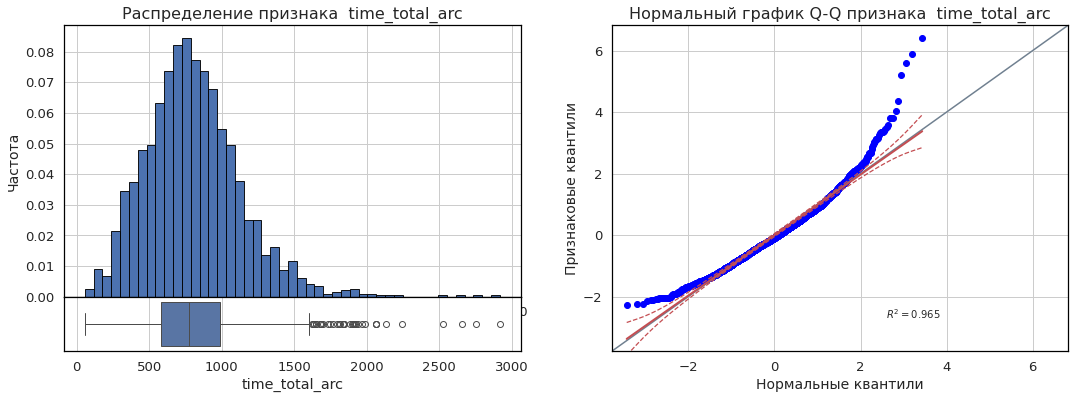

,count,mean,std,min,25%,50%,75%,max
time_total_arc,2321.000,805.044,330.470,57.000,581.000,778.000,992.000,2919.000


In [83]:
describe_column(df['time_total_arc'])

- Распределение признака нормальное с небольшим числом выбросов
- Медианное время дуги за партию - 778 с
- Минимальное - 57 с, максимальное - 2919 с, опять же может быть тот долгий процесс
- Добавим дополнительный признак `time_total_arc_log`
- Так же добавим дополнительный признак простоя, т.е. времени партии без дуги - `time_total_idle` и его логарифм. Признак `time_total` соответственно уберем, так как мы его разбили на составляющие через простую ЛК с коэф. 1

In [84]:
df['time_total_idle'] = df['time_total'] - df['time_total_arc']
df['time_total_idle_log'] = np.log(df['time_total_idle'])
df.drop('time_total', axis=1, inplace=True)

df_outliers['time_total_idle'] = (
    df_outliers['time_total'] - df_outliers['time_total_arc']
)
df_outliers['time_total_idle_log'] = np.log(df_outliers['time_total_idle'])
df_outliers.drop('time_total', axis=1, inplace=True)

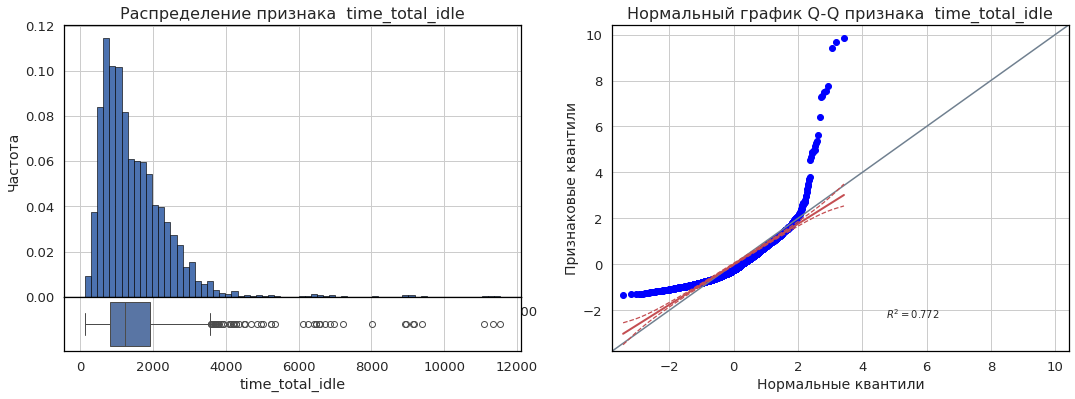

,count,mean,std,min,25%,50%,75%,max
time_total_idle,2321.000,1487.102,1019.472,130.000,807.000,1240.000,1922.000,11534.000


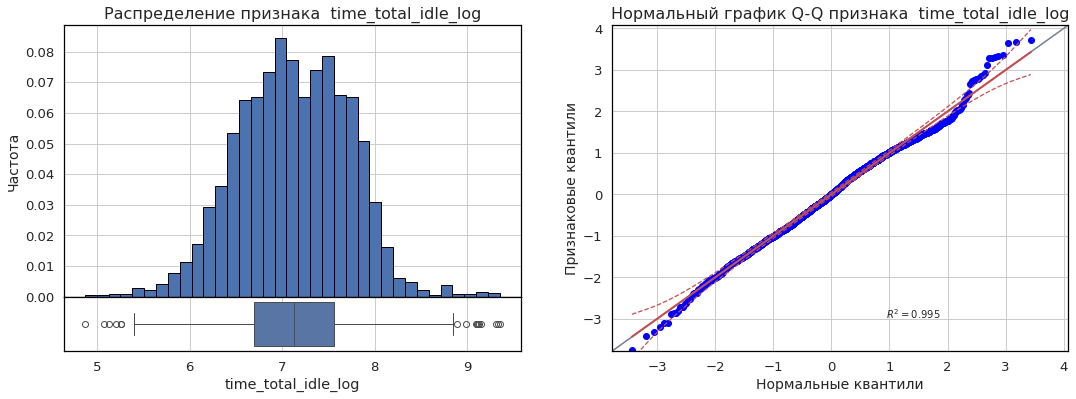

,count,mean,std,min,25%,50%,75%,max
time_total_idle_log,2321.000,7.123,0.602,4.868,6.693,7.123,7.561,9.353


In [85]:
describe_column(df['time_total_idle'])
describe_column(df['time_total_idle_log'])

#### Среднее время работы электродов `time_avg_arc`
[[К началу главы](#Part_2)]

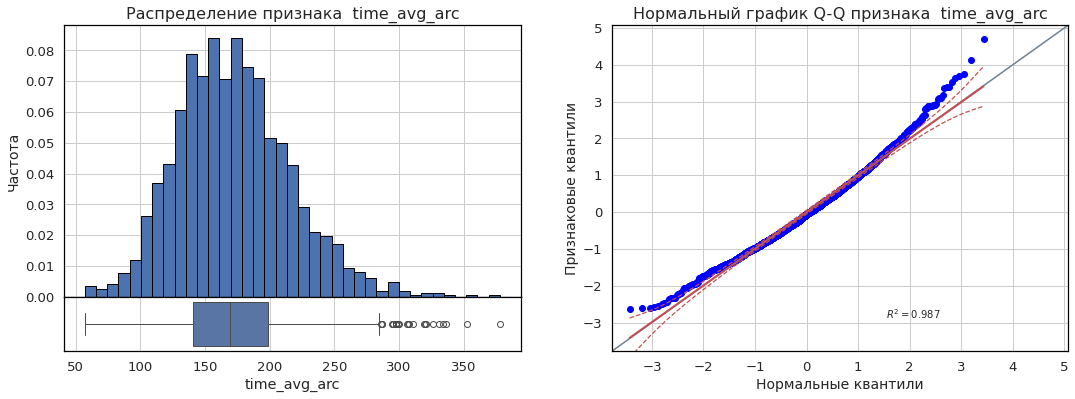

,count,mean,std,min,25%,50%,75%,max
time_avg_arc,2321.000,172.020,43.712,57.000,141.000,169.500,198.750,378.000


In [86]:
describe_column(df['time_avg_arc'])

- Распределение нормальное
- Среднее время дуги 172 ± 44 с

#### Средняя активная мощность `act_power_avg`
[[К началу главы](#Part_2)]

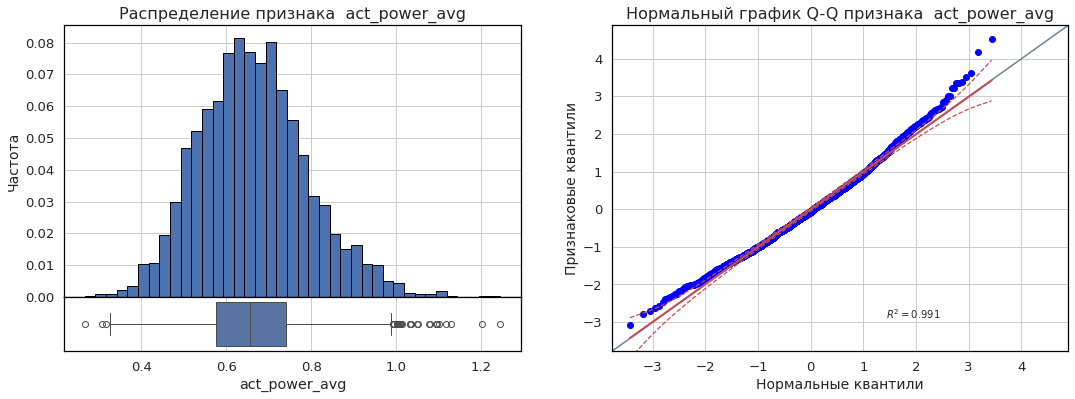

,count,mean,std,min,25%,50%,75%,max
act_power_avg,2321.000,0.664,0.128,0.268,0.576,0.656,0.742,1.244


In [87]:
describe_column(df['act_power_avg'])

- Распределение нормальное
- Средняяя активная мощность дуги 0.66 ± 0.13

#### Пиковая активная мощность `act_power_peak`
[[К началу главы](#Part_2)]

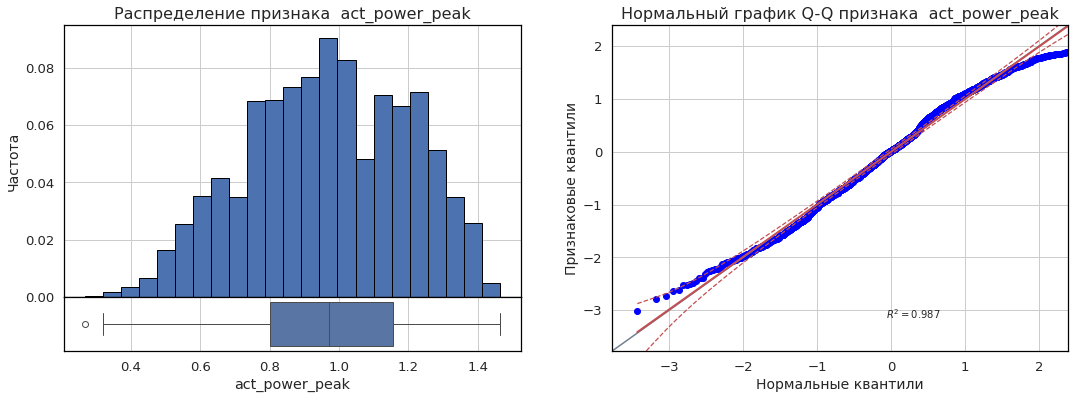

,count,mean,std,min,25%,50%,75%,max
act_power_peak,2321.000,0.968,0.232,0.268,0.802,0.972,1.157,1.464


In [88]:
describe_column(df['act_power_peak'])

- Распределение в целом нормальное, со смещением вправо
- Средняяя пиковая активная мощность дуги 0.97 ± 0.23

#### Полная активная энергия `Q_act_total`
[[К началу главы](#Part_2)]

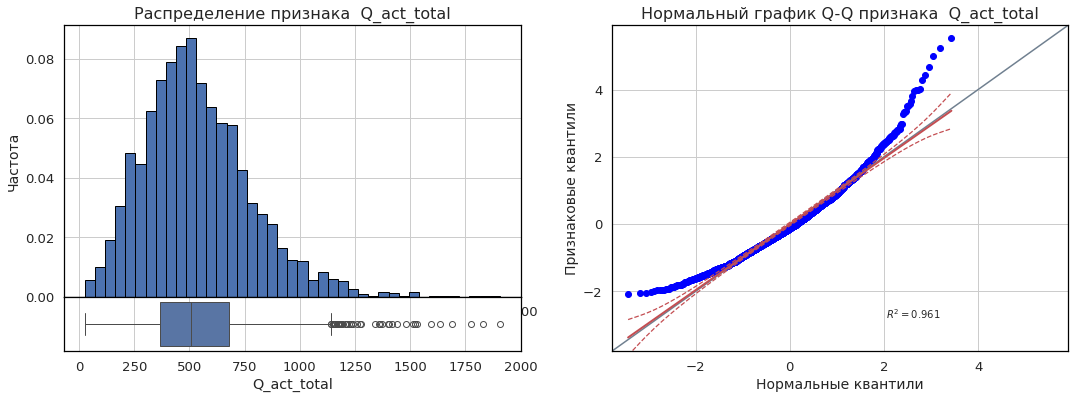

,count,mean,std,min,25%,50%,75%,max
Q_act_total,2321.000,537.011,247.244,26.188,368.130,507.869,677.728,1906.195


In [89]:
describe_column(df['Q_act_total'])

- Распределение в целом нормальное, с небольшим сдвигом влево
- Средняя активная энергия за партию 537 ± 247

#### Полная эффективная энергия `Q_eff_total`
[[К началу главы](#Part_2)]

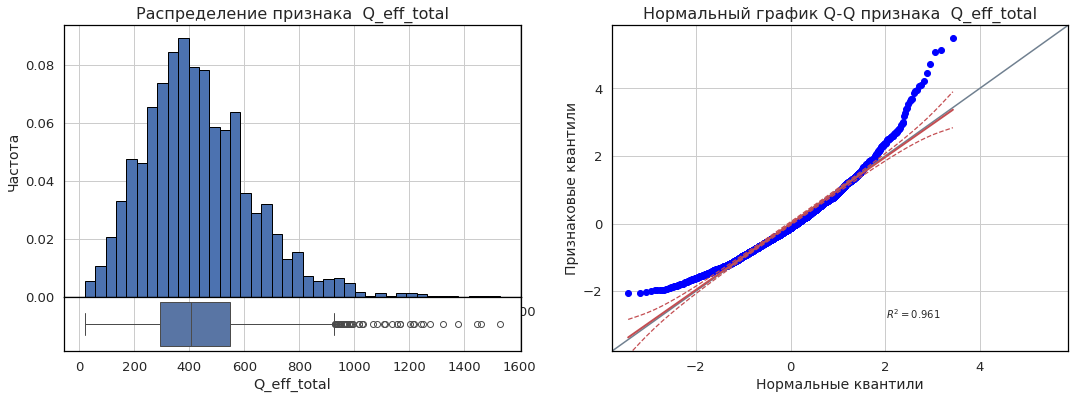

,count,mean,std,min,25%,50%,75%,max
Q_eff_total,2321.000,432.646,199.359,20.514,294.677,408.005,548.355,1528.538


In [90]:
describe_column(df['Q_eff_total'])

- Распределение в целом нормальное, со средним сдвигом влево, похоже на распределение активной энергии
- Средняя эффективная энергия за партию - 432 ± 199

#### Последняя эффективная энергия `Q_eff_last`
[[К началу главы](#Part_2)]

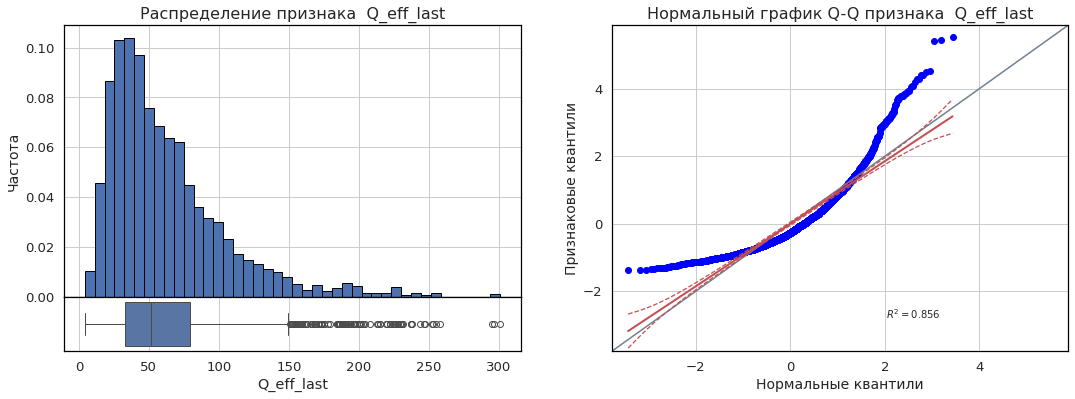

,count,mean,std,min,25%,50%,75%,max
Q_eff_last,2321.000,62.939,42.940,4.234,32.832,51.343,79.747,300.819


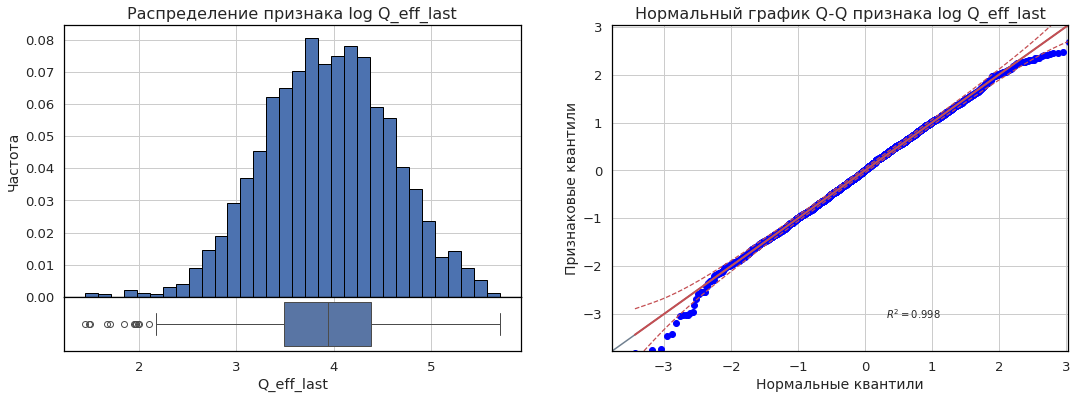

,count,mean,std,min,25%,50%,75%,max
Q_eff_last,2321.000,3.935,0.654,1.443,3.491,3.939,4.379,5.707


In [91]:
describe_column(df['Q_eff_last'])
describe_column(np.log(df['Q_eff_last']), add_title='log')

- Распределение логнормальное
- Медианное значение последней эффективной энергии за партию - 51.3

#### Средний коэффициент мощности `cos_phi_avg`
[[К началу главы](#Part_2)]

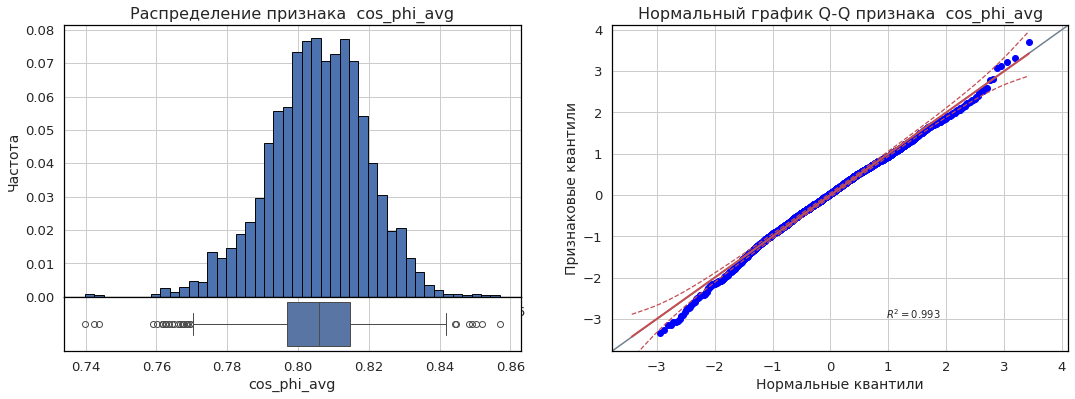

,count,mean,std,min,25%,50%,75%,max
cos_phi_avg,2321.000,0.805,0.014,0.740,0.797,0.806,0.815,0.857


In [92]:
describe_column(df['cos_phi_avg'])

- Распределение нормальное
- Средний коэффициент мощности 0.81 ± 0.01

#### Количество запусков электродов `n_arc_periods`
[[К началу главы](#Part_2)]

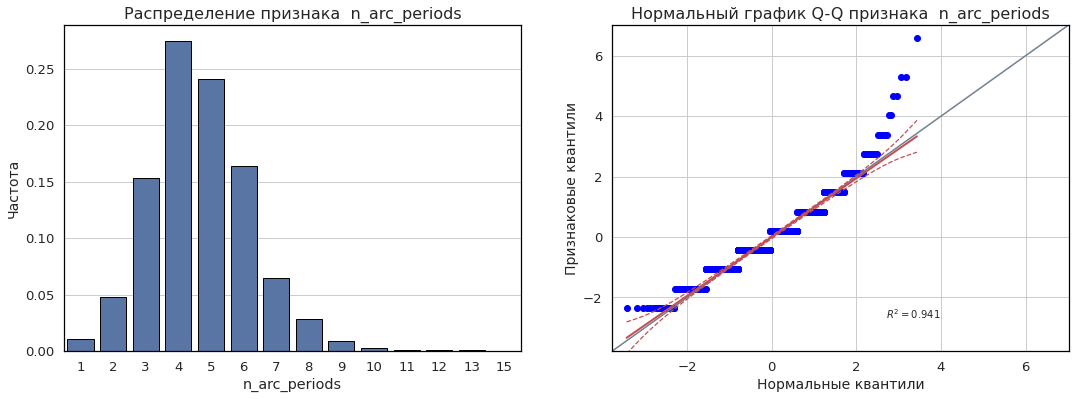

,count,mean,std,min,25%,50%,75%,max
n_arc_periods,2321.000,4.684,1.570,1.000,4.000,5.000,6.000,15.000


In [93]:
describe_column(df['n_arc_periods'])

- Распределение нормальное, с длинным правым хвостом
- Медианное количество дуг - 5

#### Объем газа `gas`
[[К началу главы](#Part_2)]

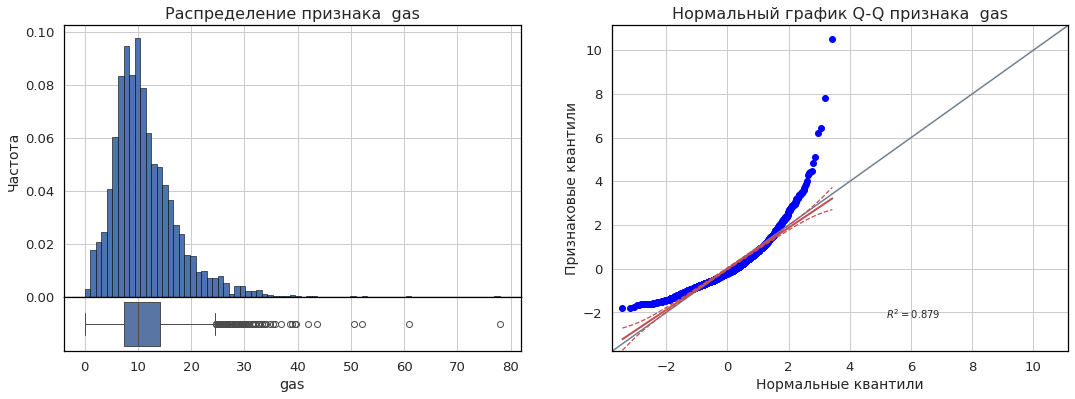

,count,mean,std,min,25%,50%,75%,max
gas,2321.000,11.341,6.326,0.008,7.281,10.092,14.184,77.995


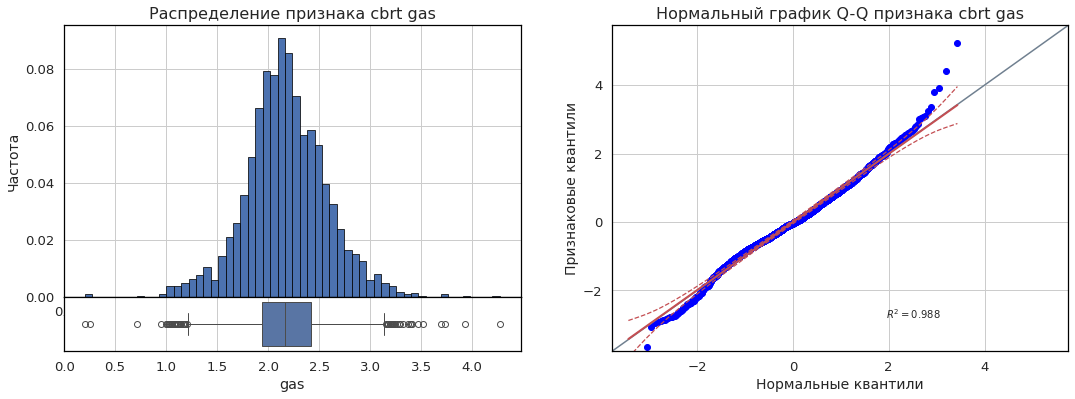

,count,mean,std,min,25%,50%,75%,max
gas,2321.000,2.175,0.400,0.203,1.938,2.161,2.421,4.273


In [94]:
describe_column(df['gas'])
describe_column(np.cbrt(df['gas']), add_title='cbrt')

- Распределение с сильным смещением
- Средняя 11.3 ± 6.3
- Добавим дополнительный признак - `gas_cbrt`

In [95]:
df['gas_cbrt'] = np.cbrt(df['gas'])
df_outliers['gas_cbrt'] = np.cbrt(df_outliers['gas'])

In [96]:
df.drop('key', axis=1, inplace=True)
df_outliers.drop('key', axis=1, inplace=True)

del (
    df_temp,
    df_arc,
    df_bulk_time,
    df_wire_time,
    df_bulk,
    df_wire,
    df_temp_agg,
    df_arc_agg,
    df_gas
)

<a name="Conclusion_2"></a>
#### Вывод
[[К началу главы](#Part_2)] [[К началу раздела](#Main_Part_1)]

Успешно агрегировали данные и провели анализ новых признаков


- Температура
    - Начальная температура близка к нормальному распределению, со средней **1589 °C**  
    - Конечная температура в среднем выше (**1595 °C**), распределение с вытянутыми хвостами


- Время обработки
    - Полное время `time_total` логнормально, с редкими длинными партиями до 6.5 часов (4 партии), возможно, реальные технологические задержки
    - Отделили эти партии, чтобы потом присоединить к тестовой выборке
    - `time_total` разложен на `time_total_arc` (дуга) и `time_total_idle` (простой), добавлены логарифмические версии


- Мощность и энергия
    - Распределения активной и эффективной энергии близки к нормальным, `Q_eff_total` введён как полезная энергия с учётом коэффициента мощности `cos_phi`, который получали через активную и реактивную мощность
    - `Q_eff_last` логнормально распределена и отражает вклад последнего нагрева стали электродами


- Дополнительные параметры
    - `cos_phi` - коэффициент мощности, распределен нормально  
    - `n_arc_periods` — число включений дуги — с длинным правым хвостом, можно понимать как маркер сложности партии


- Газ
    - Распределение объёма газа сильно скошено, добавлен стабилизирующий признак `gas_cbrt`


- Добавки сыпучие и проволочные
    - Использовали как есть, после первичных преобразований выше
    - Средняя масса сыпучих добавок в партии находится в пределах 50-200 кг
    - Средняя масса проволочных добавок в партии находится в пределах 50-100 кг

### Корреляционный анализ
[[К началу раздела](#Main_Part_1)]

In [97]:
df['end_temp'] = df.pop('end_temp')
df_outliers['end_temp'] = df_outliers.pop('end_temp')

In [98]:
interval_cols = [
    'time_total_arc',
    'time_total_idle',
    'time_avg_arc',
    'act_power_avg',
    'act_power_peak',
    'Q_act_total',
    'Q_eff_total',
    'Q_eff_last',
    'cos_phi_avg',
    'gas',
    'time_total_arc_log',
    'time_total_idle_log',
    'gas_cbrt',
    'wire_1',
    'wire_2',
    'wire_rare'
]

corr_matrix = df.phik_matrix(interval_cols=interval_cols)

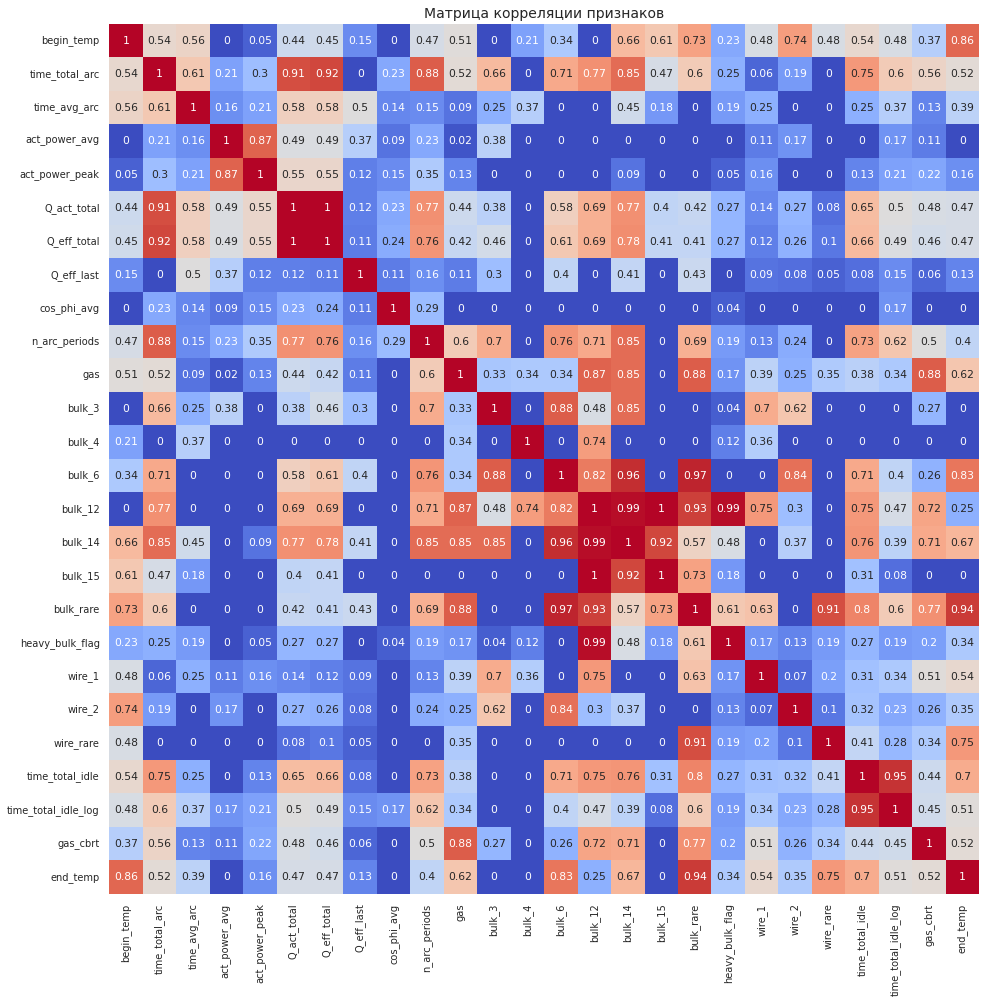

In [99]:
sns.set(font_scale=.9)
plt.figure(figsize=(16, 16))
plt.title('Матрица корреляции признаков', fontsize=14)
sns.heatmap(
    corr_matrix.round(2),
    annot = True, square=True,
    cmap='coolwarm',
    cbar=False
);

Оставим полную матрицу для полноты картины и, если необходимо будет вернуться к деталям, а для удобства разобьем ее на две части - с добавками и без

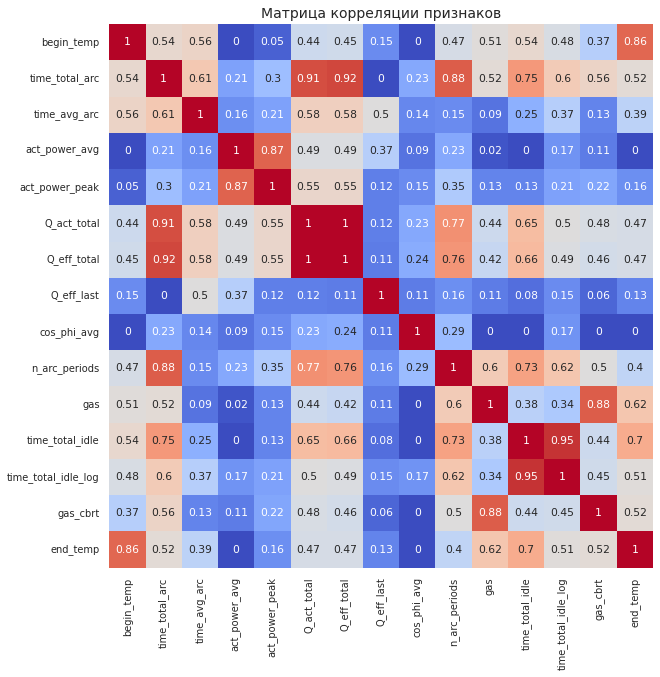

In [100]:
df_ = df.drop(df.loc[:, 'bulk_3':'wire_rare'].columns, axis=1)

corr_matrix = df_.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(10, 10))
plt.title('Матрица корреляции признаков', fontsize=14)
sns.heatmap(
    corr_matrix.round(2),
    annot = True,
    square=True,
    cmap='coolwarm',
    cbar=False
);

- С целевым признаком `end_temp`
    - Сильно коррелирует
        - `begin_temp` - 0.86 оно и понятно, начальная температура
    - Хорошо
        - временные признаки - чуть больше 0.5 в среднем, время простоя - 0.7       
        - Полные энергии (акт. и эфф.) - 0.47
        - количество нагревов - 0.4
        - газ - около 0.6
    - Слабо или вообще нет
        - `Q_eff_last`
        - `act_power_avg`
        - `act_power_peak`
        - `cos_phi_avg`


- Сильные корреляции входных признаков
    - `Q_act_total` и `Q_eff_total` - ниже на графике видно, что в целом да, просто средняя разница между ними около 100, но все же сильный разброс и не маленькая дисперсия, может оказаться важным, поэтому оставим оба, так как эффективная учитывает степерь износа электродов через коэффициент мощности, но для линейной регрессии и нейронной сети уберем `Q_act_total`
    - Признаков теплоты с временными признаками, но оно понятно, потому что формула расчета простая через умножение
    - Временных признаков между собой, но тут тоже, были либо вообще простая разность двух временных признаков, либо логарифм

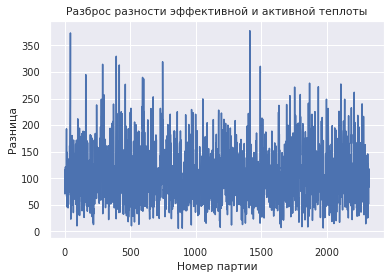

In [101]:
(df['Q_act_total'] - df['Q_eff_total']).plot(
    title='Разброс разности эффективной и активной теплоты',
    xlabel='Номер партии',
    ylabel='Разница'
);

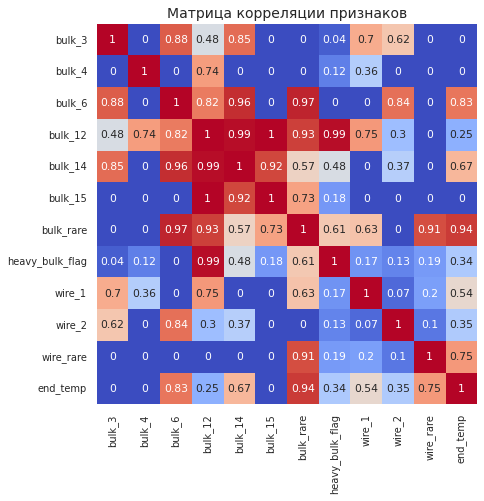

In [102]:
df_ = pd.concat([df.loc[:, 'bulk_3':'wire_rare'], df['end_temp']], axis=1)

corr_matrix = df_.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(7, 7))
plt.title('Матрица корреляции признаков', fontsize=14)
sns.heatmap(
    corr_matrix.round(2),
    annot=True,
    square=True,
    cmap='coolwarm',
    cbar=False
);

sns.set(font_scale=1.2)
sns.set_style('whitegrid', {'axes.edgecolor': 'black'})

- С целевым признаком `end_temp`
    - Сильно коррелирует
        - `bulk_rare` - 0.94 - возможно из-за того, что здесь как раз находятся партии с сложными обработками, у которых был выброс по целевой температуре, либо добавки тяжелые/реактивные
        - `bulk_6` - 0.83, аналогично
        - `wire_rare` - 0.75, аналогично
    - Хорошо
        - `bulk_14` - 0.67
        - `wire_1` - 0.54       
        - `wire_2` - 0.35
        - `heavy_bulk_flag` - 0.34
        - `bulk_12` - 0.25
    - Слабо или вообще нет
        - `bulk_3`
        - `bulk_4`
        - `bulk_15`


- Сильные корреляции входных признаков
    - `bulk_12` и почти все остальные, возможно это какая-то стандартная добавка, которая идет во все партии, то есть всегда необходима

Проведем VIF анализ. Так как мультиколлинеарность оказывает сильное влияние на линейную регресию и в какой-то степени для нейронных сетей, то выбросим `time_total` для оценки, для соответствующих моделей сделаем то же самое

feature,const,Q_act_total,Q_eff_total,time_total_arc,n_arc_periods,gas,gas_cbrt,time_avg_arc,time_total_idle_log,time_total_idle,act_power_avg,act_power_peak,bulk_12,cos_phi_avg,begin_temp,bulk_15,bulk_14,heavy_bulk_flag,Q_eff_last,wire_1,bulk_rare,bulk_4,bulk_6,wire_rare,bulk_3,wire_2
VIF,18182.986,1447.562,1444.581,39.894,17.106,11.939,11.416,10.643,5.834,5.349,5.085,3.035,3.031,2.393,2.193,1.908,1.641,1.507,1.463,1.408,1.405,1.356,1.277,1.198,1.155,1.148


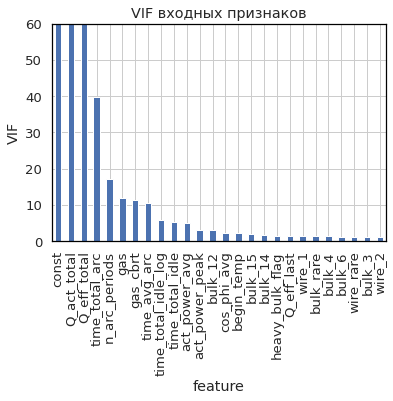

In [103]:
df_ = add_constant(df.drop('end_temp', axis=1))

vif_data = pd.DataFrame()
vif_data['feature'] = df_.columns
vif_data['VIF'] = [variance_inflation_factor(df_.values, i)
                          for i in range(df_.shape[1])]
display(vif_data.sort_values(by='VIF', ascending=False).set_index('feature').T)

(
    vif_data
    .sort_values(by='VIF', ascending=False)
    .plot(kind='bar',
          x='feature',
          legend=False,
          ylabel='VIF',
          ylim=(0,60),
          title='VIF входных признаков'
         )
);

- Довольно неплохо получилось, всего 3 признака с заметно большим коэффициентом инфляции дисперсии
- Опять есть проблема с `Q_eff_total` и `Q_act_total`, но объяснение было выше

### Вывод
[[К началу раздела](#Main_Part_1)]

После успешной обработки и агрегации осталось 2325 уникальных партий

- **Подготовка и предобработка для агрегации ([Подробный](#Conclusion_1))**
    - Проведена очистка и агрегирование данных по партиям: исключены неполные и аномальные значения, сформированы целевые таблицы
    - Температуры, электроды, газ, сыпучие и проволочные добавки агрегированы с расчетом дополнительных признаков


- **Распределения и признаки ([Подробный](#Conclusion_2))**
    - Температура - стартовая распределена нормально, конечная — с вытянутыми хвостами, но в пределах нормы
    - Время обработки стали - логнормальное, выявлены редкие, но возможные длинные процессы, учтены через разбиение на нагрев и простой
    - Электроды - распределения признаков (мощность, энергия, количество запусков) преимущественно нормальные, последняя эффективная энергия — логнормальное
    - Газ - скошенное распределение, добавлена кубическая корневая трансформация
    - Добавки - агрегированы, редкие и тяжелые добавки вынесены в отдельные признаки; составные признаки созданы и лишние удалены


- **Итоговые признаки**
    - `begin_temp` - стартовая температура партии
    - `end_temp` - конечная температура партии - **целевой признак**
    - `time_avg_arc` - среднее время работы электродов за период
    - `act_power_avg` - средяя активная мощность
    - `act_power_peak` - пиковая активная мощность
    - `Q_act_total` - полная активная энергия электродов
    - `Q_eff_total` - полная эффективная энергия
    - `Q_eff_last` - эффективная энергия за последний период
    - `cos_phi_avg` - средний коэффициент мощности
    - `n_arc_periods` - количество периодов работы электродов
    - `gas` - объем подаваемого газа
    - `time_total_idle` - время простоя без нагрева
    - `time_total_idle_log` - логарифм времени простоя
    - `gas_cbrt` - кубический корень от объема газа
    - `bulk_3`, `bulk_4`, `bulk_6`, `bulk_12`, `bulk_14`, `bulk_15` - сыпучие добавки
    - `bulk_rare` - объединенные редкие сыпучие добавки
    - `wire_1`, `wire_2` - проволочные добавки
    - `wire_rare` - объединенные редкие проволочные добавки


- **Корреляционный анализ**
    - Сильная корреляция с целевым признаком: `begin_temp`, `bulk_rare`, `bulk_6`, `wire_rare`.
    - Хорошая - временные признаки, энергии, `n_periods`, газ, часть добавок (`wire_1`, `wire_2`, `bulk_12`, `bulk_14`, `heavy_bulk_flag`)
    - Слабая - `Q_eff_last`, средние мощности, `cos_phi`, часть добавок
    - Входовые признаки с сильной взаимной корреляцией (например, `Q_eff_total` и `Q_act_total`) отмечены для исключения при использовании чувствительных моделей

<a name="Main_Part_2"></a>
## Модель предсказания температуры стали
[[Содержание](#Содержание)]

Обучать и оптимизировать гиперпараметры с последующим выбором лучшей модели будем среди следующих вариантов

- Линейная регрессия
    - ElasticNet
- Бустинги
    - LGBM
    - CatBoost
- Ансамбль
    - RandomForest
- Нейронная сеть
    - TabNet
- Мета-модель (Stacking)
    - CatBoost + TabNet

### Подготовка данных
[[К началу раздела](#Main_Part_2)]

In [104]:
X = df.drop('end_temp', axis=1)
y = df['end_temp']

# так как используем MinMax и Robust, то бинарный heavy_bulk_flag останется неизменным
# но позже будет проще собрать таблицу с влиянием признаков
num_cols = list(X.drop(['Q_act_total'], axis=1).columns)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

X_test = pd.concat([X_test, df_outliers.drop('end_temp', axis=1)], ignore_index=False)
y_test = pd.concat([y_test, df_outliers['end_temp']], ignore_index=False)

In [105]:
# Preprocessor = NUM
preprocessor = ColumnTransformer(
    [
        ('num', 'passthrough', num_cols)
    ],
    remainder='passthrough'
)

# Preprocessor + Models
pipe_search = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', ElasticNet(random_state=RANDOM_STATE))
    ])

Отлично, сделали тренировочную и тестовые выборки с размером тестовой 0.25

<a name="Part_3"></a>
### Обучение
[[К началу раздела](#Main_Part_2)]

Создадим всопомогательные функции

- Первые для оптимизации гиперпараметров
- Для сбора результатов оптимизации и обучения

In [106]:
def objective(params, model_type, X, y):

    model = model_type.set_params(**params)
    score = cross_val_score(
        estimator=model,
        X=X,
        y=y,
        scoring='neg_mean_absolute_error', cv=3
    )

    return {'loss': -score.mean(), 'status': STATUS_OK, 'model': model}

def getBestModelfromTrials(trials):

    valid_trial_list = [trial for trial in trials
                            if STATUS_OK == trial['result']['status']]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]

    return best_trial_obj['result']['model'], -round(best_trial_obj['result']['loss'], 3)

def model_search(model_type, param_search, name, X_train, y_train, eval_num=10):

    trials = Trials()
    results = fmin(
        partial(objective, model_type=model_type, X=X_train, y=y_train),
        space=param_search,
        algo=tpe.suggest,
        trials=trials,
        max_evals=eval_num,
        rstate=np.random.default_rng(RANDOM_STATE)
    )

    start = time.time()
    best_model, best_loss = getBestModelfromTrials(trials)
    best_loss = -round(best_loss, 3)
    best_model.fit(X_train, y_train)
    end = time.time()
    fit_time = round(end-start, 2)

    start = time.time()
    pred = best_model.predict(X_train)
    end = time.time()
    predict_time = round(end-start, 2)

    res = y_train-pred
    ci = stats.norm.interval(
        confidence=0.95,
        loc=np.mean(res),
        scale=np.std(res)
    )

    print(f'Время обучения лучшей модели: {predict_time} секунд')
    print(f'Метрика MAE лучшей {name} модели по результатам '
          f'кросс-валидации: {best_loss}')
    display(best_model)
    results = {
        'model': name,
        'cv_mae': best_loss,
        'train_r2' : round(r2_score(y_train, pred), 3),
        'fit_time': fit_time,
        'predict_time': predict_time,
        'mean_residual': np.round(np.mean(res), 1),
        'residuals_95%_CI': np.round(np.array(ci))
    }

    return best_model, results

#### Константная модель
[[К началу главы](#Part_3)]

Чтобы было от чего отталкиваться, посмотрим сначала на константную модель

In [107]:
dummy = DummyRegressor(strategy='median')
dummy.fit(X_train, y_train)
rmse_dummy_train = mean_absolute_error(y_train, dummy.predict(X_train))
print(f'MAE Dummy модели на обучении - {rmse_dummy_train:.4f}')

MAE Dummy модели на обучении - 8.1253


#### ElasticNet
[[К началу главы](#Part_3)]

In [108]:
%%time
elnet_param = {
    'model': ElasticNet(random_state=RANDOM_STATE, max_iter=8000),
    'model__alpha' : hp.choice('model__alpha', list(np.arange(0.01, 1.01, 0.09))),
    'model__l1_ratio' : hp.choice('model__l1_ratio', list(np.arange(0.01, 1.01, 0.09))),
    'model__fit_intercept': hp.choice('model__fit_intercept', [True, False]),
    'preprocessor__num': hp.choice('preprocessor__num__scaler',
                                   [MinMaxScaler(), RobustScaler(), 'passthrough'])
}

model_elnet, res_elnet = model_search(
    pipe_search,
    elnet_param,
    'ElascticNet',
    X_train.drop('Q_act_total', axis=1),
    y_train,
    eval_num=50
)

100%|██████████| 50/50 [00:25<00:00,  1.97trial/s, best loss: 5.984851841404257] 
Время обучения лучшей модели: 0.09 секунд
Метрика MAE лучшей ElascticNet модели по результатам кросс-валидации: 5.985


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  ['begin_temp',
                                                   'time_total_arc',
                                                   'time_avg_arc',
                                                   'act_power_avg',
                                                   'act_power_peak',
                                                   'Q_eff_total', 'Q_eff_last',
                                                   'cos_phi_avg',
                                                   'n_arc_periods', 'gas',
                                                   'bulk_3', 'bulk_4', 'bulk_6',
                                                   'bulk_12', 'bulk_14',
                                                   'bulk_15', 'bulk_rare',
                                                   'heavy_bulk_flag', 'wire_1',
                                                   'wire_2', 'wire_rare',
                                                   'time_total_idle',
                                                   'time_total_idle_log',
                                                   'gas_cbrt'])])),
                ('model',
                 ElasticNet(alpha=0.01, l1_ratio=0.73, max_iter=8000,
                            random_state=210425))])

CPU times: user 14.1 s, sys: 11.5 s, total: 25.6 s
Wall time: 25.7 s


#### LGBM
[[К началу главы](#Part_3)]

In [109]:
%%time
lgbm_param = {
    'max_depth': hp.choice('max_depth', np.arange(1, 5, dtype=int)),
    'n_estimators' : hp.choice('n_estimators', np.arange(100, 1001, 100, dtype=int)),
    'reg_lambda' : hp.choice('reg_lambda', [1, 2, 3, 10]),
    'learning_rate': hp.choice('learning_rate', [0.01, 0.1, 0.001]),
    'colsample_bytree': hp.choice('colsample_bytree', [0.5, 0.75, 1.])
}
model_lgbm, res_lgbm = model_search(
    LGBMRegressor(
        random_state=RANDOM_STATE,
        objective='mae',
        n_jobs=-1,
        verbose=-1),
    lgbm_param,
    'LGBM',
    X_train,
    y_train,
    eval_num=50
)

100%|██████████| 50/50 [00:31<00:00,  1.58trial/s, best loss: 5.94523994143751] 
Время обучения лучшей модели: 0.03 секунд
Метрика MAE лучшей LGBM модели по результатам кросс-валидации: 5.945


LGBMRegressor(colsample_bytree=0.5, learning_rate=0.01, max_depth=1,
              n_estimators=1000, n_jobs=-1, objective='mae',
              random_state=210425, reg_lambda=3, verbose=-1)

CPU times: user 30.4 s, sys: 1.2 s, total: 31.6 s
Wall time: 31.9 s


#### CatBoost
[[К началу главы](#Part_3)]

In [110]:
%%time
catboost_param = {
    'iterations' : hp.choice('iterations', np.arange(100, 1001, 100, dtype=int)),
    'depth': hp.choice('depth', np.arange(1, 5, dtype=int)),
    'l2_leaf_reg' : hp.choice('l2_leaf_reg', [1, 2, 3, 10, 100]),
    'learning_rate': hp.choice('learning_rate', [0.001, 0.01, 0.1]),
    'colsample_bylevel': hp.choice('colsample_bylevel', [0.5, 0.75, 1.])
}

model_catboost, res_catboost = model_search(
    CatBoostRegressor(
        random_seed=RANDOM_STATE,
        thread_count=-1,
        objective='MAE',
        silent=True),
    catboost_param,
    'CatBoost',
    X_train,
    y_train,
    eval_num=50
)

model_catboost.get_params()

100%|██████████| 50/50 [03:36<00:00,  4.34s/trial, best loss: 5.87008654149897] 
Время обучения лучшей модели: 0.0 секунд
Метрика MAE лучшей CatBoost модели по результатам кросс-валидации: 5.87


CPU times: user 1min 49s, sys: 7.51 s, total: 1min 57s
Wall time: 3min 37s


{'loss_function': 'RMSE',
 'random_seed': 210425,
 'silent': True,
 'objective': 'MAE',
 'colsample_bylevel': 0.75,
 'depth': 3,
 'iterations': 400,
 'l2_leaf_reg': 2,
 'learning_rate': 0.1}

#### RandomForest
[[К началу главы](#Part_3)]

In [111]:
%%time
random_forest_param = {
    'n_estimators' : hp.choice('n_estimators', np.arange(100, 501, 100, dtype=int)),
    'criterion' : hp.choice('criterion', ['absolute_error', 'friedman_mse']),
    'max_depth': hp.choice('max_depth', np.arange(8, 21, 2, dtype=int)),
    'min_samples_leaf': hp.choice('min_samples_leaf', np.arange(10, 121, 11, dtype=int))
}

model_forest, res_forest = model_search(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    random_forest_param,
    'RandomForest',
    X_train,
    y_train,
    eval_num=10
)

100%|██████████| 10/10 [03:10<00:00, 19.05s/trial, best loss: 6.286953703423773]
Время обучения лучшей модели: 0.06 секунд
Метрика MAE лучшей RandomForest модели по результатам кросс-валидации: 6.287


RandomForestRegressor(criterion='absolute_error', max_depth=14,
                      min_samples_leaf=21, n_estimators=300, n_jobs=-1,
                      random_state=210425)

CPU times: user 4min, sys: 253 ms, total: 4min 1s
Wall time: 4min 2s


#### TableNet
[[К началу главы](#Part_3)]

Отдельно создадим валидационную выборку из тренировочной для обучения нейронной сети

In [112]:
X_train_nn, X_valid_nn, y_train_nn, y_valid_nn = train_test_split(
    X_train.drop('Q_act_total', axis=1),
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_nn)
X_valid_scaled = scaler.transform(X_valid_nn)
X_test_scaled = scaler.transform(X_test.drop('Q_act_total', axis=1))

In [113]:
space = {
    'n_d': hp.choice('n_d', [8, 16, 32]),
    'n_a': hp.choice('n_a', [8, 16, 32]),
    'n_independent': hp.choice('n_independent', [2, 3]),
    'n_shared': hp.choice('n_shared', [2, 3]),
    'n_steps': hp.choice('n_steps', [2, 3, 4]),
    'learning_rate': hp.loguniform('learning_rate', np.log(1e-3), np.log(1e-1)),
    'batch_size': hp.choice('batch_size', [512, 256]),
}

In [114]:
def objective_fun(params):
    model = TabNetRegressor(
        n_d=params['n_d'],
        n_a=params['n_a'],
        n_independent=params['n_independent'],
        n_shared=params['n_shared'],
        n_steps=params['n_steps'],
        gamma=1.3,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=params['learning_rate']),
        scheduler_params={"step_size":10, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        device_name='cuda',
        seed=RANDOM_STATE,
        verbose=0
    )

    model.fit(
        X_train=X_train_scaled,
        y_train=y_train_nn.values.reshape(-1, 1),
        eval_set=[(X_valid_scaled, y_valid_nn.values.reshape(-1, 1))],
        eval_name=["val"],
        eval_metric=["mae"],
        max_epochs=300,
        patience=20,
        batch_size=params['batch_size'],
        virtual_batch_size=128,
        drop_last=False
    )

    return {'loss': model.best_cost,
            'status': STATUS_OK,
            'model': model,
            'params': params}

In [115]:
trials = Trials()
results = fmin(
    fn=objective_fun,
    space=space,
    algo=tpe.suggest,
    trials=trials,
    max_evals=10,
    rstate=np.random.default_rng(RANDOM_STATE)
)

Stop training because you reached max_epochs = 300 with best_epoch = 299 and best_val_mae = 1541.80508
                                                                                 
Early stopping occurred at epoch 193 with best_epoch = 173 and best_val_mae = 7.15393
                                                                                 
Early stopping occurred at epoch 46 with best_epoch = 26 and best_val_mae = 49.99755
Stop training because you reached max_epochs = 300 with best_epoch = 299 and best_val_mae = 1508.98432
Stop training because you reached max_epochs = 300 with best_epoch = 299 and best_val_mae = 1346.70392
                                                                               
Early stopping occurred at epoch 63 with best_epoch = 43 and best_val_mae = 19.55198
Stop training because you reached max_epochs = 300 with best_epoch = 299 and best_val_mae = 1436.01328
Stop training because you reached max_epochs = 300 with best_epoch = 299 and best_val_ma

In [116]:
model_tabnet, loss_tabnet = getBestModelfromTrials(trials)

start_time = trials.best_trial['book_time']
end_time = trials.best_trial['refresh_time']
fit_time = (end_time - start_time).seconds

start_time = time.time()
pred = model_tabnet.predict(
    scaler.transform(X_train.drop('Q_act_total', axis=1)))[:,0]
end_time = time.time()
predict_time = round(end_time-start_time, 2)

res = y_train-pred
ci = stats.norm.interval(confidence=0.95,
                         loc=np.mean(res),
                         scale=np.std(res))

res_tabnet = {
    'model': 'TabNet',
    'cv_mae': round(-loss_tabnet, 3),
    'train_r2': round(r2_score(y_train, pred), 3),
    'fit_time': fit_time,
    'predict_time': predict_time,
    'mean_residual': np.round(np.mean(res), 1),
    'residuals_95%_CI': np.round(np.array(ci))
}

print('Batch_size = ', [512, 256][results['batch_size']])
model_tabnet

Batch_size =  512


TabNetRegressor(n_d=16, n_a=16, n_steps=4, gamma=1.3, cat_idxs=[], cat_dims=[], cat_emb_dim=[], n_independent=2, n_shared=3, epsilon=1e-15, momentum=0.02, lambda_sparse=0.001, seed=210425, clip_value=1, verbose=0, optimizer_fn=<class 'torch.optim.adam.Adam'>, optimizer_params={'lr': 0.02392181375899124}, scheduler_fn=<class 'torch.optim.lr_scheduler.StepLR'>, scheduler_params={'step_size': 10, 'gamma': 0.9}, mask_type='entmax', input_dim=24, output_dim=1, device_name='cuda', n_shared_decoder=1, n_indep_decoder=1, grouped_features=[])

#### Мета-модель (Stacking)
[[К началу главы](#Part_3)]

При дальнейшем анализе предыдущих моделей появилась идея объединить модели CatBoost и TabNet, чтобы учесть сильные стороны и частично нивелировать слабые. Для этого подготовим дополнительно обучающую и тестовые выборки. Верхнеуровневой моделью выберем снова CatBoost

In [117]:
y_pred_catboost = model_catboost.predict(X_train)
y_pred_TabNet = model_tabnet.predict(
    scaler.transform(X_train.drop('Q_act_total', axis=1))
)[:,0]

X_train_combined = np.column_stack([y_pred_catboost, y_pred_TabNet])

In [118]:
%%time
meta_param = {
    'iterations' : hp.choice('iterations', np.arange(50, 201, 10, dtype=int)),
    'depth': hp.choice('depth', np.arange(1, 5, dtype=int)),
    'l2_leaf_reg' : hp.choice('l2_leaf_reg', [0.1, 1, 2, 3, 10]),
    'learning_rate': hp.choice('learning_rate', [0.001, 0.01, 0.1])
}

model_meta, res_meta = model_search(
    CatBoostRegressor(
        random_seed=RANDOM_STATE,
        thread_count=-1,
        #objective='MAE',
        silent=True),
    meta_param,
    'MetaModel',
    X_train_combined,
    y_train,
    eval_num=50
)

type(model_meta).__name__ = 'MetaModel'
res_meta['fit_time'] = (
    res_meta['fit_time'] + res_catboost['fit_time'] + res_tabnet['fit_time']
)
res_meta['predict_time'] = (
    res_meta['predict_time'] + res_catboost['predict_time'] + res_tabnet['predict_time']
)

model_meta.get_params()

100%|██████████| 50/50 [01:30<00:00,  1.81s/trial, best loss: 4.488006405985902]
Время обучения лучшей модели: 0.0 секунд
Метрика MAE лучшей MetaModel модели по результатам кросс-валидации: 4.488


CPU times: user 6.91 s, sys: 985 ms, total: 7.89 s
Wall time: 1min 31s


{'loss_function': 'RMSE',
 'random_seed': 210425,
 'silent': True,
 'depth': 4,
 'iterations': 120,
 'l2_leaf_reg': 3,
 'learning_rate': 0.1}

### Анализ моделей
[[К началу раздела](#Main_Part_2)]

Посмотрим на результаты оптимизации и обучения всех моделей

In [119]:
def model_analysis(model, y_true, X_true):

    name = type(model).__name__
    if name=='Pipeline':
       name =  type(model['model']).__name__

    fig = plt.figure(figsize=(16, 5))
    gs = gridspec.GridSpec(1, 2)
    ax_res = plt.subplot(gs[0, 0])
    ax_var = plt.subplot(gs[0, 1])

    if name=='TabNetRegressor':
        y_pred = model.predict(
            scaler.transform(X_true.drop('Q_act_total', axis=1))
        )[:,0]
    else:
        y_pred = model.predict(X_true)
    residuals = y_true - y_pred
    # Строим гистограмму
    ax_res.hist(residuals, bins=20, zorder=3, edgecolor='black')
    ax_res.grid()
    ax_res.set_title(f'Гистограмма распределения остатков \n{name} модели')
    ax_res.set_ylabel('Частота', fontsize=14)
    ax_res.set_xlabel('Остатки', fontsize=14)

    # Строим распределение реальных и предсказанных значений
    df_ = (
        pd.concat([y_true.reset_index(drop='True'), pd.Series(y_pred)], axis=1)
        .sort_values(by='end_temp')
        .reset_index(drop=True)
    )
    df_.columns=['end_temp', 'pred_temp']

    sns.scatterplot(
        x=df_.index, y=df_['end_temp'],  color='navy', alpha=0.7, ax=ax_var
    )
    sns.scatterplot(
        x=df_.index, y=df_['pred_temp'],  color='red', alpha=0.5, ax=ax_var
    )
    ax_var.grid()
    ax_var.set_title(
        f'Распределение истинной и предсказанной температуры \n{name} модели'
    )
    ax_var.set_ylabel('Температура, С', fontsize=14)
    ax_var.set_xlabel('Партия', fontsize=14)
    ax_var.legend(['Реальные данные', 'Предсказание']);

In [120]:
comparison = pd.DataFrame(
    {key: [res_elnet[key],
           res_lgbm[key],
           res_catboost[key],
           res_forest[key],
           res_tabnet[key],
           res_meta[key]] for key in res_elnet
    }
)
comparison = comparison.sort_values(by='cv_mae')

,model,cv_mae,train_r2,fit_time,predict_time,mean_residual,residuals_95%_CI
5,MetaModel,4.488,0.710,148.780,0.390,0.000,"[-12.0, 12.0]"
2,CatBoost,5.870,0.662,1.060,0.000,0.700,"[-12.0, 14.0]"
1,LGBM,5.945,0.352,0.190,0.030,1.000,"[-17.0, 19.0]"
0,ElascticNet,5.985,0.531,0.100,0.090,0.000,"[-15.0, 15.0]"
3,RandomForest,6.287,0.489,52.390,0.060,0.500,"[-15.0, 16.0]"
4,TabNet,7.154,0.292,147.000,0.390,1.000,"[-18.0, 19.0]"


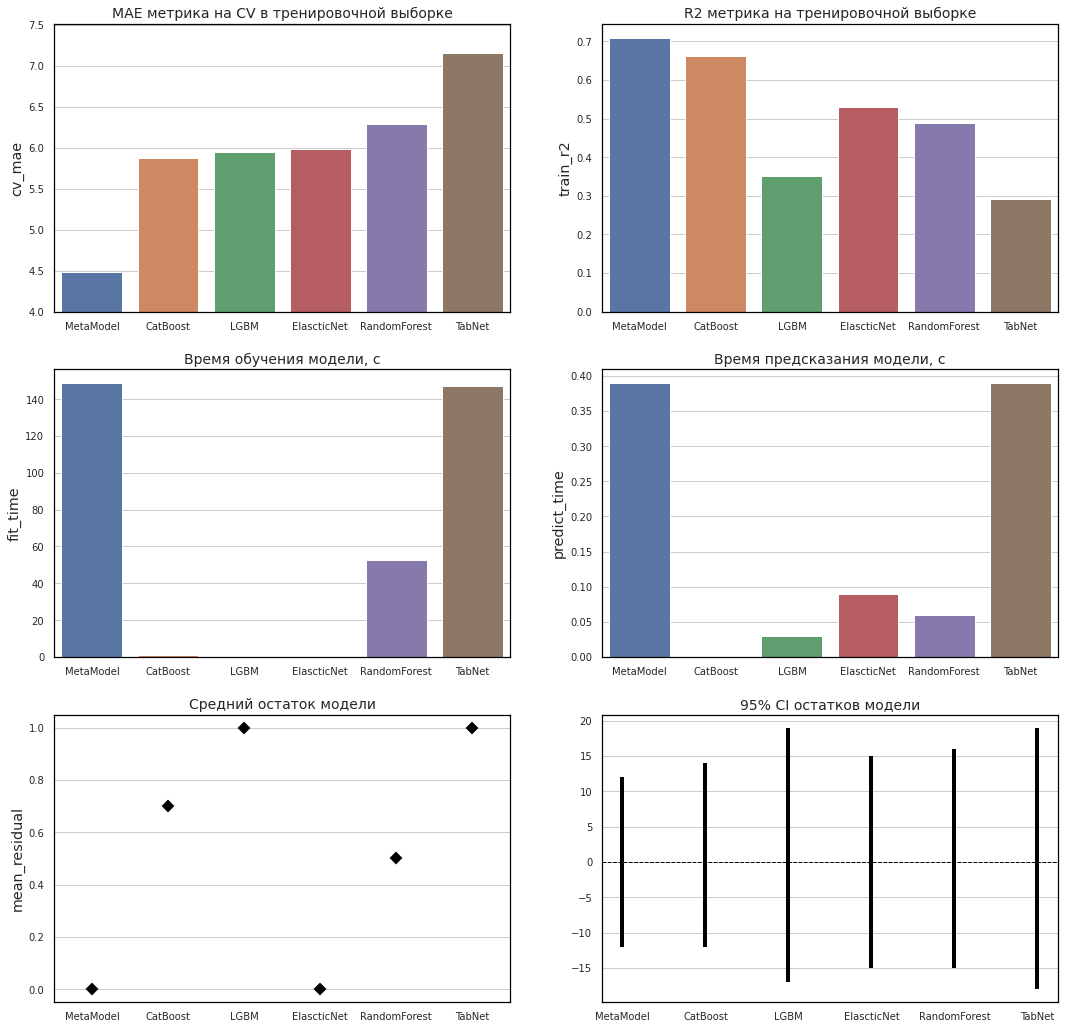

In [121]:
titles = [
    'MAE метрика на CV в тренировочной выборке',
    'R2 метрика на тренировочной выборке',
    'Время обучения модели, с',
    'Время предсказания модели, с'
]

fig, ax = plt.subplots(3, 2, figsize=(18, 18))

for idx, col in enumerate(comparison.iloc[:,1:-2]):
    bar = sns.barplot(
        data=comparison,
        x='model',
        y=col,
        hue='model',
        ax=ax[idx//2][(idx+2)%2]
    )
    bar.set_title(f'{titles[idx]}', fontsize=14)
    bar.set_xlabel('')
    ax[idx//2][(idx+2)%2].tick_params(axis='both', which='major', labelsize=10)

sns.pointplot(
    data=comparison,
    x='model',
    y='mean_residual',
    linestyle="none",
    marker="D",
    color='black',
    ax=ax[2][0]
).set_title('Средний остаток модели', fontsize=14)
ax[2,0].tick_params(axis='both', which='major', labelsize=10)
ax[2,0].set_xlabel('')

ci_stat = np.array(comparison['residuals_95%_CI'].tolist()).T
ci_stat[0,:] *= -1
ax[2,1].errorbar(x=comparison['model'], y=np.zeros(6),
             color='black', fmt='none', yerr=ci_stat, linewidth=4)
ax[2,1].set_xlabel('')
ax[2,1].grid(axis='x')
ax[2,1].axhline(y=0, linestyle='--', color='black', linewidth=1)
ax[2,1].set_title('95% CI остатков модели', fontsize=14)
ax[2,1].tick_params(axis='both', which='major', labelsize=10)

ax[0,0].set_ylim(bottom=4)
comparison

- MAE метрика
    - Все модели прошли порог метрики в 6.8 на кросс-валидации или, в случае нейронной сети на обычной валидации
    - Все одиночные модели показывают довольно близкие результаты, RandomForest немного хуже остальных
        - Модель `CatBoost` с метрикой - 5.88
        - Далее тройка `LGBM`, `TabNet` и `ElasticNet` с метрикой 5.95 - 5.98
        - Хуже всех - `RandomForest` - 6.29
    - **Лучшая модель - Stacking Catboost и Tabnet (далее мета-модель) - 4.49**


- Время обучения
    - **`CatBoost`, `LGBM` и `ElasticNet` обучаются достаточно быстро**
    - `TabNet` и `RandomForest` ощутимо дольше
    - Мета-модель - из-за `TabNet` так же долго

- Время предсказания
    - `Tabnet`, `RandomForest` и мета-модель - показывают среднее время
    - **`Catboost`, `LGBM`, и `ElasticNet` - очень быстро**

- R2 метрика
    - **Лучшая - мета-модель - 0.73**
    - `CatBoost` и `TabNet` заметно лучше остальных одиночных - (0.65 и 0.63)
    - `ElasticNet` посередение списка - 0.53
    - `LGBM` и `RandomForest` - довольно низкие значения (0.35б 0.34)
    

- Средний остаток и 95% CI
    - Предсказания бустингов в среднем больше на 1 градус, у случайного леса - 0.5, а у остальных моделей смещение около 0
    - Разброс остатков у одиночных меньше всего у `CatBoost`, `ElasticNet`, `RandomForest` и `Tabnet` - около ± 15
    - **Мета-модель - смещение 0, 95% CI - [-11.0, 11.0]**
    - `LGBM` - около ±20

- По разным оценкам есть разные пары моделей, которые показывают близкие резльтаты, но скорее всего это будет двойка `CatBoost` и `TabNet` - по MAE, R2 и 95 % CI остатков
- Посмотрим визуально на распределение предсказаний на тренировочной выборке и сравним с реальными значениями температуры
- Определенно надежды на мета-модель

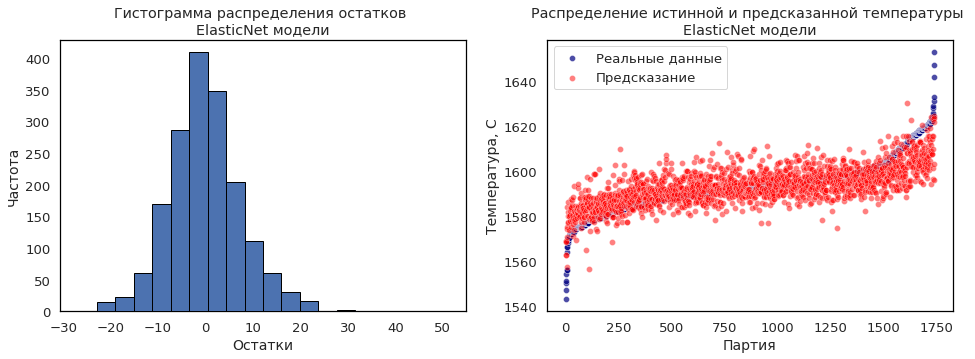

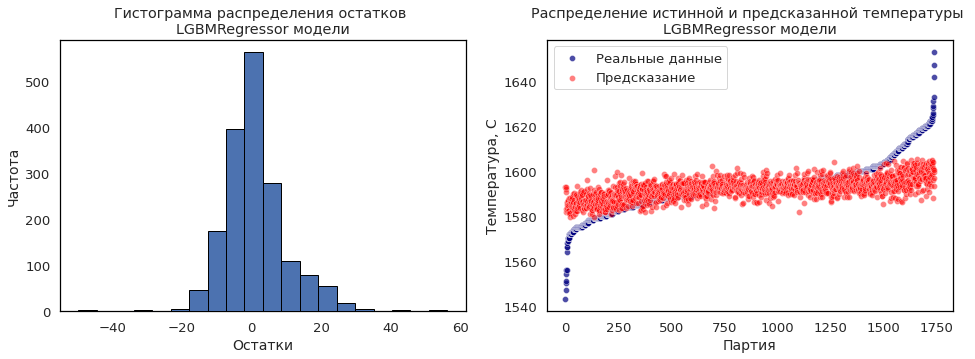

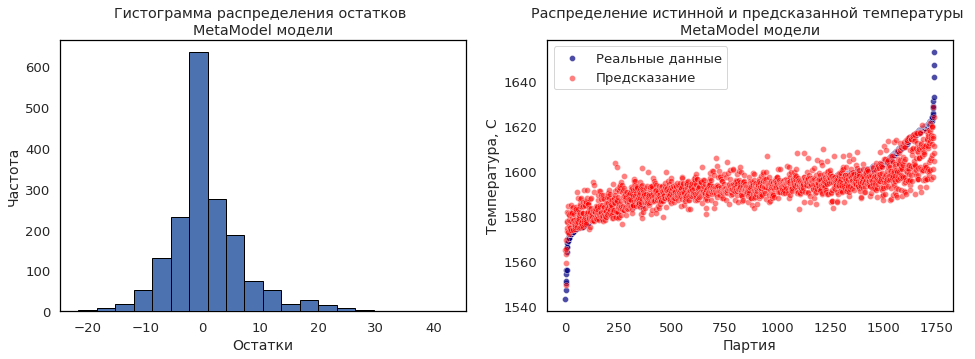

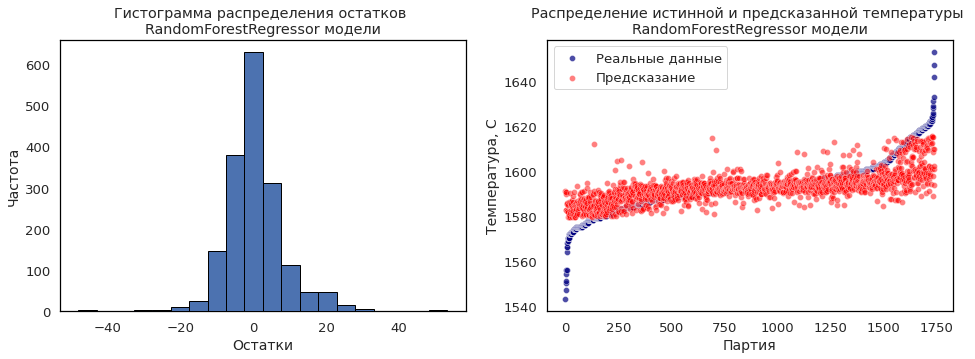

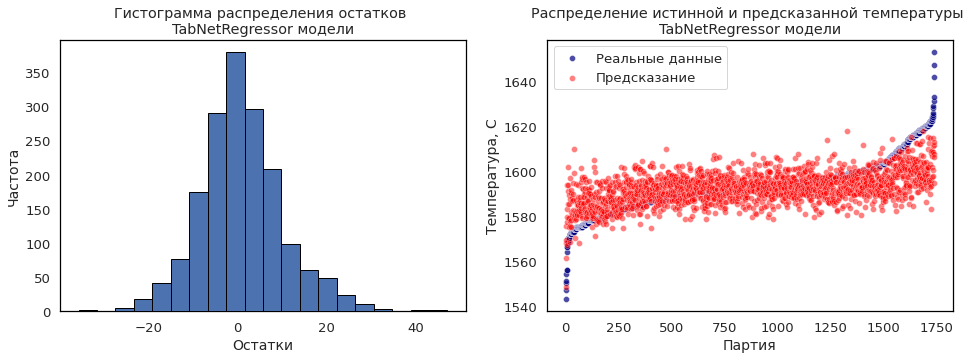

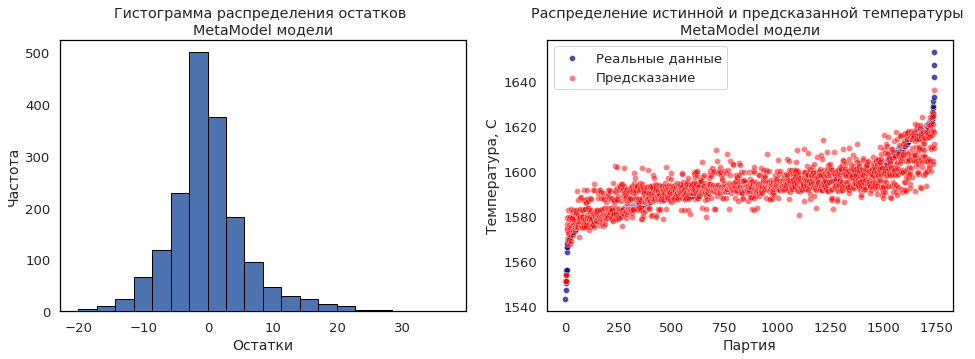

In [122]:
model_analysis(model_elnet, y_train, X_train)
model_analysis(model_lgbm, y_train, X_train)
model_analysis(model_catboost, y_train, X_train)
model_analysis(model_forest, y_train, X_train)
model_analysis(model_tabnet, y_train, X_train)
model_analysis(model_meta, y_train, X_train_combined)

- Сразу бросется проблема у `LGBM` - в области сильных отклонений от средней температуры выборки и выбросах, явно не тянет, но зато в области средних лучше остальных моделе. Отдаленно напоминает константную модель
- `RandomForest` - похоже на ситуацию с `LGBM`
- `ElasticNet` довольно сильно выделяется дисперсией предсказаний, но за счет этого лучше, чем `LGBM` ведет себя в дали от средней температуры выборки
- `TabNet` очень хорошо дает предсказания и повторяет форму реального распределения, но дисперсия великовата, если бы в области средних температур ее подужать - было бы идеально
- `CatBoost` очень похож на `TabNet`, только дисперсия предсказаний заметно меньше, что дает форму распределения в области температур выше средней чуть хуже, чем у `TabNet`
- На этом этапе возникла идея объединить `Catboost` и `TabNet` в мета-модель в форме `CatBoost`(`CatBoost`, `TabNet`). Результаты на лицо, распределение очень хорошо повторяет реальное распределение температур у партий, да есть небольшая дисперсия, но она стала явно ниже, чем была у моделей по отдельности. Супер!

Взглянем на важность признаков у всех моделей. Мета-модель как составная из `CatBoost` и `TabNet` и на нее распространяется комбинация их анализа признаков

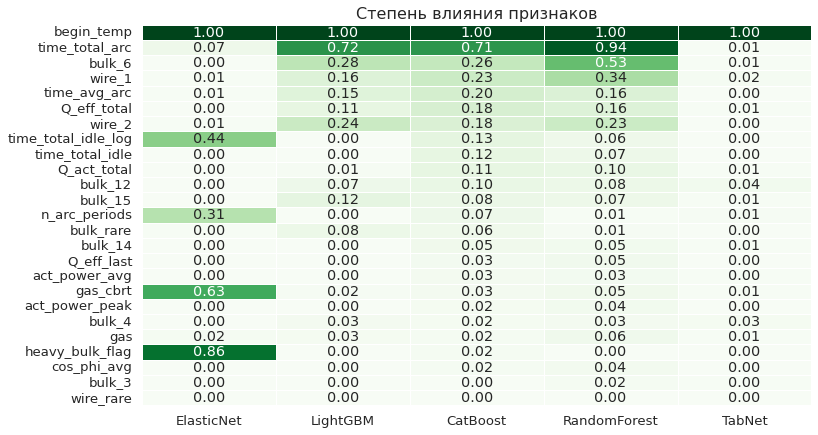

In [123]:
feature_importance = pd.DataFrame(
    data={
        'ElasticNet': np.insert(np.abs(model_elnet['model'].coef_), 0, 5),
        'LightGBM': model_lgbm.feature_importances_,
        'CatBoost':model_catboost.feature_importances_,
        'RandomForest':   model_forest.feature_importances_,
        'TabNet':   np.insert(model_tabnet.feature_importances_, 0, 5)
    }
)

feature_importance = pd.DataFrame(
    index=X_train.columns,
    data=MinMaxScaler().fit_transform(feature_importance),
    columns=list(feature_importance.columns)
).sort_values(by='CatBoost', ascending=False)

# Заполним 0 в Q_act_total с Q_eff_total у ElasticNet и TabNet,
# так как они коррелировали с коэф 1
feature_importance.loc['Q_act_total', 'ElasticNet'] = (
    feature_importance.loc['Q_eff_total', 'ElasticNet']
)
feature_importance.loc['Q_act_total', 'TabNet'] = (
    feature_importance.loc['Q_eff_total', 'TabNet']
)

plt.figure(figsize=(12, 7))
sns.heatmap(
    feature_importance,
    annot=True,
    fmt='.2f',
    linewidths=.5,
    cmap='Greens',
    cbar=False
)
plt.title('Степень влияния признаков', fontsize=16);

- Начальная температура `begin_temp` во всех моделях является самым важным признаком, что в целом ожидаемо
- На 2 месте у бустингов и леса идет `time_total_arc`, что так же логично, чем дольше нагрев, тем больше температура и наоборот. У `ElasticNet` - факт наличия тяжелых добавок, свыше 500 кг могут заметно охлаждать сталь
- На 3 месте у бустингов и леса - добавка `bulk_6` - видимо самая реактивная в плане химии, потому что она не самая частая. У `ElasticNet` - корень кубический из объема газа для продувки, так же из-за разницы температур может сильно влиять (если он инертный), может хороший перевод в линейный масштаб
- На 4 месте у бустингов и леса `wire_1`/ `wire_2` скорее всего как самые частые и реактивные. У `ElasticNet` - логарифм времени простоя
- `TabNet` из-за сложной структуры вероятно получились очень маленькие начальные веса, так как далеко прокидывать градиент. Возможно переобучилась, но мы бы тогда заметили это на валидации

**Вывод**

- Так образом лучшая модель - мета-модель с помощью стекинга обученных CatBoost и TabNet по метрике MAE на кросс-валидации - 4.49
- Так же необходимо отметить распределение предсказаний, которое лучше повторяет реальное рапспределение температур в тренировочной выборке
-  R2 метрика так же у этой модели самый большая - 0.73
-  95% CI остатков - [-11, 11], лучше чем у других, смещение - 0
-  Единственное, в чем она уступает другим моделям - в скорости обучения, но тут ближайший соперник `CatBoost` с метрикой MAE - 5.88

### Важность признаков лучшей модели
[[К началу раздела](#Main_Part_2)]

Важность признаков оценим по `CatBoost`, так как по главному признаку - начальной температуре она совпадает с `TabNet`, а по остальным практически нереально вытащить полезную информацию из `TabNet`, но предположим, что самые важные признаки похожи у обеих моделей

In [121]:
explainer = shap.TreeExplainer(model_catboost, X_train, feature_names=list(X_train.columns))
shap_values = explainer(X_train)

 97%|=================== | 1696/1740 [00:14<00:00]       

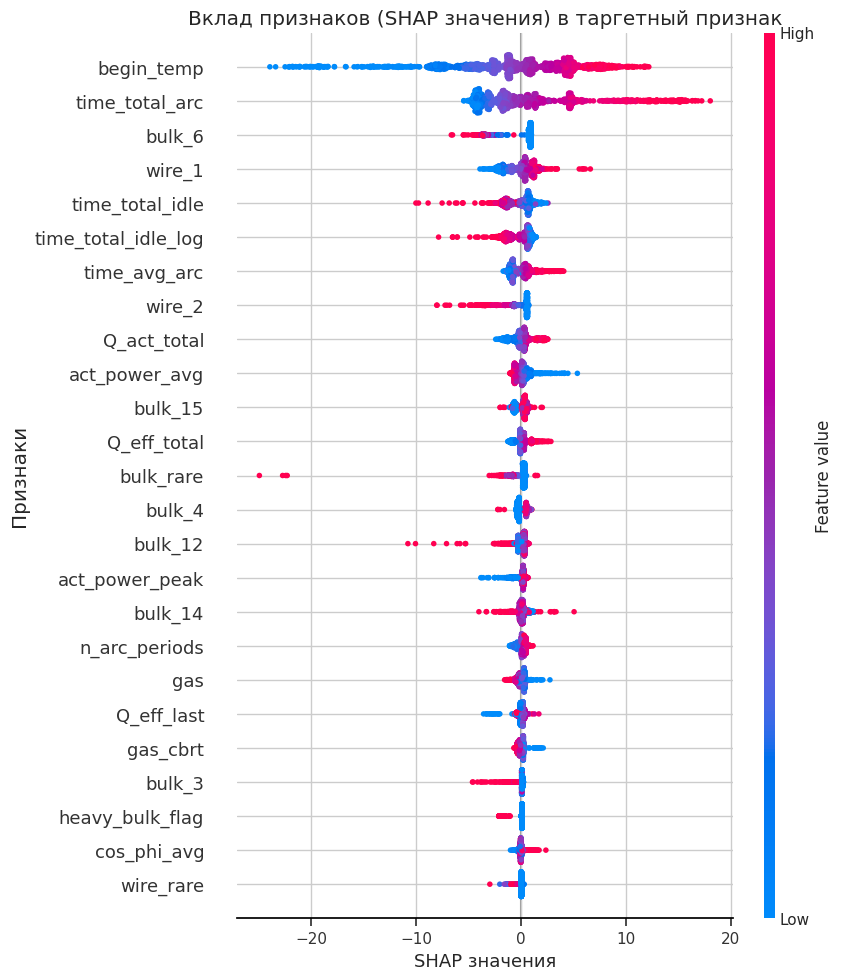

In [122]:
shap.plots.beeswarm(shap_values, max_display=25, show=False)
plt.title('Вклад признаков (SHAP значения) в таргетный признак')
plt.xlabel('SHAP значения')
plt.ylabel('Признаки');

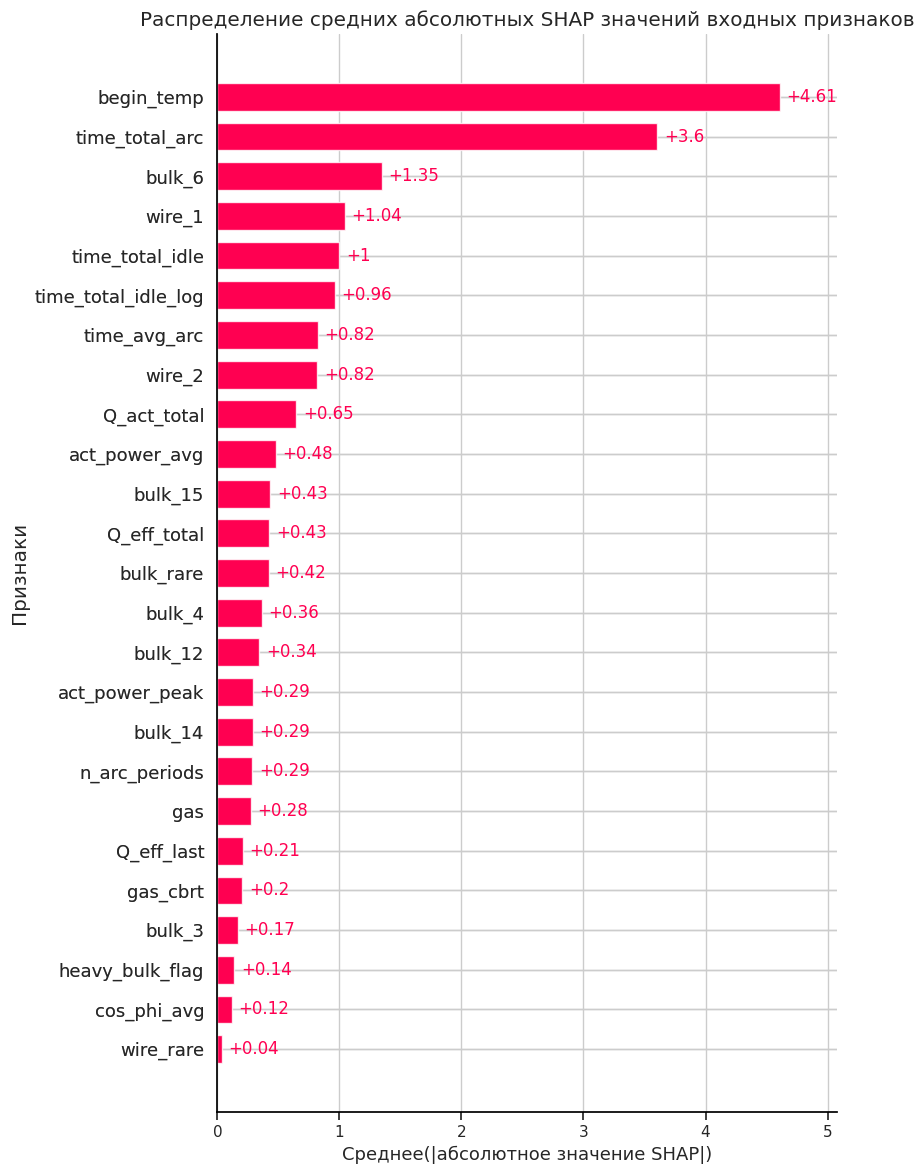

In [123]:
shap.plots.bar(shap_values, max_display=25, show=False)
plt.title('Распределение средних абсолютных SHAP значений входных признаков')
plt.xlabel('Среднее(|абсолютное значение SHAP|)')
plt.ylabel('Признаки');

- Видим, что по распределениям shap-значений признаков и их связи с значением самих признаков заметно выделяются первые 6-7 признаков, в остальных shap-значения около нуля, и оказывают влияние только выбросы в данных
- Поэтому рассмотрим следующие признаки отдельно, может там будут интереснные особенности
    - `begin_temp`
    - `time_total_arc`,
    - `bulk_6`
    - `bulk_4`
    - `wire_1`
    - `time_total_idle`
    - `Q_act_total`
    - `Q_eff_total`
    - `act_power_avg`
    - `heavy_bulk_flag`

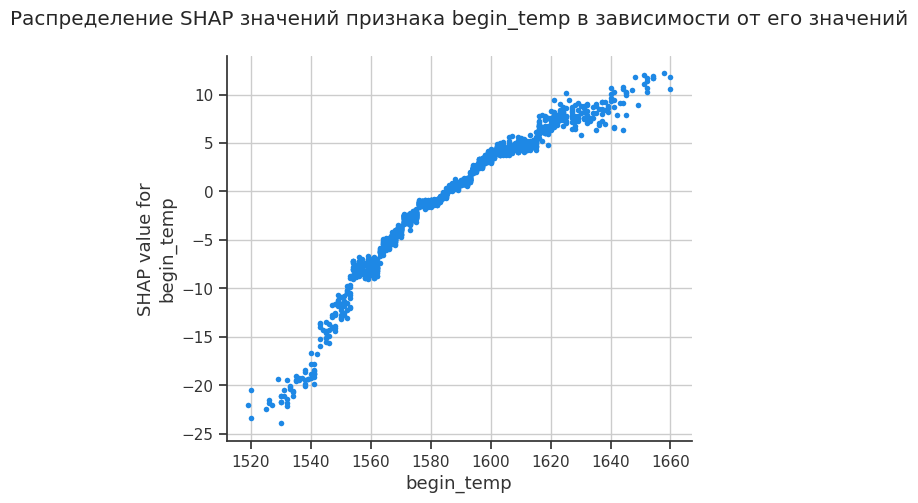

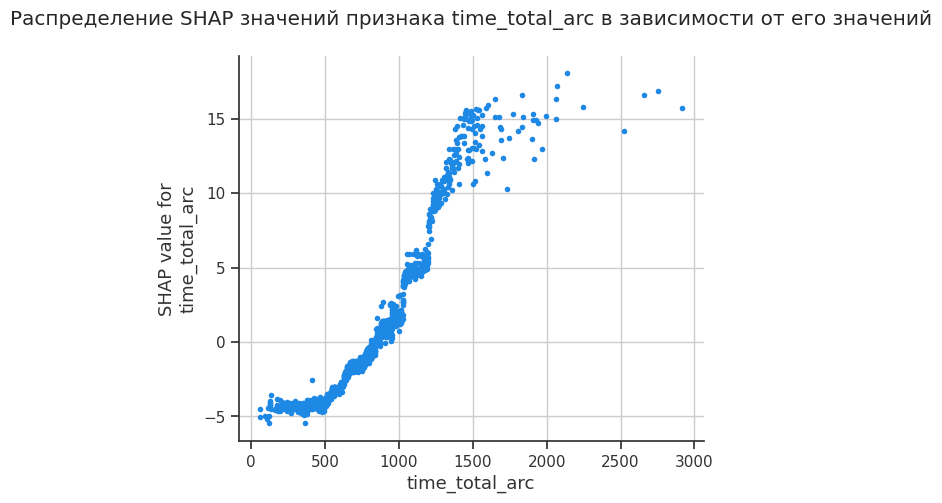

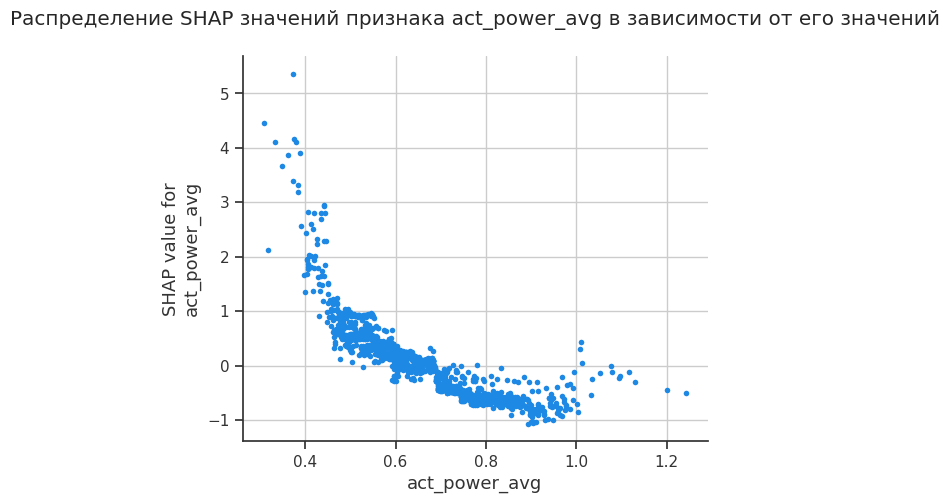

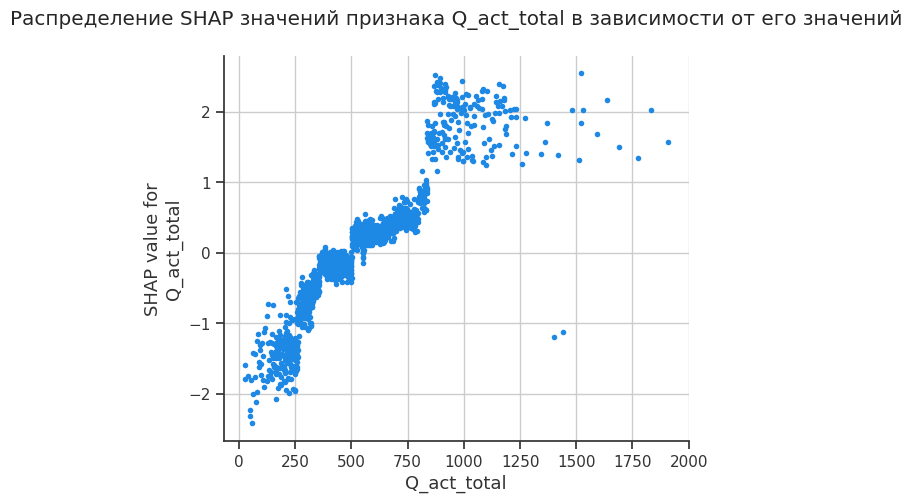

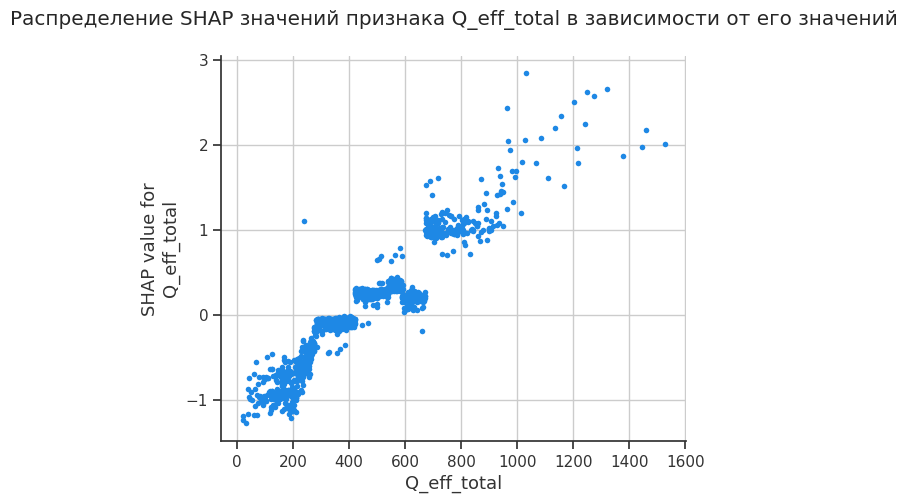

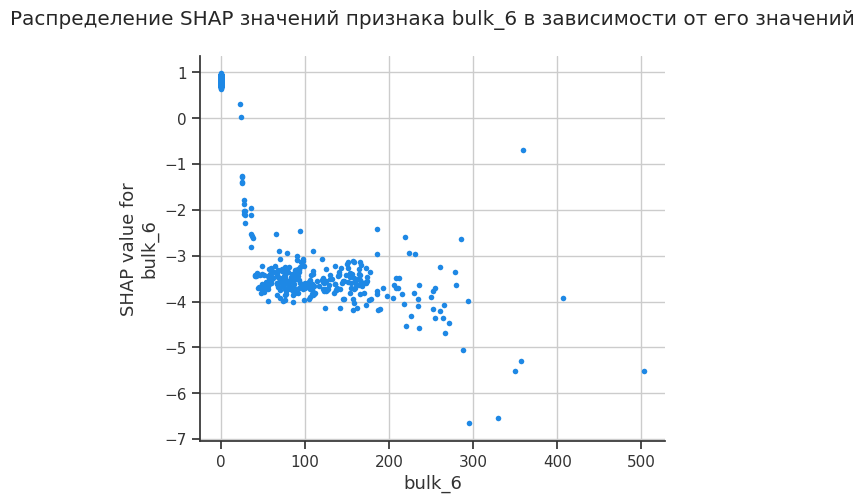

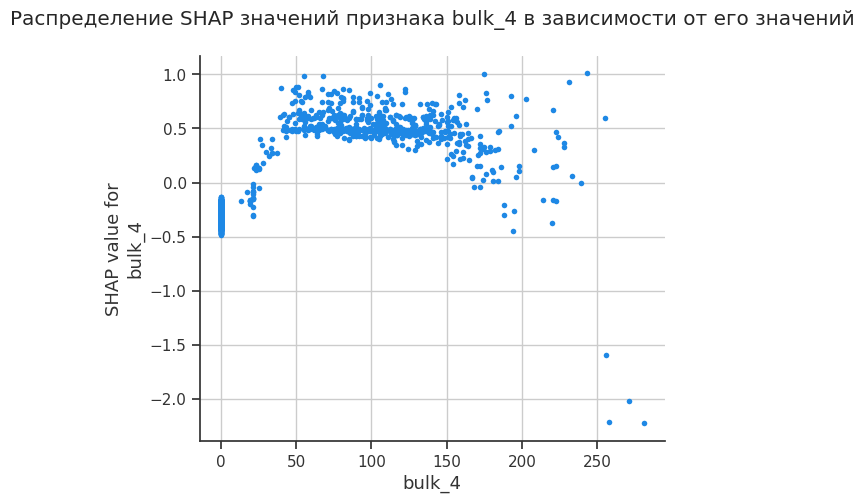

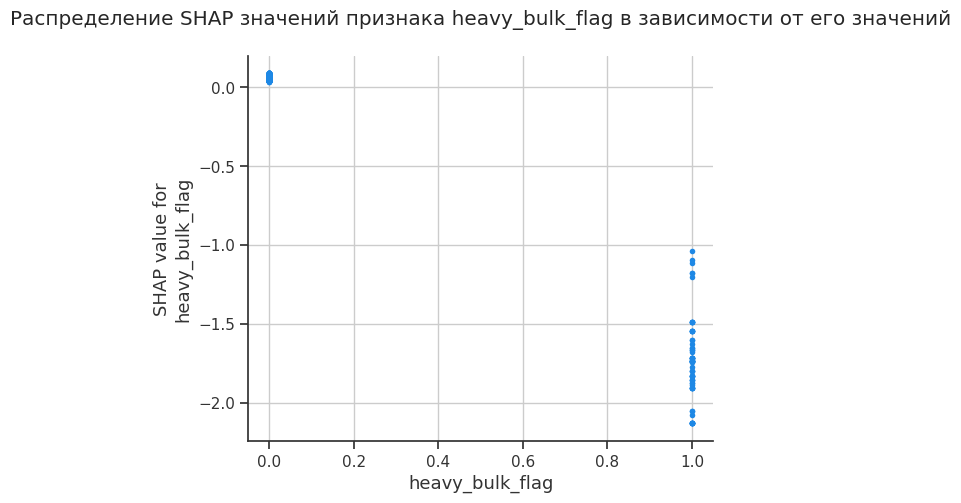

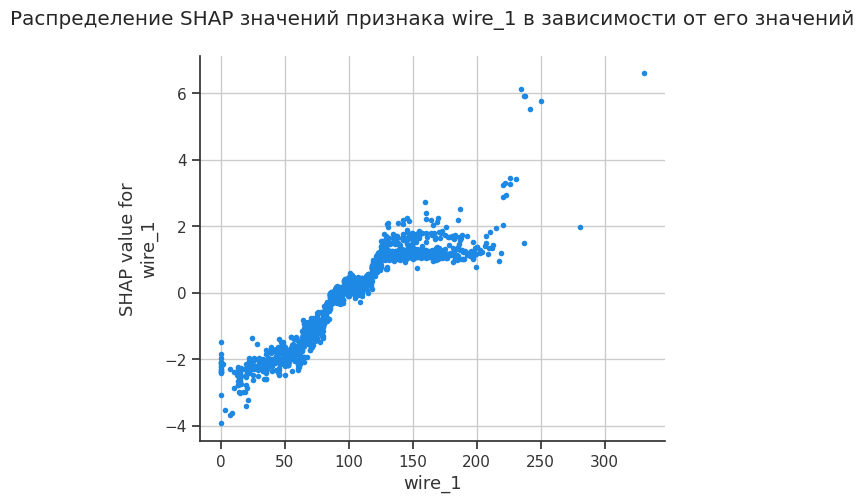

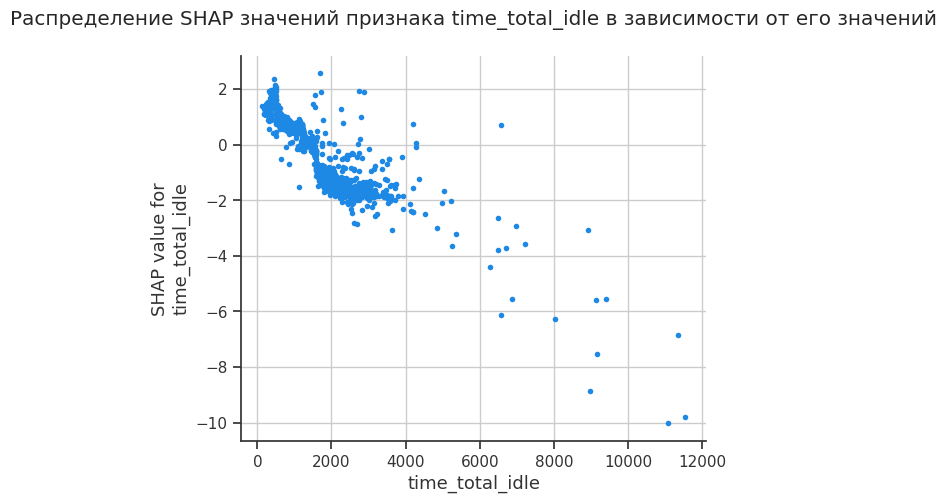

In [124]:
cols = [
    'begin_temp',
    'time_total_arc',
    'act_power_avg',
    'Q_act_total',
    'Q_eff_total',
    'bulk_6',
    'bulk_4',
    'heavy_bulk_flag',
    'wire_1',
    'time_total_idle'
]

for i in range(len(cols)):
    shap.dependence_plot(
        cols[i],
        shap_values.values,
        X_train,
        feature_names=list(X_train.columns),
        interaction_index=None,
        show=False
    )
    plt.title(f'Распределение SHAP значений признака {cols[i]} в зависимости от его значений\n')

Влияние различных признаков на целевую переменную - конечную температуру


- Влияние начальной температуры скорее линейного, в целом логично
- Полное время нагрева - если электроды работали больше 1000 с, то температура росла с ростом времени работы, если меньше - то падала, но уже не так значительно
- Средняя активная мощность - при значениях меньше 0.6 активная энергия дает прирост температуры, при значениях выше 0.6 не оказывают влияния
- Полная активная и эффективная энергии имеют похожие распределения, как и ожидалось, при этом эффективная энергия влияет немного сильнее, чем активная. При энергиях больше 600 наблюдается средне-положительное влияние на конечную температуру, меньше - слабо-негативное влияние
- Сыпучие добавки -  `bulk_6` почти всегда дает снижение температуры, тогда как `bulk_4` - легкое повышение, то есть в последнем случае вероятно большую роль играет эндотермический химический процесс, нежели разница температур
- `heavy_bulk_flag` - хорошо сработала на определенное число выбросов по массе добавок, тяжелые добавки из-за разницы температур могут заметно снизить общую температуру стали
- Проволочная добавка `wire_1` дает повышение конечной температуры при массах больше 100 кг, и снижение при меньших, то есть тоже, вероятно, химические процессы играют большую роль, нежели разница температур
- Простой стали без нагрева как и ожидалось приводит к падению температуры с ростом времени простоя

Посмотрим на отдельные зависимости конечной температуры от разных признаков

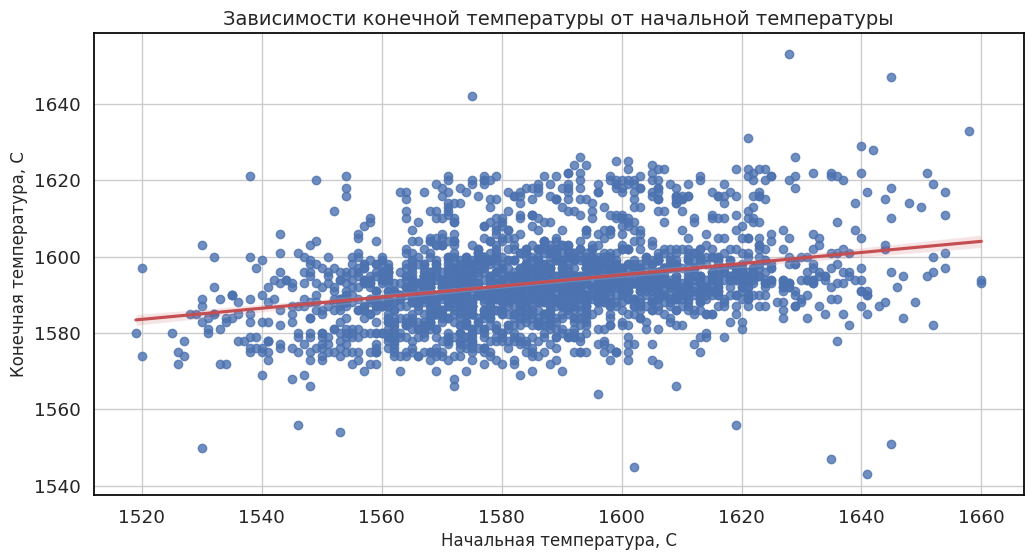

In [125]:
fig = plt.figure(figsize=(12, 6))
sns.regplot(x=df['begin_temp'], y=df['end_temp'], line_kws=dict(color='r'))
plt.title('Зависимости конечной температуры от начальной температуры', fontsize=14)
plt.xlabel('Начальная температура, С', fontsize=12)
plt.ylabel('Конечная температура, С', fontsize=12);

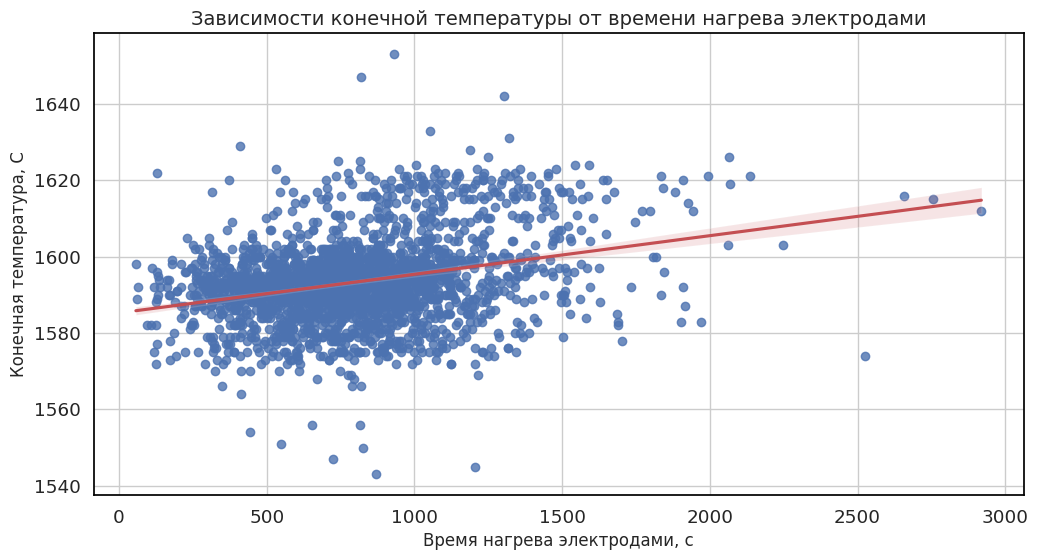

In [126]:
fig = plt.figure(figsize=(12, 6))
sns.regplot(x=df['time_total_arc'], y=df['end_temp'], line_kws=dict(color='r'))
plt.title('Зависимости конечной температуры от времени нагрева электродами', fontsize=14)
plt.xlabel('Время нагрева электродами, с', fontsize=12)
plt.ylabel('Конечная температура, С', fontsize=12);

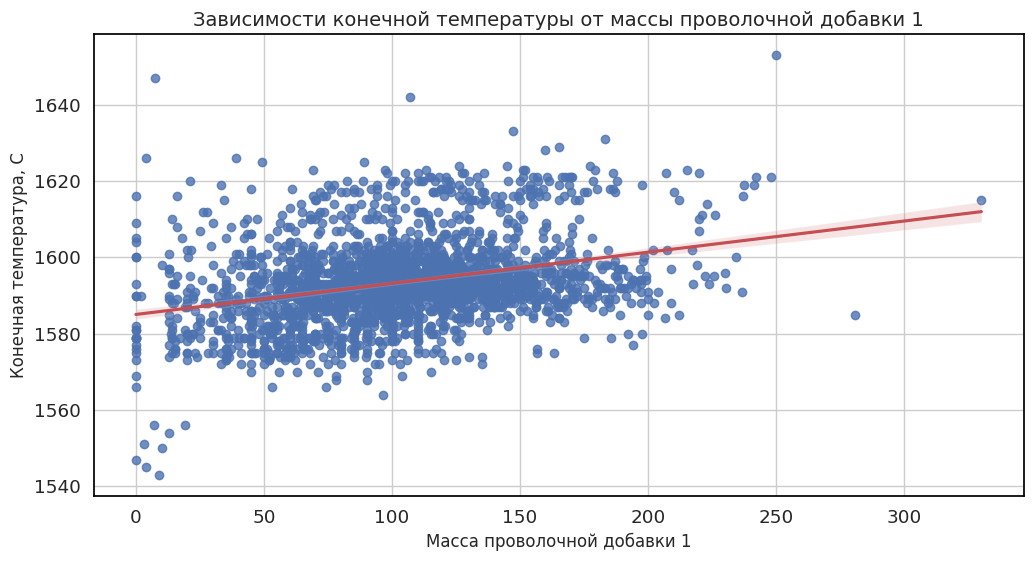

In [127]:
fig = plt.figure(figsize=(12, 6))
sns.regplot(x=df['wire_1'], y=df['end_temp'], line_kws=dict(color='r'))
plt.title('Зависимости конечной температуры от массы проволочной добавки 1', fontsize=14)
plt.xlabel('Масса проволочной добавки 1', fontsize=12)
plt.ylabel('Конечная температура, С', fontsize=12);

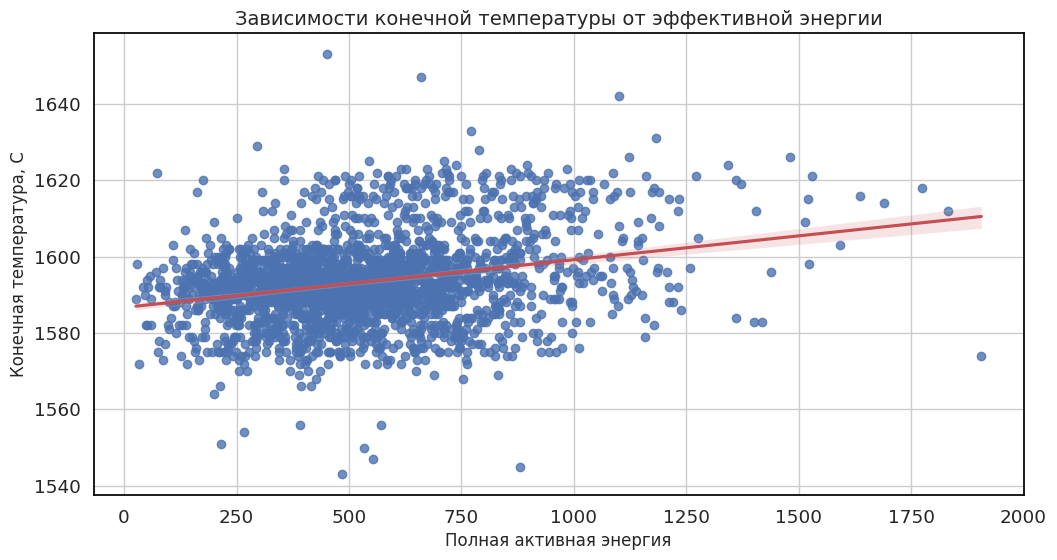

In [128]:
fig = plt.figure(figsize=(12, 6))
sns.regplot(x=df['Q_act_total'], y=df['end_temp'], line_kws=dict(color='r'))
plt.title('Зависимости конечной температуры от эффективной энергии', fontsize=14)
plt.xlabel('Полная активная энергия', fontsize=12)
plt.ylabel('Конечная температура, С', fontsize=12);

Везде у признаков слабая положительная линейная зависимость, что согласуется с нашими комментариями выше

### Тестирование лучшей модели
[[К началу раздела](#Main_Part_2)]

Проверим нашу модель на тестовой выборке и сравним ее еще раз с константной моделью

In [129]:
y_pred_catboost = model_catboost.predict(X_test)
y_pred_TabNet = model_tabnet.predict(
    scaler.transform(X_test.drop('Q_act_total', axis=1))
)[:,0]

X_test_combined = np.column_stack([y_pred_catboost, y_pred_TabNet])

Метрика MAE на тестовой выборке мета-модели - 5.864


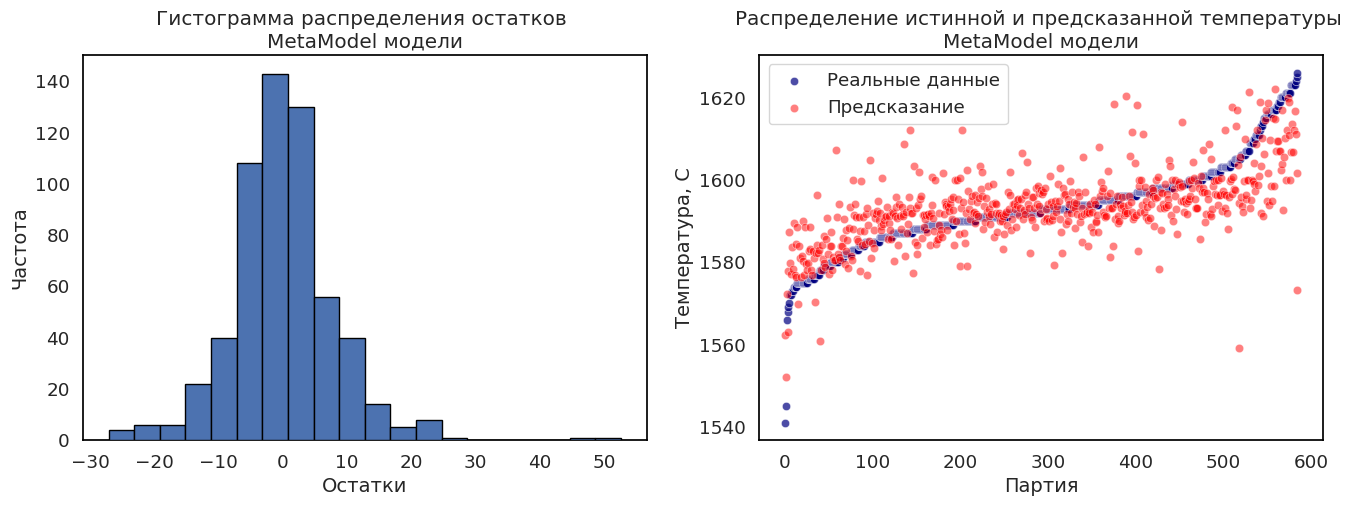

In [130]:
model_analysis(model_meta, y_test, X_test_combined)
print(
    'Метрика MAE на тестовой выборке мета-модели -',
    round(mean_absolute_error(y_test, model_meta.predict(X_test_combined)), 3))

Метрика MAE на тестовой выборке CatBoost модели - 7.858


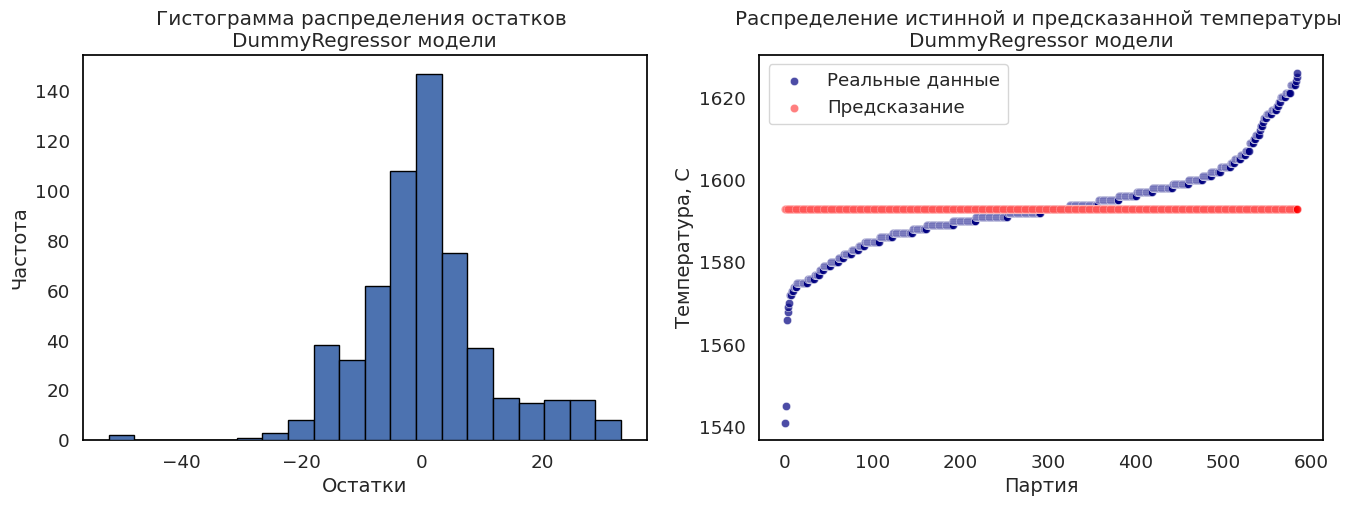

In [131]:
model_analysis(dummy, y_test, X_test)
print(
    'Метрика MAE на тестовой выборке CatBoost модели -',
    round(mean_absolute_error(y_test, dummy.predict(X_test)), 3))

- Целевая метрика MAE
    - **Мета-модель - 5.86**
    - Константная - 7.86
- Распределения предсказаний
    - Мета-модель - довольно неплохо повторяет распределение реальное распределение конечных температур в партиях, дисперсия из-за выбросов стала похуже, чем на обучении, но тем не менее в среднем показывает хорошую картину
    - Константная - тут все и так видно

Отлично, наша модель подходит под условия заказчика с серьезным запасов и показывает очень неплохие результаты на всем масштабе

<a name="Conclusion_3"></a>
### Вывод
[[К началу раздела](#Main_Part_2)]

Было обучено и сравнено 6 моделей предсказания конечной температуры стали, включая линейные, ансамблевые, бустинговые и нейронные модели. Гиперпараметры подбирались с помощью `hyperopt` с оценкой по метрике MAE и кросс-валидацией (K=3). Оценка проводилась на тестовой выборке (25 % от всей выборки)


- **Все модели преодолели целевой MAE < 6.8**
- **Лучший результат — ансамбль `CatBoost` + `TabNet`**:
  - MAE: **4.49** (валидация), **5.86** (тест)
  - R²: **0.73**
  - Смещение: **≈ 0**, доверительный интервал 95 %: **[–11.0, 11.0]**
  - Хорошо повторяет форму реального распределения температур


- MAE и R² на валидации

| Модель        | MAE   | R²    |
|---------------|-------|-------|
| **Metamodel**  | **4.49** | **0.73** |
| CatBoost      | 5.88  | 0.65  |
| LGBM          | 5.95  | 0.35  |
| TabNet        | 5.96  | 0.63  |
| ElasticNet    | 5.98  | 0.53  |
| RandomForest  | 6.29  | 0.49  |


- Скорость обучения и инференса
  - **Быстрые**: `CatBoost`, `LGBM`, `ElasticNet`
  - **Медленные**: `TabNet`, `RandomForest`
  - **Инференс**: те же тенденции


- Поведение моделей
  - `LGBM`, `RandomForest` — плохо справляются с выбросами, склонны к усреднению
  - `ElasticNet` — высокая дисперсия, но хорошо работает на краях
  - `TabNet` — лучше всех повторяет форму, но чуть шумнее в центре
  - `CatBoost` — стабильный и менее шумный
  - **Ансамбль `CatBoost` + `TabNet`** — объединил точность и устойчивость, минимизировал дисперсию


- Важность признаков лучшей модели
  - Начальная температура — главный фактор, влияние почти линейное и положительное
  - Время нагрева — при >1000 с температура стабильно растёт, при меньших значениях эффект слабее
  - Энергия (активная и эффективная) — при значениях >600 повышают температуру, при меньших — скорее снижают, эффективная влияет чуть сильнее
  - Средняя активная мощность — при низких значениях повышает температуру, далее эффект выравнивается
  - Сыпучие добавки -`bulk_6` снижает температуру, `bulk_4` — слегка повышает (возможно, из-за экзотермических реакций)
  - `heavy_bulk_flag` — фиксирует случаи значительного охлаждения при тяжёлых добавках
  - Проволока `wire_1` — при массе >100 кг повышает температуру, при меньших — снижает
  - Простой без нагрева — логично снижает температуру с ростом времени

## Общий вывод
[[Содержание](#Содержание)]

В данном проекте на основе данных об обработки стали, температуре, параметрах нагрева, добавок и других были исследованы основные факторы влияющие на конечную температура производственного процесса и была создана модель для предсказания конечной температуры выплавки стали. Были обучены шесть моделей разных классов - линейная регрессия, ансамбль, бустинги и нейронные сети (ElasticNet, RandomForest, LGBM, CatBoost, TabNet и стекинг моделей CatBoost и Tabnet). Было произведено сравнение моделей по различным показателям, основной из которых, по требованию заказчика, MAE. Лучшей моделью оказался стекинг моделей CatBoost и TabNet с метрикой MAE **4.49** на кросс-валидации (K=3) и **5.86** на тестовой выборке

**Исходные данные**
- База данных SQL с 7 таблицами
- В каждой от 3 до 18 тыс. уникальных записей
- Во всех таблицах поправили названия признаков и поставили правильные форматы при импорте
- Пропуски в дальнейшем заполнили 0, либо выбросили в результате ограничения выборки по требованиям заказчика

**Исследовательский анализ**

После успешной обработки и агрегации осталось 2325 уникальных партий

- **Подготовка и предобработка для агрегации ([Подробный](#Conclusion_1))**
    - Проведена очистка и агрегирование данных по партиям: исключены неполные и аномальные значения, сформированы целевые таблицы
    - Температуры, электроды, газ, сыпучие и проволочные добавки агрегированы с расчетом дополнительных признаков


- **Распределения и признаки ([Подробный](#Conclusion_2))**
    - Температура - стартовая распределена нормально, конечная — с вытянутыми хвостами, но в пределах нормы
    - Время обработки стали - логнормальное, выявлены редкие, но возможные длинные процессы, учтены через разбиение на нагрев и простой
    - Электроды - распределения признаков (мощность, энергия, количество запусков) преимущественно нормальные, последняя эффективная энергия — логнормальное
    - Газ - скошенное распределение, добавлена кубическая корневая трансформация
    - Добавки - агрегированы, редкие и тяжелые добавки вынесены в отдельные признаки; составные признаки созданы и лишние удалены


- **Итоговые признаки**
    - `begin_temp` - стартовая температура партии
    - `end_temp` - конечная температура партии - **целевой признак**
    - `time_avg_arc` - среднее время работы электродов за период
    - `act_power_avg` - средяя активная мощность
    - `act_power_peak` - пиковая активная мощность
    - `Q_act_total` - полная активная энергия электродов
    - `Q_eff_total` - полная эффективная энергия
    - `Q_eff_last` - эффективная энергия за последний период
    - `cos_phi_avg` - средний коэффициент мощности
    - `n_arc_periods` - количество периодов работы электродов
    - `gas` - объем подаваемого газа
    - `time_total_idle` - время простоя без нагрева
    - `time_total_idle_log` - логарифм времени простоя
    - `gas_cbrt` - кубический корень от объема газа
    - `bulk_3`, `bulk_4`, `bulk_6`, `bulk_12`, `bulk_14`, `bulk_15` - сыпучие добавки
    - `bulk_rare` - объединенные редкие сыпучие добавки
    - `wire_1`, `wire_2` - проволочные добавки
    - `wire_rare` - объединенные редкие проволочные добавки
- Был проведен корреляционный анализ

**Обучение моделей ([Подробный](#Conclusion_3))**

Было обучено и сравнено 6 моделей предсказания конечной температуры стали, включая линейные, ансамблевые, бустинговые и нейронные модели. Гиперпараметры подбирались с помощью `hyperopt` с оценкой по метрике MAE и кросс-валидацией (K=3). Оценка проводилась на тестовой выборке (25 % от всей выборки)


- **Все модели преодолели целевой MAE < 6.8**
- MAE и R² на валидации

| Модель        | MAE   | R²    |
|---------------|-------|-------|
| **Metamodel**  | **4.49** | **0.73** |
| CatBoost      | 5.88  | 0.65  |
| LGBM          | 5.95  | 0.35  |
| TabNet        | 5.96  | 0.63  |
| ElasticNet    | 5.98  | 0.53  |
| RandomForest  | 6.29  | 0.49  |


- Скорость обучения и инференса
  - **Быстрые**: `CatBoost`, `LGBM`, `ElasticNet`
  - **Медленные**: `TabNet`, `RandomForest`
  - **Инференс**: те же тенденции

- Был проведен анализ предсказания моделей в сравнении с реальным распределением целевой переменной обучающей выборки, исследованы остатки и рассмотрены важности признаков


**Лучшая модель**
- **Стекинг `CatBoost` + `TabNet`**:
  - MAE: **4.49** (валидация), **5.86** (тест)
  - R²: **0.73**
  - Смещение: **≈ 0**, доверительный интервал 95 %: **[–11.0, 11.0]**
  - Хорошо повторяет форму реального распределения температур
- Были исследованы важность признаков лучшей модели, выделены ключевые и отдельно рассмотрено влияние некоторых признаков на конечную температуру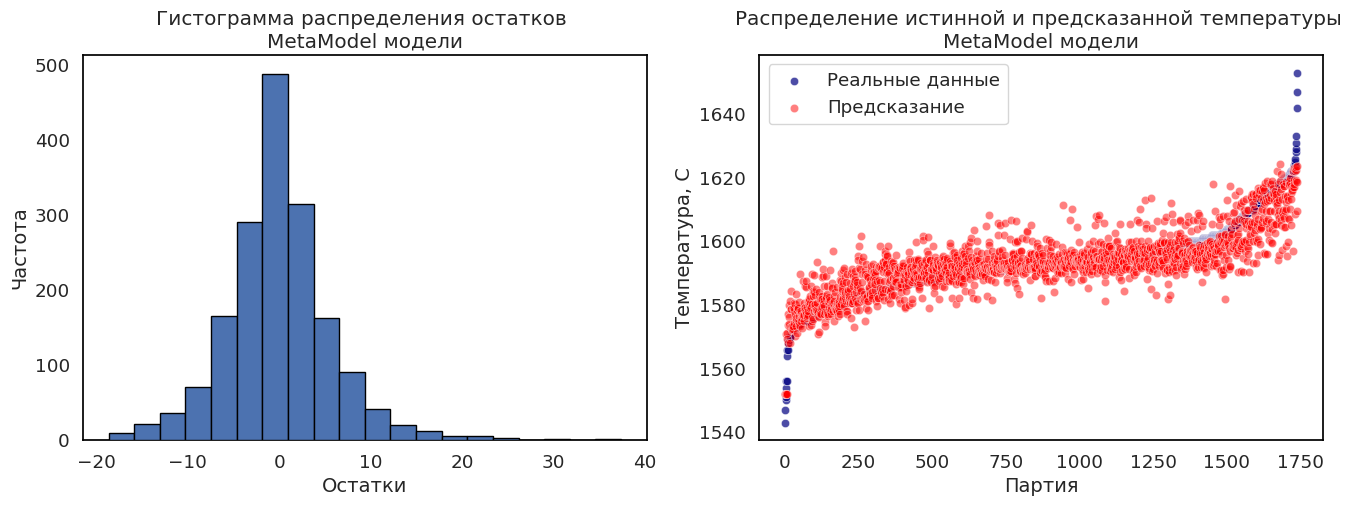

**Возможные улучшения модели**

- Разнообразить данные партиями с высокими и низкими конечными температурами для более точного предсказния выбросов
- Увеличить число оптимизируемых гиперпараметров нейронной сети для поиска лучшего минимума
- Сократить число входных признаков в соответствии с их влиянием
- Добавить дополнительные признаки полная масса сыпучих добавок и полная масса проволочных добавок вместо отдельных

**Рекомендации заказчику**

- Аккуратно подходить к предсказаниям, так как дисперсия модели не маленькая, особенно в области низких и высоких значений температуры относительно средней выходной температуры
- Касательно сокращения потребления энергии:
- Обратить внимание на полное время нагрева - если электроды работали больше 1000 с, то температура растет с ростом времени работы, если меньше - то падает, но не так значительно. Т.е. возможно сократить время работы электродов без ущерба технологическому процессу
- Средняя активная мощность - при значениях меньше 0.6 активная энергия дает прирост температуры, при значениях выше 0.6 не оказывают влияния, возможно сократить ток, подаваемый на электроды
- Рассмотреть подробнее влияние типа сыпучих и проволочных добавок, так как некоторые из них при определенной массе дают повышение температуры, а другие наоборот снижение
- Оценить возможность сокращение времени простоя за счет оптимизации очереди и других процессов, чтобы снизить его влияние на падение температуры